# Non-Separable Time and Graph Gaussian Processes with a Kronecker-Sum HSGP

In many forecasting problems the data come as a panel: time series across many entities. These entities could be products, stores or regions, for example. When modeling panel data, we could forget the relationships between the entities and fit one univariate model per entity. This gives a reasonable baseline, but it leaves out information, because the entities are usually related. They could be products within a category, stores in a chain, or regions that are close to each other on a map.

There are many ways to capture these relationships, for example via hierarchical models, see [Hierarchical Exponential Smoothing Model](https://juanitorduz.github.io/hierarchical_exponential_smoothing/) or [Hierarchical Pricing Elasticity Models](https://juanitorduz.github.io/elasticities/). In this notebook we take a different route and use a graph (a network) to encode them, where two entities are connected when they are "close" or "related" to each other. This is not a new idea. For instance, in the PyMC example notebook [NYC BYM](https://www.pymc.io/projects/examples/en/latest/spatial/nyc_bym.html) the authors use a graph to model spatial proximity with a conditional autoregressive prior. What is less common, and what this notebook is about, is letting the graph decide not only which entities move together, but also how long each spatial pattern lasts.

## The Example

Let's make this tangible. Imagine we have a weekly KPI (think of sales, demand, or conversions) for each of the $16$ German states. We have $156$ weeks of history and we want to forecast the next $13$ weeks for every state at once. We expect the data to have three characteristics:

- **Slow national trend.** All states follow the same national business cycle, so most of the movement is shared.

- **Correlated regional deviations.** Each state deviates from the national level, and these deviations are spatially structured. Bavaria and Baden-Württemberg tend to deviate together. Bremen and Saxony do not.

- **Rough patterns fade faster.** A pattern that is smooth over the map (the south above the national level, the north below) is likely to be a real regional effect and to persist for months. A rough pattern that flips sign between neighbors (one state up, the state next to it down) looks like noise and should be gone within weeks.

These are common characteristics of geo-panel data. The first two are standard. The third one is the reason for this notebook.

## Modeling Strategy

Gaussian processes are a natural prior for this kind of data. A Gaussian process puts a distribution over functions, and its kernel is the place where we say what *proximity* means.

For the time dimension, proximity is clear: the closer two weeks are, the more similar their values. For the spatial dimension we have to make a choice. Here we use the graph of the states, where two states are connected when they share a border. The strategy is then to combine these two notions of proximity into a single kernel over the product space of weeks and states.

### The Computational Challenge

Before describing how to do this, let's acknowledge the main obstacle: the computational cost. An exact Gaussian process over $T$ weeks and $R$ regions needs a covariance matrix with $(TR)^2$ entries and a Cholesky factorization of it, which costs $O((TR)^{3})$ operations. For $T = 156$ and $R = 16$ that is a matrix with about $6.2$ million entries, and the sampler pays that price at every evaluation. In practice this means very long sampling times with MCMC methods.

Fortunately, there are good approximations. The Hilbert space Gaussian process (HSGP) approximation replaces the process by a linear model on a fixed set of basis functions. The basis does not depend on the kernel hyperparameters, so we build it once and what remains at each evaluation is a matrix multiplication. If you are new to HSGPs, please see the extensive introduction in [A Conceptual and Practical Introduction to Hilbert Space GPs Approximation Methods](https://juanitorduz.github.io/hsgp_intro/).

In that post we studied the one-dimensional case in detail. On an interval the basis is a set of sine waves, and the hyperparameters only decide how much weight each wave carries. What happens when the index set is not an interval, but an interval *times* a set of regions connected by a map? The same machinery goes through. There is, however, no *unique* way to make this construction, and that choice is what we study here.

### The Latent Process

At its core, we want a latent process $f(t, r)$ over weeks $t$ and states $r$ that encodes the three characteristics above. To that end, we compare three *natural* kernels for $f$ that share the same hyperparameters, and we check whether the extra structure improves the $13$-week forecast.

- **Independent** (`independent`). Each state gets its own Gaussian process in time and the map is ignored. The model learns Bavaria's pattern from Bavaria's history alone. If Bavaria turns down in the last weeks, the forecast for Baden-Württemberg does not move, even though the two states share a border. This is the baseline, and whatever it achieves comes from the time dimension alone.

- **Kronecker Product** (`separable`). The map now enters through a product of a kernel in time and a kernel on the graph. Neighbors share information, so a downturn in Bavaria pulls the forecast for Baden-Württemberg down too. The limitation is that a single number, the temporal lengthscale, has to describe the memory of every pattern. A country-wide movement and an up-down pattern between neighbors are then assumed to persist for the same number of weeks, which is not what we expect from the data.

- **Kronecker Sum** (`kron_sum`). Neighbors share information *and* the map decides how long each pattern lasts. A movement common to the whole country has the longest memory, a smooth north-south gap a shorter one, and a pattern that flips sign between neighbors the shortest. As the horizon grows, the short-memory patterns die out first, so each state's forecast reverts toward the national forecast, and the rough part of its deviation reverts first.

The first kernel is *straightforward* to implement with the HSGP approximation on an interval (see the blog post above). The second one is a product kernel, which has been studied in the PyMC example [HSGP Advanced Usage, example 2](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/HSGP-Advanced.html#example-2-an-hsgp-that-exploits-kronecker-structure). The third one is the construction this notebook is about. As we will see below, allowing a non-separable kernel lets us model time and regional effects in a way that fits the example at hand.

## Outline

The objective of this notebook is to develop forecasting models for the panel example above, using the three kernels described and the HSGP approximation to keep the computational cost manageable. Here are the steps we follow:

1. **The Problem and the Estimand.** We state what we forecast and how we score a forecast.
2. **From the Interval to the Product Space.** We recall the main concepts of the HSGP approximation on an interval, we introduce the graph Laplacian, and we combine them into the three kernels above.
3. **The Graph.** We build the graph of the $16$ German states from their polygons and look at its modes.
4. **Building Blocks.** We write the construction as a handful of small functions.
5. **What the Prior Says.** We fix the hyperparameters and check what each kernel says before we see any data.
6. **Data Generating Process.** We specify the data generating process and simulate a weekly panel with a process that is deliberately *not* the model.
7. **The Forecasting Models.** We split the panel into a training window and a test window and write the three forecasting models.
8. **Model Fit and Diagnostics.** We fit the three models with NUTS in [NumPyro](https://num.pyro.ai/) and check the diagnostics.
9. **Forecasts and Forecast Evaluation.** We forecast $13$ weeks ahead with [`numpyro-forecast`](https://github.com/juanitorduz/numpyro_forecast) and score them.
10. **Rolling-Origin Backtest.** We repeat the exercise on a rolling-origin backtest, to check that the ranking is not an artifact of a single split.

**Remark (spatial Gaussian processes).** We do not have to use a graph. When the entities have coordinates, we can put a Gaussian process directly on the map, with a kernel that decays with the distance between two points. For an example with the radon data, where the kernel uses the chordal distance on the sphere, see the PyMC Labs post [Gaussian Process Geospatial Modeling in PyMC: Beyond Hierarchical Models](https://www.pymc-labs.com/blog-posts/spatial-gaussian-process-01). We use a graph because it only needs to know which regions are neighbors, and because it also covers entities that have no coordinates at all, like products in a category tree. The construction below does not depend on this choice: all it needs from the spatial side is a way to tell a smooth spatial pattern from a rough one, and a Gaussian process on coordinates gives us that too.


## Prepare Notebook

In [1]:
import time
from typing import Literal

import arviz as az
import geopandas as gpd
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import numpyro
import numpyro.distributions as dist
import polars as pl
import preliz as pz
from jax import random
from jax.scipy.special import betainc
from jaxtyping import Array, Float
from numpyro.contrib.hsgp.approximation import hsgp_matern, linear_approximation
from numpyro.contrib.hsgp.laplacian import eigenfunctions, sqrt_eigenvalues
from numpyro.contrib.hsgp.spectral_densities import (
    diag_spectral_density_matern,
    spectral_density_matern,
)
from numpyro.handlers import do, substitute
from numpyro.infer import MCMC, NUTS, Predictive, init_to_median
from numpyro_forecast import (
    Horizon,
    backtest,
    eval_coverage,
    eval_crps,
    eval_rmse,
    forecast,
    predict,
)
from numpyro_forecast.features import fourier_features

numpyro.set_host_device_count(n=4)

seed: int = 42
rng_key = random.PRNGKey(seed=seed)

HDI_PROB = 0.94

az.style.use("arviz-darkgrid")
az.rcParams["stats.ci_kind"] = "hdi"
az.rcParams["stats.ci_prob"] = HDI_PROB
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%config InlineBackend.figure_format = "retina"

## The Problem and the Estimand

We observe a panel $y_{t, r}$ for weeks $t = 1, \ldots, T$ and regions $r = 1, \ldots, R$. We want to forecast $H$ weeks ahead for every region.

The estimand is the predictive distribution $\text{P}(y_{T + h, r} \mid y_{1:T, 1:R})$ for $h = 1, \ldots, H$ and every region $r$. As mentioned in the introduction, we will compare three models (details below). All models share the same observation equation. Let $f(t, r)$ be a latent Gaussian process on the product space, $a_r$ a regional intercept, $s(t)$ a yearly seasonal term, and $\sigma$ the observation scale. We then consider a panel-level model of the form:

$$
y_{t, r} = a_r + f(t, r) + s(t) + \varepsilon_{t, r}, \qquad \varepsilon_{t, r} \sim \text{StudentT}(\nu_{\varepsilon}, 0, \sigma).
$$

The three models differ only in the kernel of $f$.

### Network Structure

The regions are modeled as a network (an undirected graph), with adjacency matrix $A$. Two regions are adjacent if they share a border. The graph is our notion of spatial distance, in the same way as the [NYC BYM example](https://www.pymc.io/projects/examples/en/latest/spatial/nyc_bym.html) uses the adjacency of census tracts.

### Scoring a Forecast

How do we decide that one predictive distribution is better than another? We use three scores. Each one looks at a different aspect of the same forecast:

- **CRPS.** The continuous ranked probability score compares the *whole* forecast distribution with the observed value. It rewards a forecast that is centered on the truth *and* no wider than it needs to be, and it reduces to the absolute error when the forecast is a single point. Lower is better. See the blog post Intuition behind CRPS: [Intuition behind CRPS](https://juanitorduz.github.io/crps/), for a longer discussion.

- **RMSE.** The root mean squared error of the mean forecast ignores the spread and only asks whether the center sits in the right place. We report it because it is familiar.

- **Coverage.** The empirical coverage of the central $90\%$ interval is the fraction of test observations that fall between the $5\%$ and the $95\%$ quantile of the forecast draws. A calibrated model gives $0.9$. A value below $0.9$ means the model is overconfident, and a value above $0.9$ means its intervals are wider than they need to be.

We average each score over the $13$ forecast weeks and the $16$ regions.

## From the Interval to the Product Space

This section derives the construction step by step. We start with the HSGP approximation on an interval, then the graph Laplacian, and then we combine the two. For more details, see [A Conceptual and Practical Introduction to Hilbert Space GPs Approximation Methods](https://juanitorduz.github.io/hsgp_intro/). Here we do a fast walkthrough to establish notation.

### Stationary Kernels and Spectral Densities

A kernel $k(t, t')$ is stationary if it only depends on the difference $\tau = t - t'$. By Bochner's theorem, a stationary kernel is the Fourier transform of a positive function $S(\omega)$, its spectral density:

$$
k(\tau) = \frac{1}{2\pi} \int_{-\infty}^{\infty} S(\omega)\, e^{i \omega \tau}\, d\omega .
$$

We use the angular-frequency convention, so the inverse transform carries the $1 / (2\pi)$. With it, $k(0) = \sigma_f^2$ fixes the normalization of $S$ below.

Among many possible kernels (see the PyMC example [Mean and Covariance Functions](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MeansAndCovs.html)), we consider the Matérn family for the following reasons:

- It has a closed-form spectral density, which is exactly what the construction below needs.

- The smoothness $\nu$ controls how many times the sample paths are differentiable, so we can ask for realistic roughness instead of the infinitely smooth paths of the squared exponential kernel.

- The case $\nu = 1/2$ is the Ornstein-Uhlenbeck process, which is the per-mode process of the data generating process we simulate later.

- It is the family used by both HSGP papers and by the graph Matérn of [Borovitskiy et al. (2021)](https://proceedings.mlr.press/v130/borovitskiy21a.html), so the interval side and the graph side of the construction match.

For the Matérn family with smoothness $\nu$, lengthscale $\ell$, and variance $\sigma_f^2$, the spectral density in one dimension is ([Rasmussen and Williams, 2006, chapter 4](https://gaussianprocess.org/gpml/chapters/RW4.pdf), equation 4.15)

$$
S(\omega) = \sigma_f^2\, \frac{2 \sqrt{\pi}\, \Gamma(\nu + 1/2)\, (2\nu)^{\nu}}{\Gamma(\nu)\, \ell^{2\nu}} \left(\frac{2\nu}{\ell^2} + \omega^2\right)^{-(\nu + 1/2)} .
$$

We write $\kappa^2 = 2\nu / \ell^2$. The shape of the density is then $(\kappa^2 + \omega^2)^{-(\nu + 1/2)}$ up to a constant.

**Remark:** For $\omega \ll \kappa$ the sum $\kappa^2 + \omega^2$ is essentially $\kappa^2$, so the density is flat and all slow wiggles are equally cheap. For $\omega \gg \kappa$ the term $\omega^2$ takes over and the density decays like $\omega^{-(2\nu + 1)}$, so fast wiggles are penalized polynomially. The frequency $\kappa$ is the corner between the two regimes. A longer lengthscale means a smaller $\kappa$, so the corner moves left and less power is left at high frequencies.



Let's look at the three faces of this picture for the Matérn-$3/2$ kernel: the kernel itself, its spectral density, and how much of the total power sits below a given frequency.

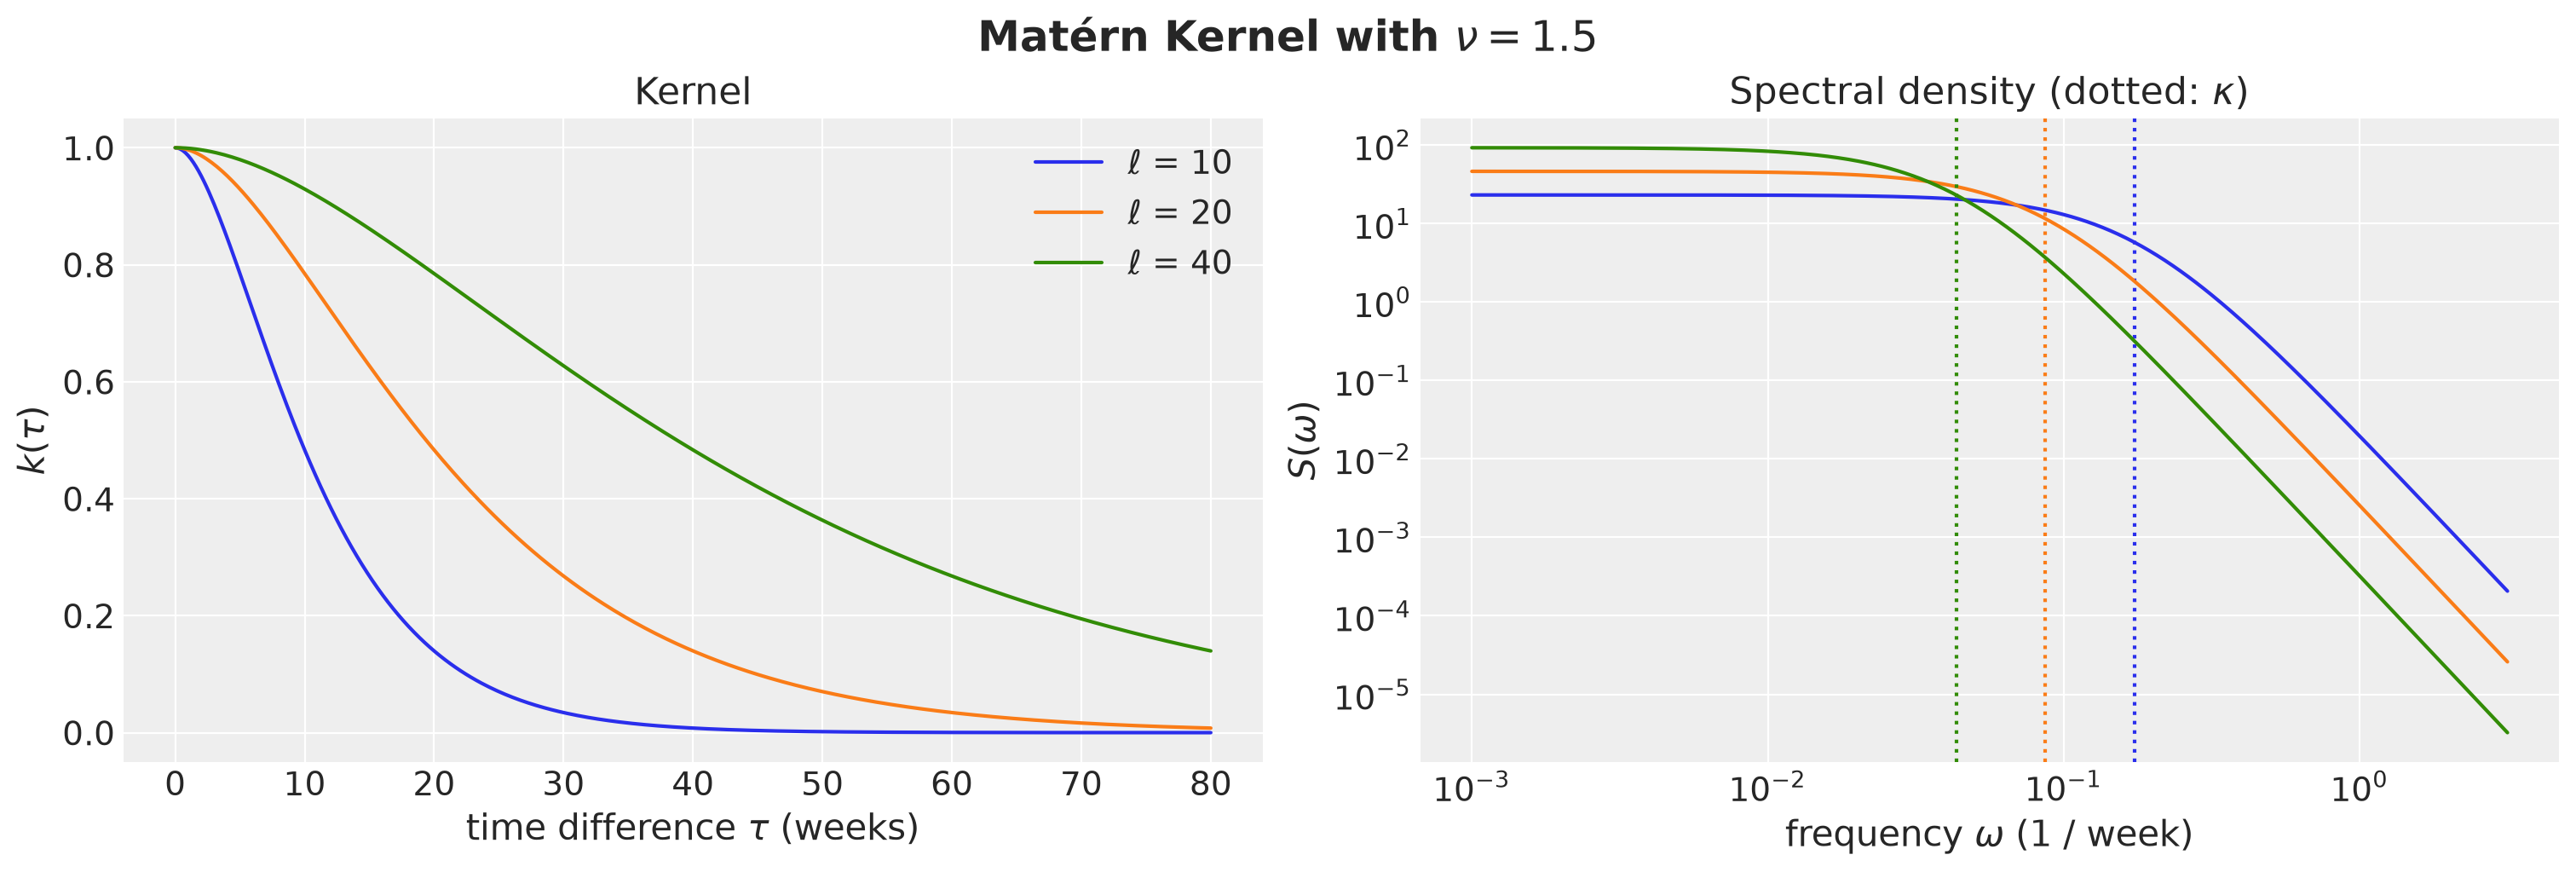

In [2]:
NU = 3 / 2

tau_grid = jnp.linspace(0.0, 80.0, 400)
omega_grid = jnp.logspace(-3, 0.5, 400)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 5), layout="constrained")

for i, length in enumerate([10.0, 20.0, 40.0]):
    d = jnp.sqrt(3.0) * tau_grid / length
    k_tau = (1.0 + d) * jnp.exp(-d)
    s_omega = spectral_density_matern(
        dim=1, nu=NU, w=omega_grid[:, None], alpha=1.0, length=length
    )
    kappa = jnp.sqrt(2.0 * NU) / length
    axes[0].plot(
        tau_grid,
        k_tau,
        color=f"C{i}",
        label=f"$\\ell$ = {length:.0f}",
    )
    axes[1].plot(
        omega_grid,
        s_omega,
        color=f"C{i}",
        label=f"$\\ell$ = {length:.0f}",
    )
    axes[1].axvline(x=float(kappa), color=f"C{i}", linestyle=":")

axes[0].set(
    xlabel="time difference $\\tau$ (weeks)", ylabel="$k(\\tau)$", title="Kernel"
)
axes[1].set(
    xlabel="frequency $\\omega$ (1 / week)",
    ylabel="$S(\\omega)$",
    xscale="log",
    yscale="log",
    title="Spectral density (dotted: $\\kappa$)",
)

axes[0].legend()

fig.suptitle(f"Matérn Kernel with $\\nu = {NU}$", fontsize=18, fontweight="bold");

A longer lengthscale is a wider kernel and a narrower density.

Next, we look into its *power*, that is, the area under the spectral density, which is the variance of the process. This is the Bochner formula above evaluated at $\tau = 0$, which gives $k(0) = \sigma_f^2$ on the left and the integral of $S$ on the right. Every frequency therefore owns a slice of the variance, and $S(\omega)$ says how big that slice is.

This gives us a second way to read the kernel. Let's plot the fraction of the variance that sits below a given frequency, as a function of $\omega / \kappa$. In these units the curve depends on the smoothness $\nu$ alone, because the lengthscale only moves the corner $\kappa$ along the frequency axis and does not change the shape of the density.

**Fact:** The area under the Matérn density up to a given frequency is the `betainc` function. To see that this is all it does, the cell below also accumulates the density over the frequency grid by hand and checks that the two agree.

In [10]:
# omega / kappa grid: the power fraction depends on nu only, not on the lengthscale
ratio_grid = jnp.logspace(-2, 2, 400)

for nu in [0.5, 1.5, 2.5]:
    # Closed form of the fraction of the variance below omega: the integral of the
    # Matern density from 0 to omega is a regularized incomplete beta function,
    # evaluated at 1 / (1 + (omega / kappa)^2).
    power_fraction = 1.0 - betainc(nu, 0.5, 1.0 / (1.0 + ratio_grid**2))
    # The same quantity by hand: the density S(omega) / S(0) times the width of each
    # frequency bin, accumulated and divided by the total. The two agree to one
    # percent. The gap is the coarseness of the log grid, plus the power beyond its
    # right edge, which the closed form counts and the sum does not.
    shape = (1.0 + ratio_grid**2) ** (-(nu + 0.5))
    cumulative = jnp.cumsum(shape * jnp.diff(ratio_grid, prepend=0.0))
    np.testing.assert_allclose(power_fraction, cumulative / cumulative[-1], atol=0.01)

We now plot the fraction of the power below a given frequency for the Matérn family.

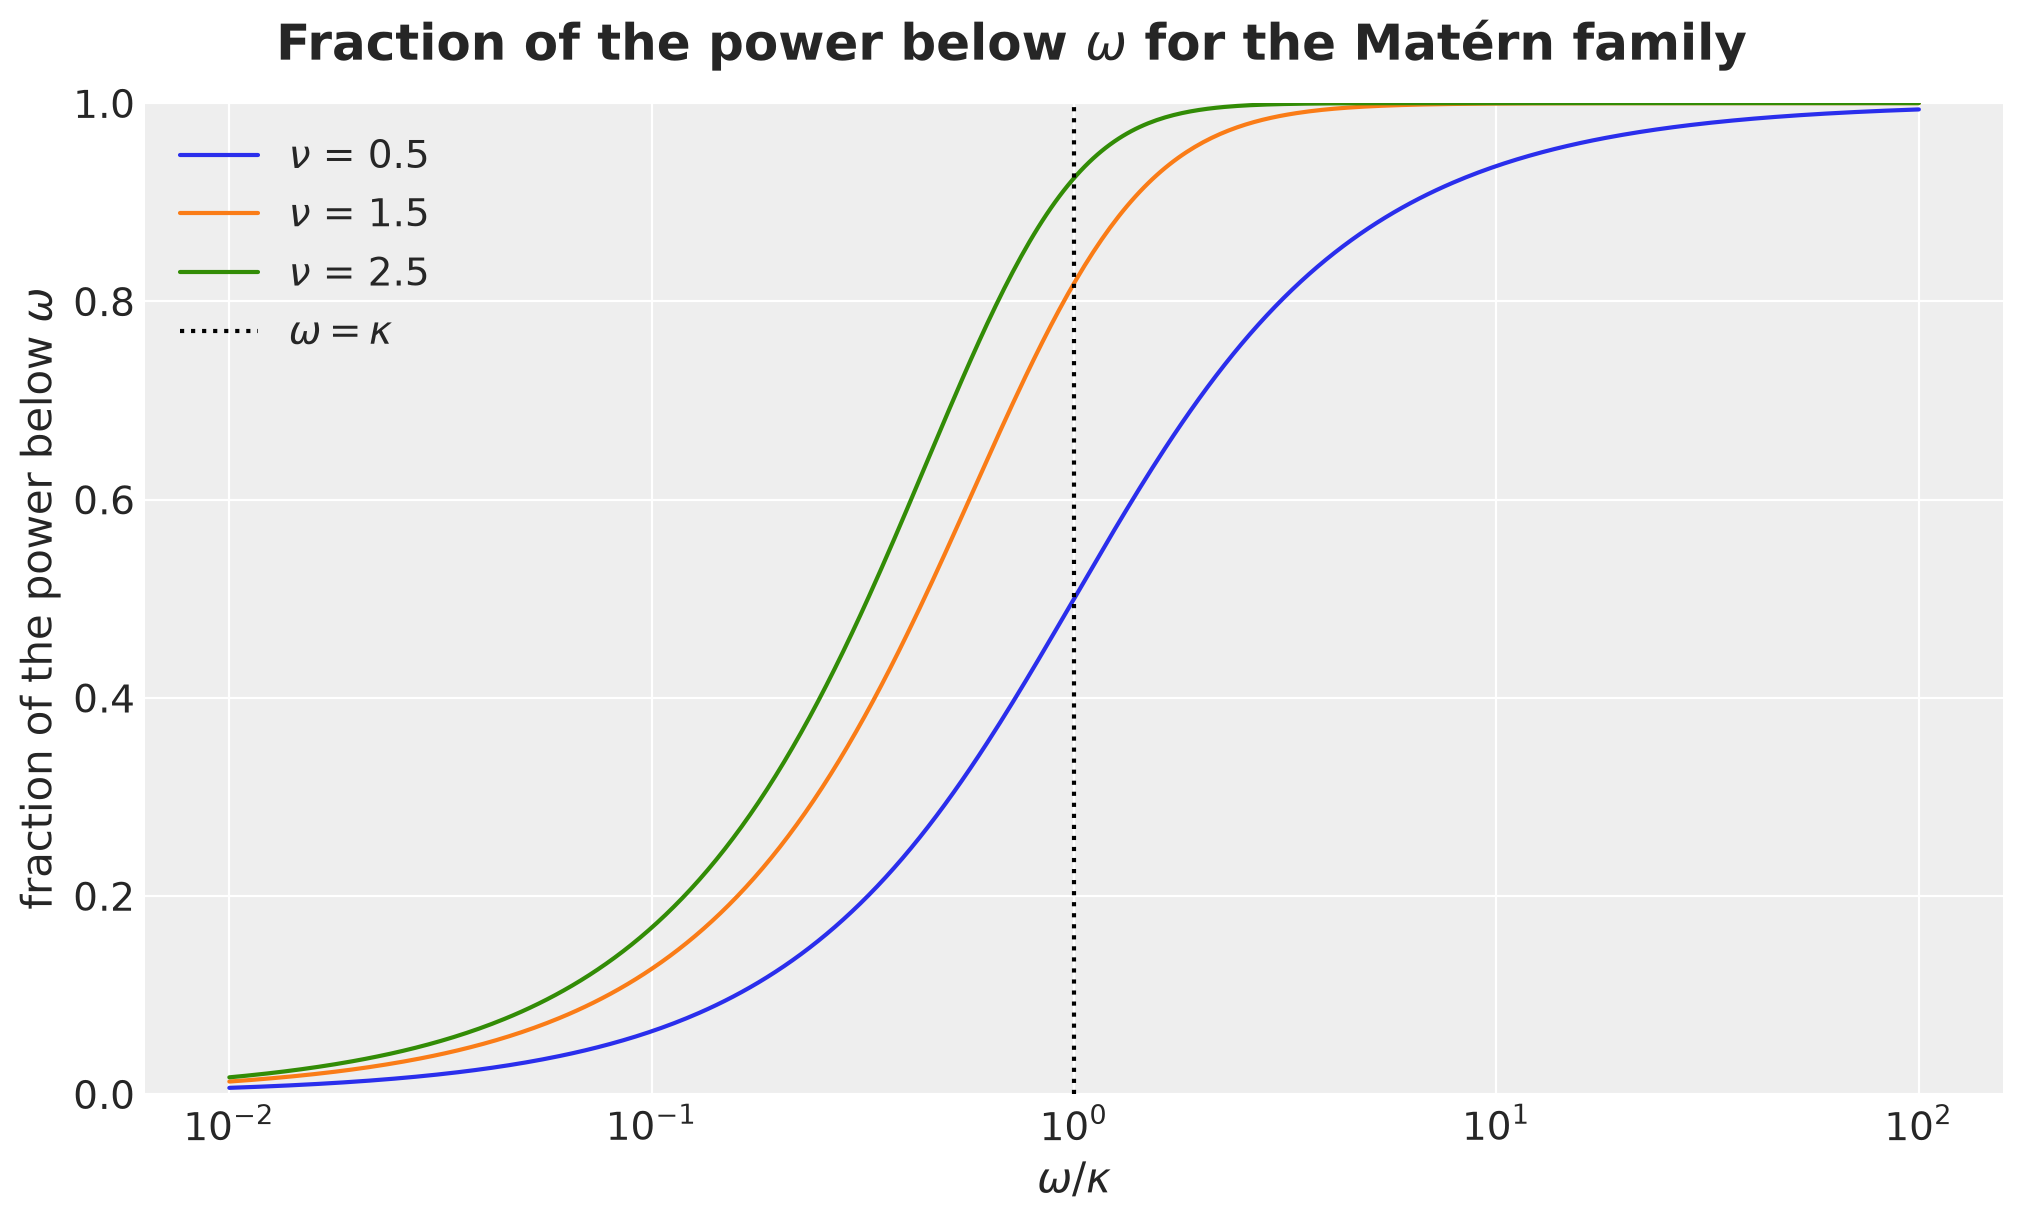

In [ ]:
fig, ax = plt.subplots()

for i, nu in enumerate([0.5, 1.5, 2.5]):
    power_fraction = 1.0 - betainc(nu, 0.5, 1.0 / (1.0 + ratio_grid**2))
    ax.plot(ratio_grid, power_fraction, color=f"C{i}", label=f"$\\nu$ = {nu}")

ax.axvline(x=1.0, color="black", linestyle=":", label="$\\omega = \\kappa$")
ax.set(
    xlabel="$\\omega / \\kappa$",
    ylabel="fraction of the power below $\\omega$",
    xscale="log",
    ylim=(0, 1),
)

ax.legend()
fig.suptitle(
    "Fraction of the power below $\\omega$ for the Matérn family",
    fontsize=18,
    fontweight="bold",
);

For the Matérn-$3/2$ kernel about $82\%$ of the power sits below $\kappa$, against $50\%$ for $\nu = 1/2$ and $92\%$ for $\nu = 5/2$. A smoother process concentrates more of its power below the corner.

### HSGP on an Interval

The HSGP approximation ([Solin and Särkkä, 2020](https://link.springer.com/article/10.1007/s11222-019-09886-w), [Riutort-Mayol et al., 2023](https://link.springer.com/article/10.1007/s11222-022-10167-2)) uses two facts. A stationary kernel is a function of the Laplacian, $K = S(\sqrt{-\Delta})$, and on the box $[-L, L]$ with Dirichlet boundary conditions the Laplacian has a closed-form eigenbasis.

What does a function of an operator mean? It acts on the eigenvalues (this is the functional calculus of the Dirichlet Laplacian, which is a self-adjoint operator on the Hilbert space $L^2([-L, L])$, so it is diagonalized by its eigenbasis and any function of it acts on the eigenvalues alone). Since $-\Delta \sin(\omega t) = \omega^2 \sin(\omega t)$, the operator $S(\sqrt{-\Delta})$ multiplies the sine of frequency $\omega$ by $S(\omega)$ (because $\omega^2$ is and eingenvalue with eigenfunction $\sin(\omega t)$).

Why is that enough to get a Gaussian process approximation? 

- First, because the kernel is a function of the Laplacian, the Laplacian eigenfunctions are also eigenfunctions of the kernel operator, and the eigenvalue attached to $\phi_j$ is $S(\sqrt{\lambda_j})$.

- Mercer's theorem writes a kernel as the sum over its eigenpairs, so $k(t, t') = \sum_{j \ge 1} S(\sqrt{\lambda_j})\, \phi_j(t)\, \phi_j(t')$.

The approximation is to truncate that sum at $m$ terms, and it is a good one because $S$ decays, so the terms we drop carry little variance. Note that nothing in this argument uses the fact that the domain is an interval. All we need is a Laplacian with a known eigenbasis, and a graph has one too. That is why the same recipe will work on the graph later in this section.

Let $m$ be the number of basis functions, $j = 1, \ldots, m$, and $\omega_j = j \pi / (2L)$. The eigenfunctions and eigenvalues are

$$
\phi_j(t) = \frac{1}{\sqrt{L}} \sin\left(\omega_j (t + L)\right), \qquad \lambda_j = \omega_j^2 .
$$

The approximation replaces the kernel by its expansion in this basis, with the spectral density evaluated at the square root of the eigenvalues:

$$
k(t, t') \approx \sum_{j = 1}^{m} S\!\left(\sqrt{\lambda_j}\right) \phi_j(t)\, \phi_j(t') .
$$

A Gaussian process with this kernel is a linear combination of the basis functions with independent coefficients,

$$
f(t) = \sum_{j = 1}^{m} \sqrt{S\!\left(\sqrt{\lambda_j}\right)}\, \beta_j\, \phi_j(t), \qquad \beta_j \sim \text{Normal}(0, 1),
$$

which is a linear model with $m$ coefficients. The basis does not depend on the kernel hyperparameters. Only the weights $S(\sqrt{\lambda_j})$ do.

For forecasting, the box must contain the training window *and* the forecast horizon. With $D = T + H$ time steps we center the grid and set $L = c\, (D - 1) / 2$ with $c > 1$ (we use $c = 1.5$).

We look at the three ingredients: the basis functions, the weights, and the quality of the approximation.

In [4]:
T_OBS = 156
H = 13
DURATION = T_OBS + H
PERIOD = 52.0

M_BASIS = 48
C_BOX = 1.5

t_grid = jnp.arange(DURATION, dtype=jnp.float32)
t_centered = t_grid - (DURATION - 1) / 2.0
ell_box = float(C_BOX * (DURATION - 1) / 2.0)

phi_full = eigenfunctions(t_centered, ell=ell_box, m=M_BASIS)  # (DURATION, m)

print(f"box half-width L = {ell_box:.1f} weeks, basis shape = {phi_full.shape}")

box half-width L = 126.0 weeks, basis shape = (169, 48)


Let's plot the first four basis functions over the weeks we model.

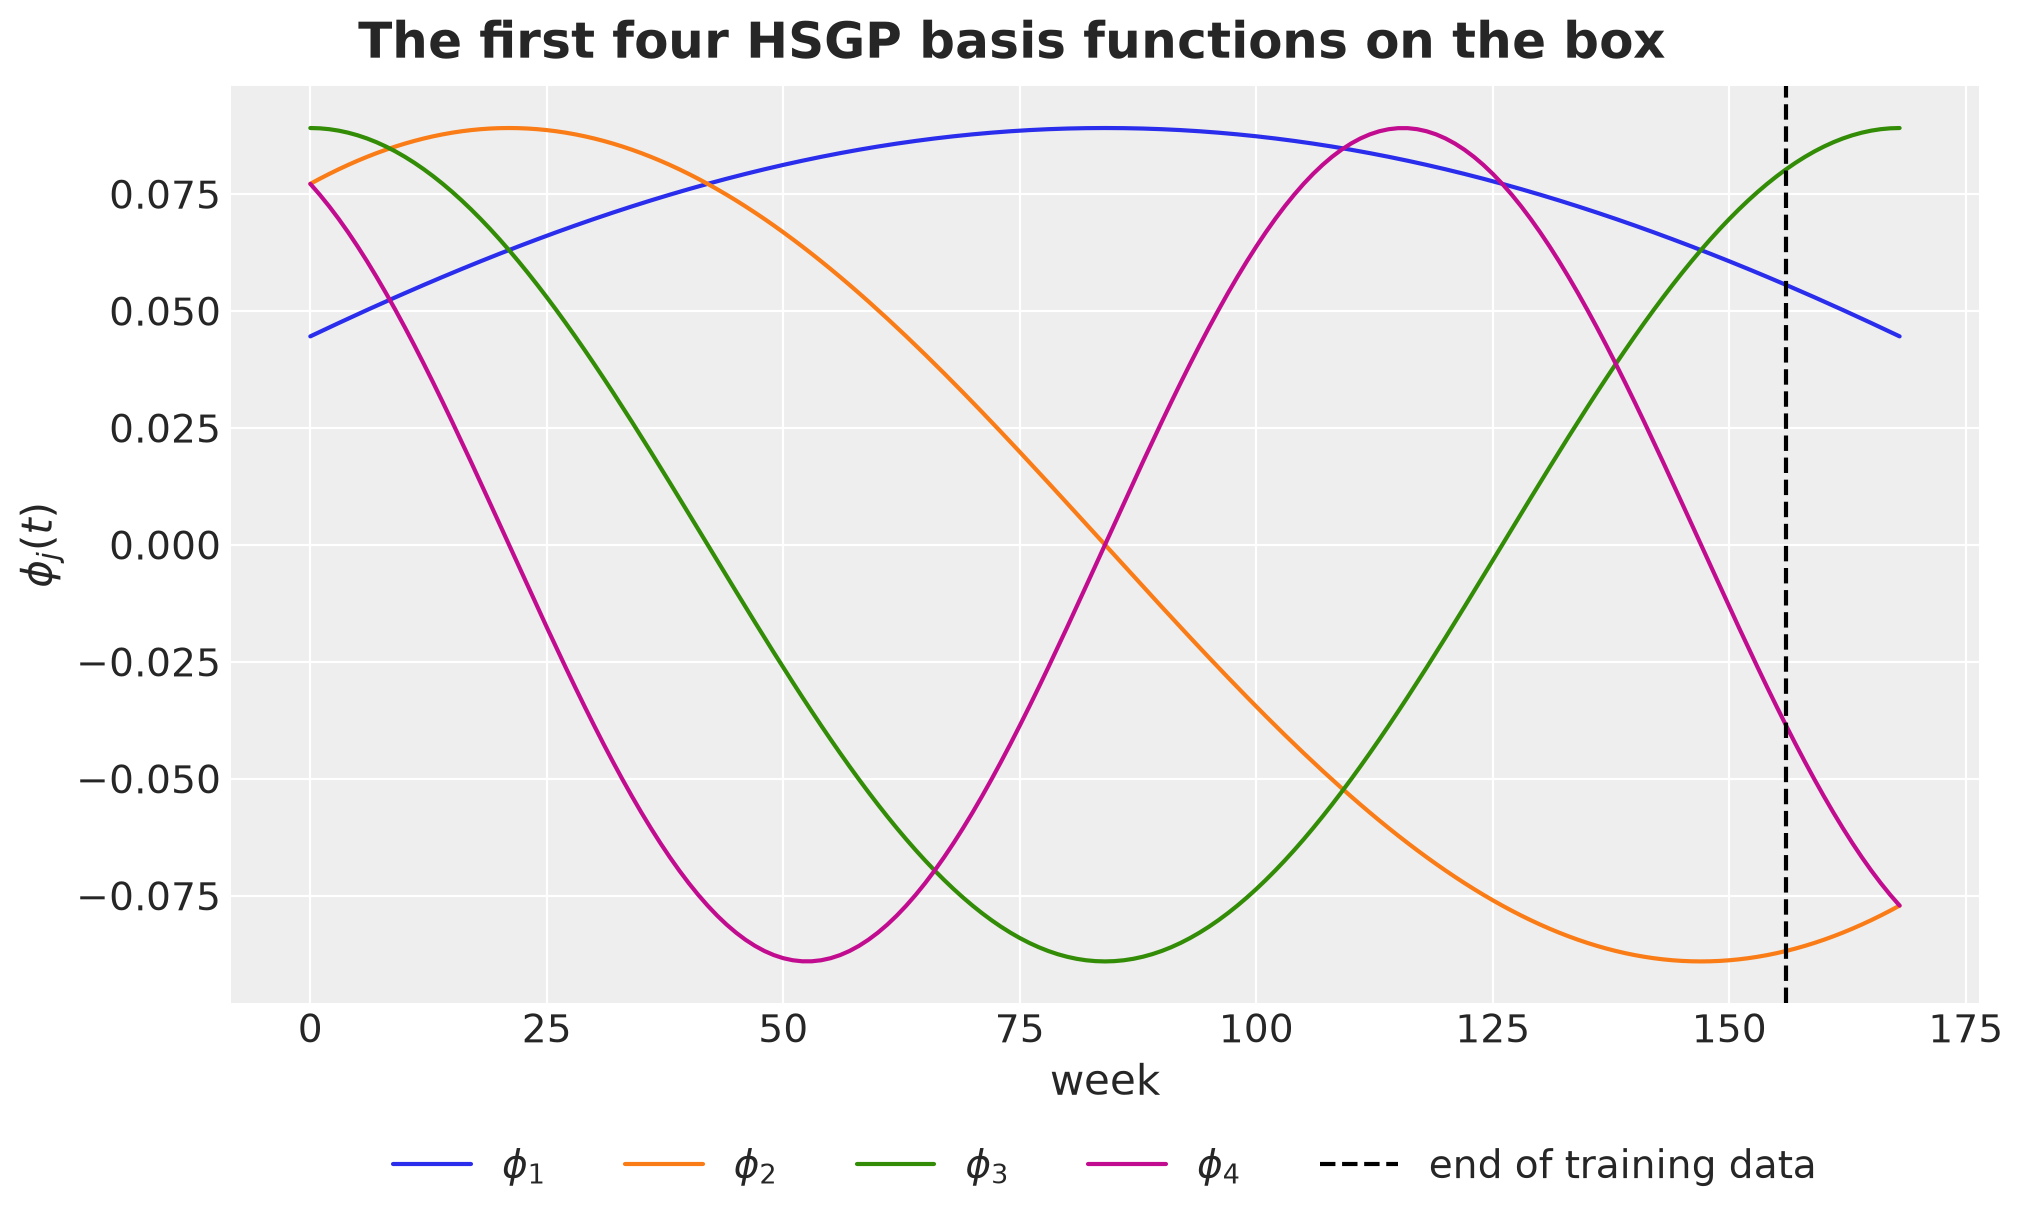

In [5]:
fig, ax = plt.subplots()

for j in range(4):
    ax.plot(t_grid, phi_full[:, j], label=f"$\\phi_{{{j + 1}}}$")
ax.axvline(x=T_OBS, color="black", linestyle="--", label="end of training data")
ax.set(xlabel="week", ylabel="$\\phi_j(t)$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5)
fig.suptitle(
    "The first four HSGP basis functions on the box", fontsize=18, fontweight="bold"
);

The plot above only shows the weeks where we have data or a forecast. The basis lives on a larger box. Let's draw two basis functions over the whole box $[-L, L]$, with the training weeks, the forecast horizon, and the padding on both sides.

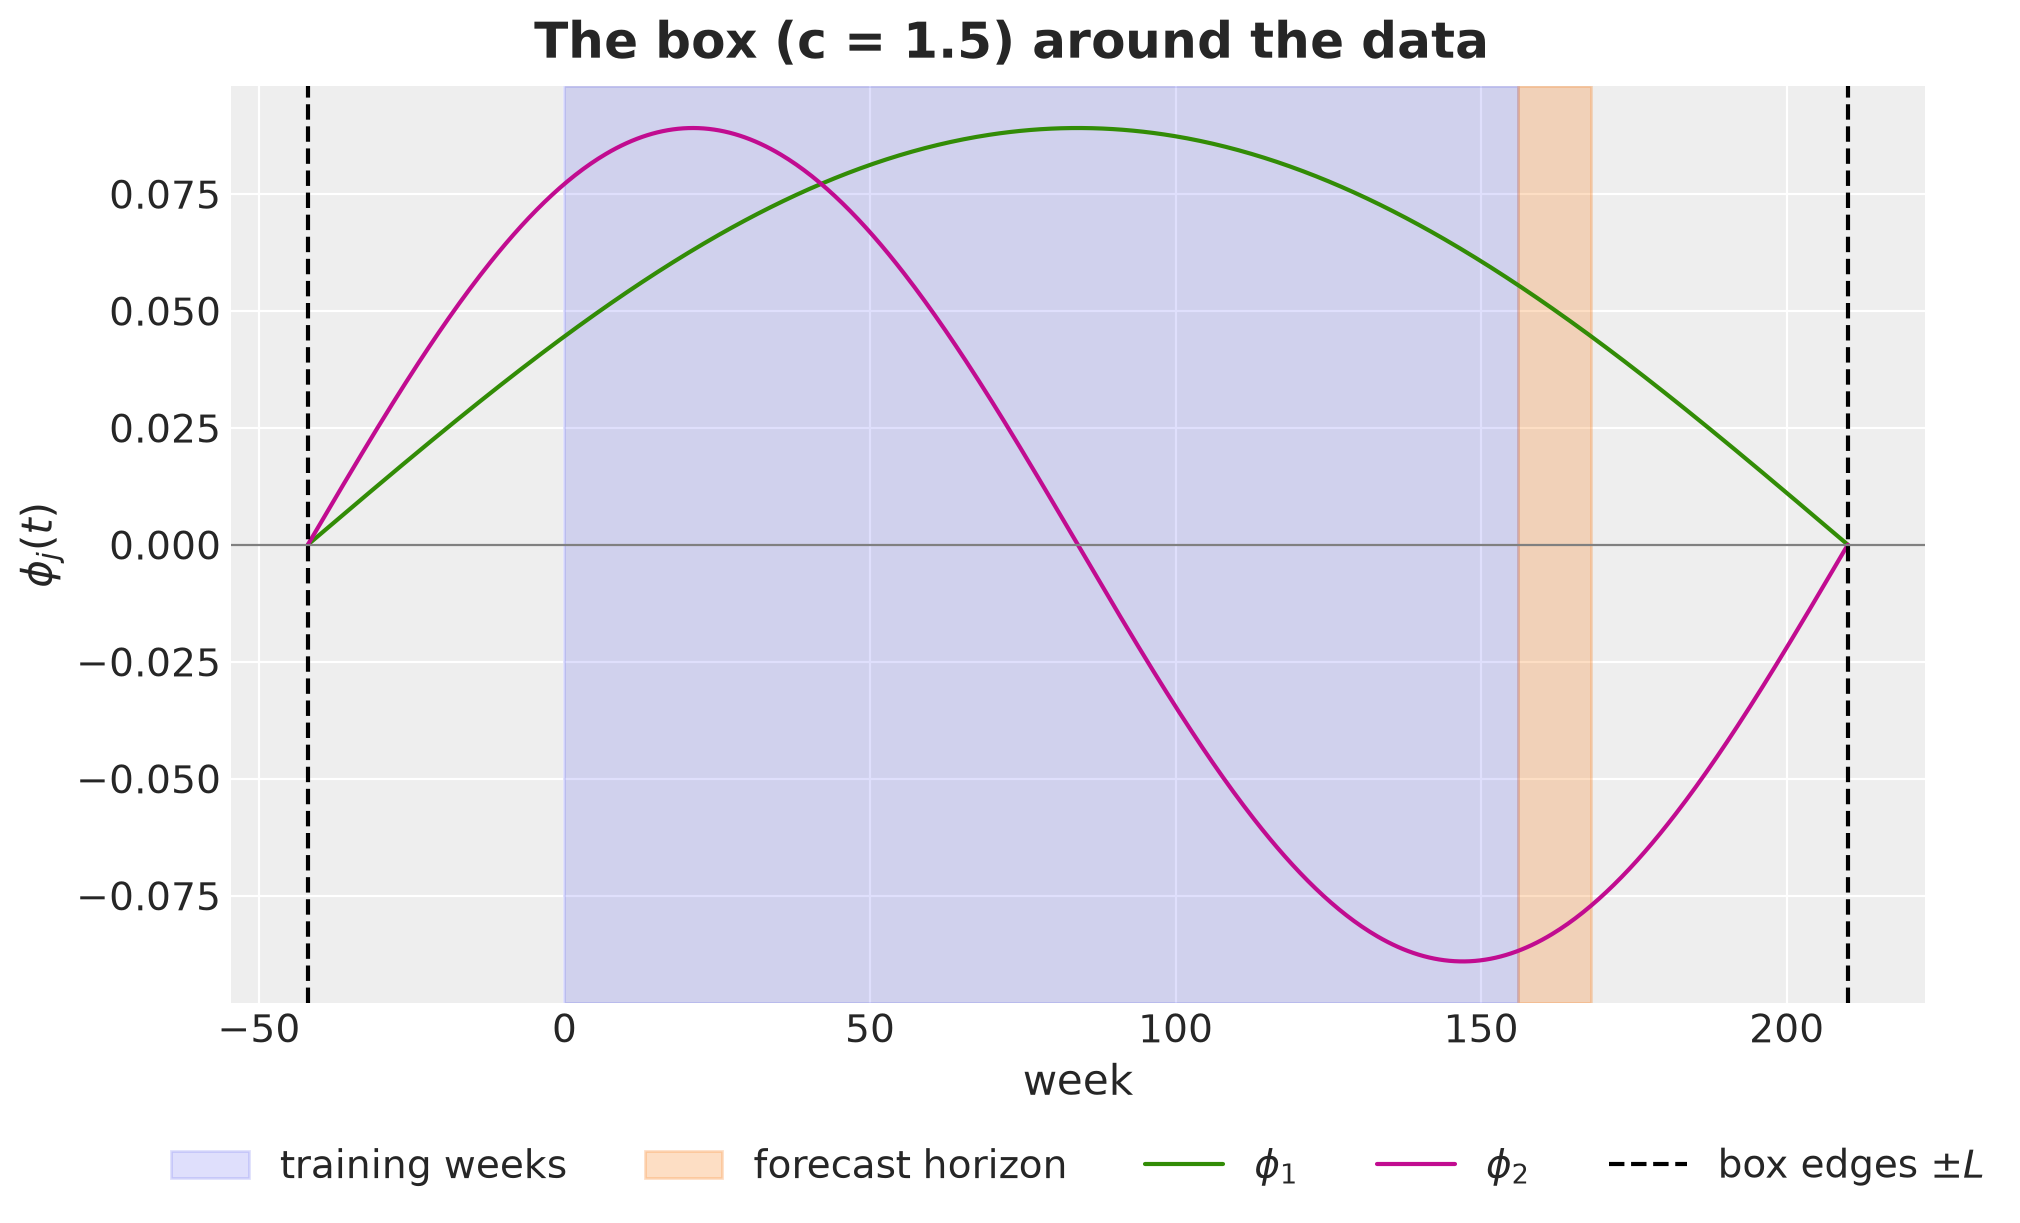

In [6]:
t_box = jnp.linspace(-ell_box, ell_box, 600)
phi_box = eigenfunctions(t_box, ell=ell_box, m=2)
week_box = np.asarray(t_box) + (DURATION - 1) / 2.0  # box coordinate -> week

fig, ax = plt.subplots()
ax.axvspan(0, T_OBS, color="C0", alpha=0.15, label="training weeks")
ax.axvspan(T_OBS, DURATION - 1, color="C1", alpha=0.25, label="forecast horizon")

for j in range(2):
    ax.plot(week_box, phi_box[:, j], color=f"C{j + 2}", label=f"$\\phi_{{{j + 1}}}$")

ax.axvline(x=week_box[0], color="black", linestyle="--")
ax.axvline(x=week_box[-1], color="black", linestyle="--", label="box edges $\\pm L$")
ax.axhline(y=0.0, color="gray", linewidth=0.8)
ax.set(xlabel="week", ylabel="$\\phi_j(t)$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=5)
fig.suptitle(f"The box (c = {C_BOX}) around the data", fontsize=18, fontweight="bold");

Every basis function is zero at the box edges (the Dirichlet condition), so the approximate process is pinned to zero there. With $c = 1.5$ the edges sit about $40$ weeks away from the first training week and from the last forecast week, far enough for a lengthscale of $20$ weeks. This is why we take $c > 1$: the padding keeps the artificial zero away from the forecast.

The weights $S(\sqrt{\lambda_j})$ decide how much each frequency contributes. We evaluate the Matérn-$3/2$ spectral density (the `numpyro` implementation of the formula above) at the eigenvalues for three lengthscales.

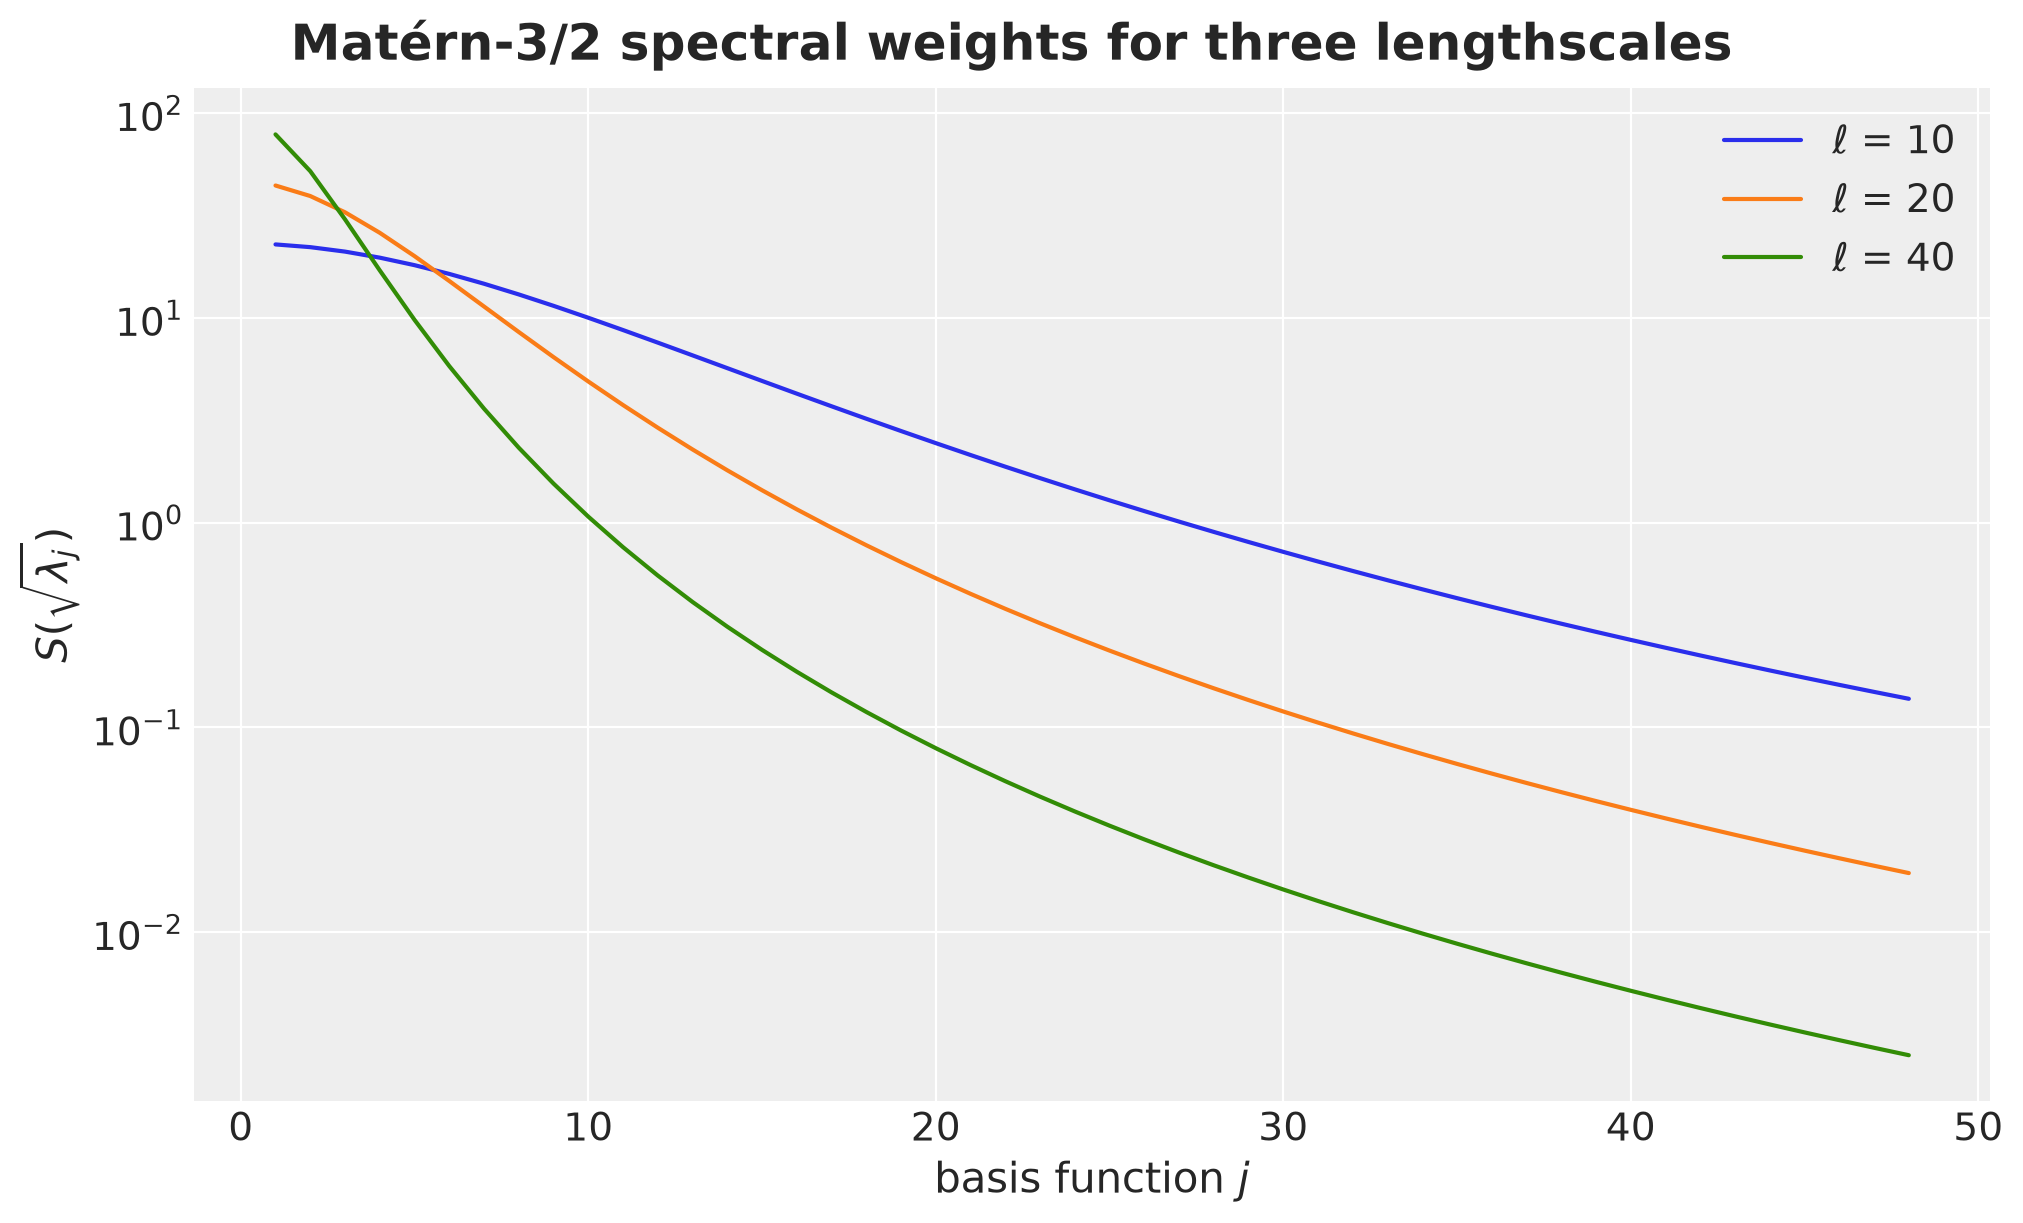

In [7]:
fig, ax = plt.subplots()

for length in [10.0, 20.0, 40.0]:
    s_j = diag_spectral_density_matern(
        nu=NU, alpha=1.0, length=length, ell=ell_box, m=M_BASIS, dim=1
    )
    ax.plot(np.arange(1, M_BASIS + 1), s_j, label=f"$\\ell$ = {length:.0f}")

ax.set(xlabel="basis function $j$", ylabel="$S(\\sqrt{\\lambda_j})$", yscale="log")
ax.legend()
fig.suptitle(
    "Matérn-3/2 spectral weights for three lengthscales", fontsize=18, fontweight="bold"
);

A longer lengthscale concentrates the weight on the first few basis functions. This is also why the basis can be truncated: for $\ell = 20$ the weight of $j = 48$ is more than three orders of magnitude below the weight of $j = 1$ (a factor of about $2300$).

We now compare the approximate kernel $\sum_j S(\sqrt{\lambda_j}) \phi_j(t) \phi_j(t')$ with the exact Matérn-$3/2$ kernel $k(\tau) = \sigma_f^2 (1 + \sqrt{3} |\tau| / \ell) \exp(-\sqrt{3} |\tau| / \ell)$, as a function of $t$ for a fixed $t'$ in the middle of the data.

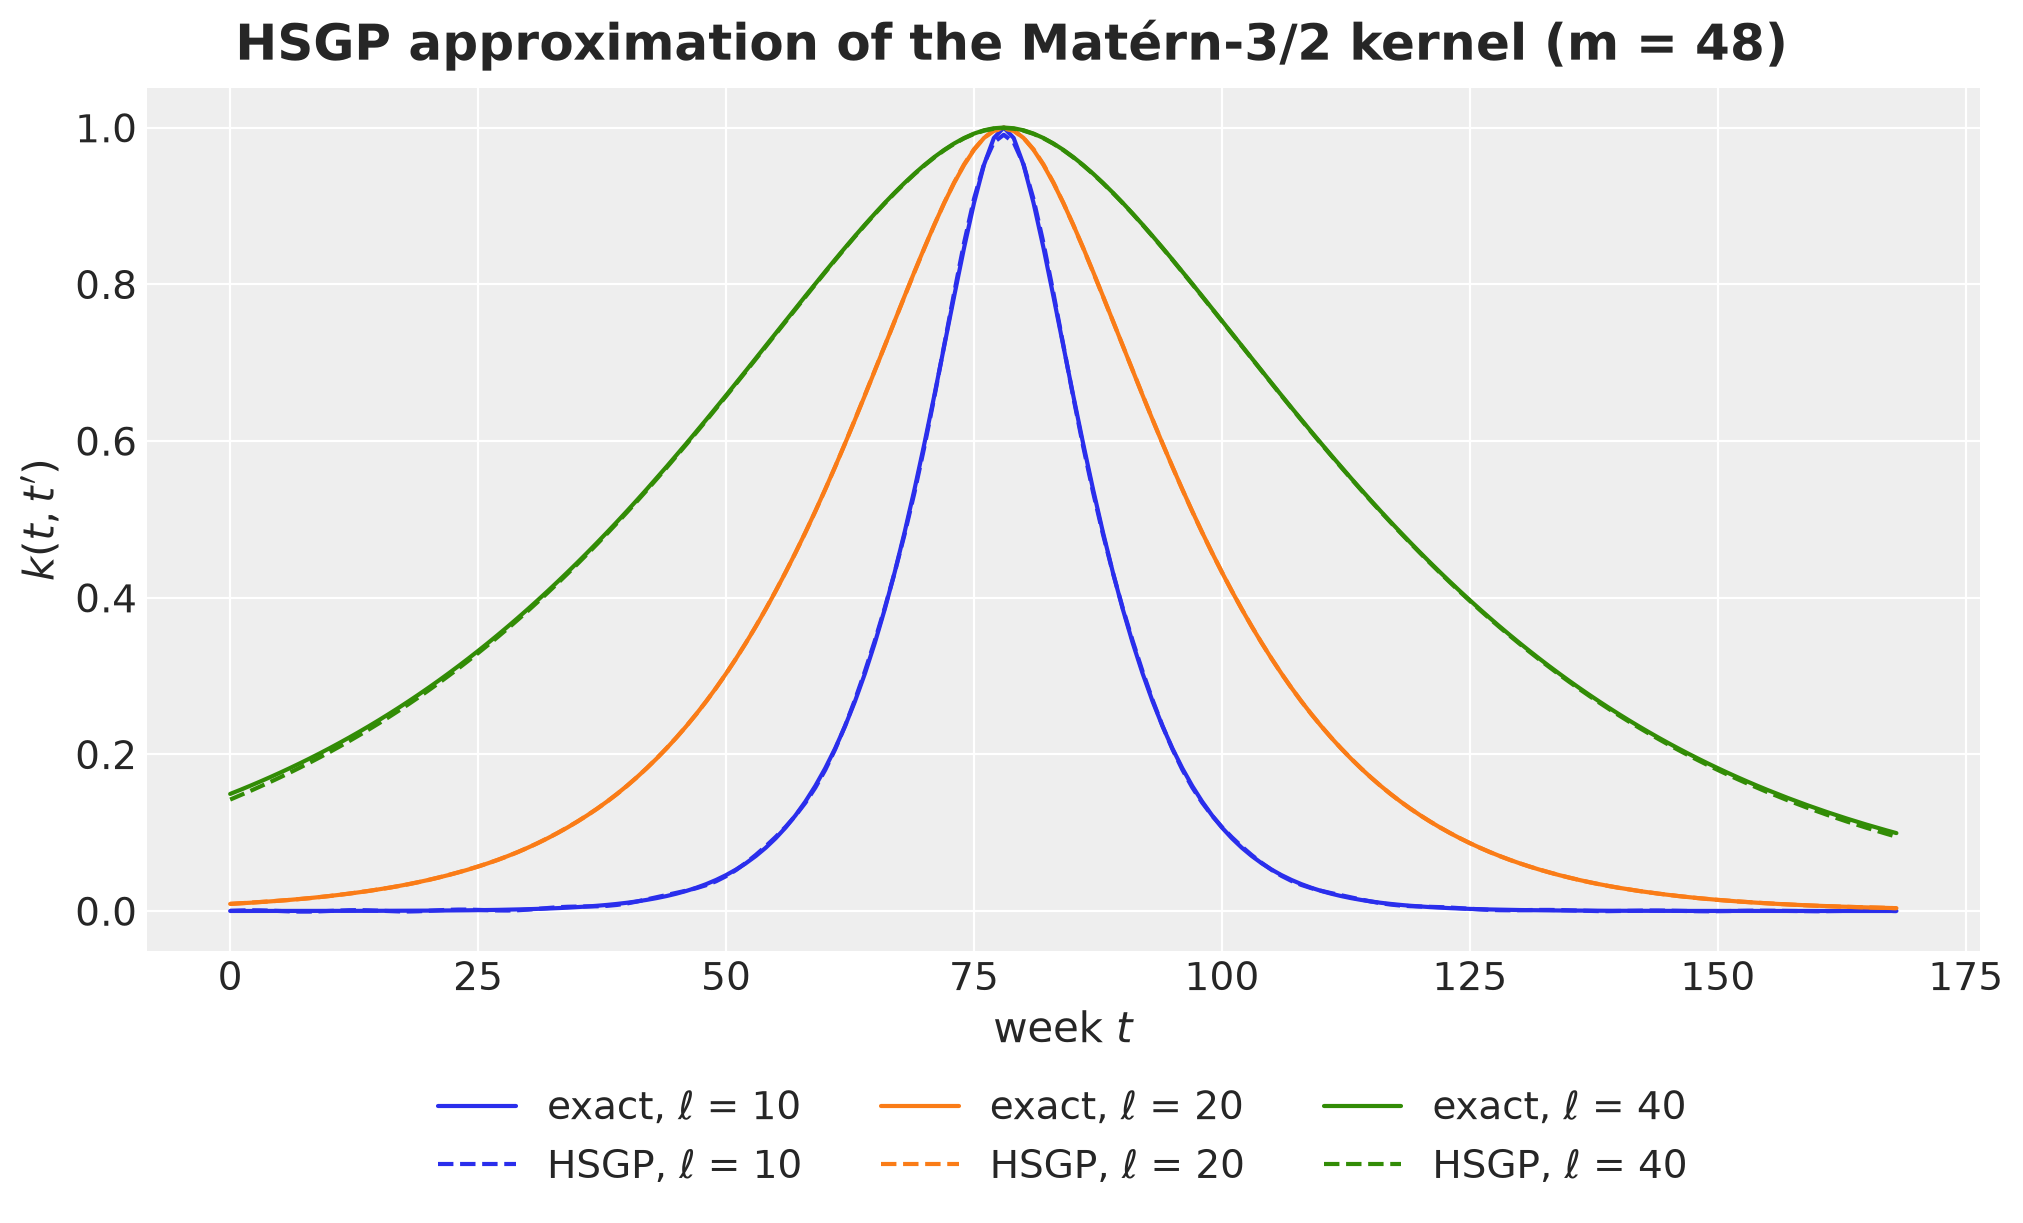

In [8]:
def matern32_kernel(tau: Array, length: float, sigma_f: float = 1.0) -> Array:
    "Exact Matérn-3/2 kernel as a function of the time difference tau."
    d = jnp.sqrt(3.0) * jnp.abs(tau) / length
    return sigma_f**2 * (1.0 + d) * jnp.exp(-d)


t_ref = T_OBS // 2
fig, ax = plt.subplots()

for i, length in enumerate([10.0, 20.0, 40.0]):
    s_j = diag_spectral_density_matern(
        nu=NU, alpha=1.0, length=length, ell=ell_box, m=M_BASIS, dim=1
    )
    k_hsgp = (phi_full * s_j) @ phi_full[t_ref]  # sum_j S_j phi_j(t) phi_j(t_ref)
    k_exact = matern32_kernel(t_grid - t_grid[t_ref], length)
    ax.plot(t_grid, k_exact, color=f"C{i}", label=f"exact, $\\ell$ = {length:.0f}")
    ax.plot(
        t_grid,
        k_hsgp,
        color=f"C{i}",
        linestyle="--",
        label=f"HSGP, $\\ell$ = {length:.0f}",
    )
ax.set(xlabel="week $t$", ylabel="$k(t, t')$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
fig.suptitle(
    f"HSGP approximation of the Matérn-3/2 kernel (m = {M_BASIS})",
    fontsize=18,
    fontweight="bold",
);

The approximation is accurate for these lengthscales and $m = 48$. It degrades when $\ell$ is short relative to the box, because the density then has power beyond the last basis frequency $\omega_m$. We come back to this in the section on the basis size.

### The Graph Laplacian

Let $A$ be the adjacency matrix of the graph and $D_G$ the diagonal matrix of node degrees $d_r = \sum_{r'} A_{r r'}$. The graph Laplacian is $L_G = D_G - A$. For any vector $x$ on the nodes,

$$
x^\top L_G x = \frac{1}{2} \sum_{r, r'} A_{r r'} (x_r - x_{r'})^2 .
$$

What does this quantity mean? A vector $x$ assigns one number $x_r$ to every node, for example the deviation of region $r$ from the national level. The right-hand side runs over the edges of the graph and adds up the squared difference between the two endpoints of each edge.

It is zero when $x$ is constant, small when connected nodes agree, and large when they disagree. That is what we mean by *rough* over the graph: a rough vector is one that changes a lot between neighbors.

The continuous counterpart is $\int \left(f'(t)\right)^2 dt$, which measures in exactly the same way how rough a function $f$ of time is on an interval. The graph quadratic form replaces the derivative of $f$ by the difference of $x$ along an edge. See [Laplacian Eigenmaps](https://juanitorduz.github.io/laplacian_eigenmaps_dim_red/) and the [PyData Berlin 2018 slides](https://juanitorduz.github.io/documents/orduz_pydata2018.pdf) for a longer discussion.

Now, $L_G$ is symmetric and positive semidefinite, so it has an orthonormal eigendecomposition $L_G = U \operatorname{diag}(\mu) U^\top$ with eigenvalues $0 = \mu_0 \le \mu_1 \le \cdots \le \mu_{R - 1}$ and eigenvectors $u_v$ (the columns of $U$). The eigenvalue is the roughness of its own eigenvector, $\mu_v = u_v^\top L_G u_v$.

The first eigenvector $u_0$ is constant. Eigenvectors with larger $\mu_v$ oscillate faster over the graph, in the same sense that $\sin(\omega_j t)$ oscillates faster for larger $j$. This makes the pair $(\mu_v, u_v)$ the graph analogue of $(\lambda_j, \phi_j)$.

The cleanest way to see this is on the simplest graph there is, a path. Its Laplacian is the discrete second derivative, so its eigenvectors are discrete cosines and they are the exact graph analogue of the sine basis we plotted above.

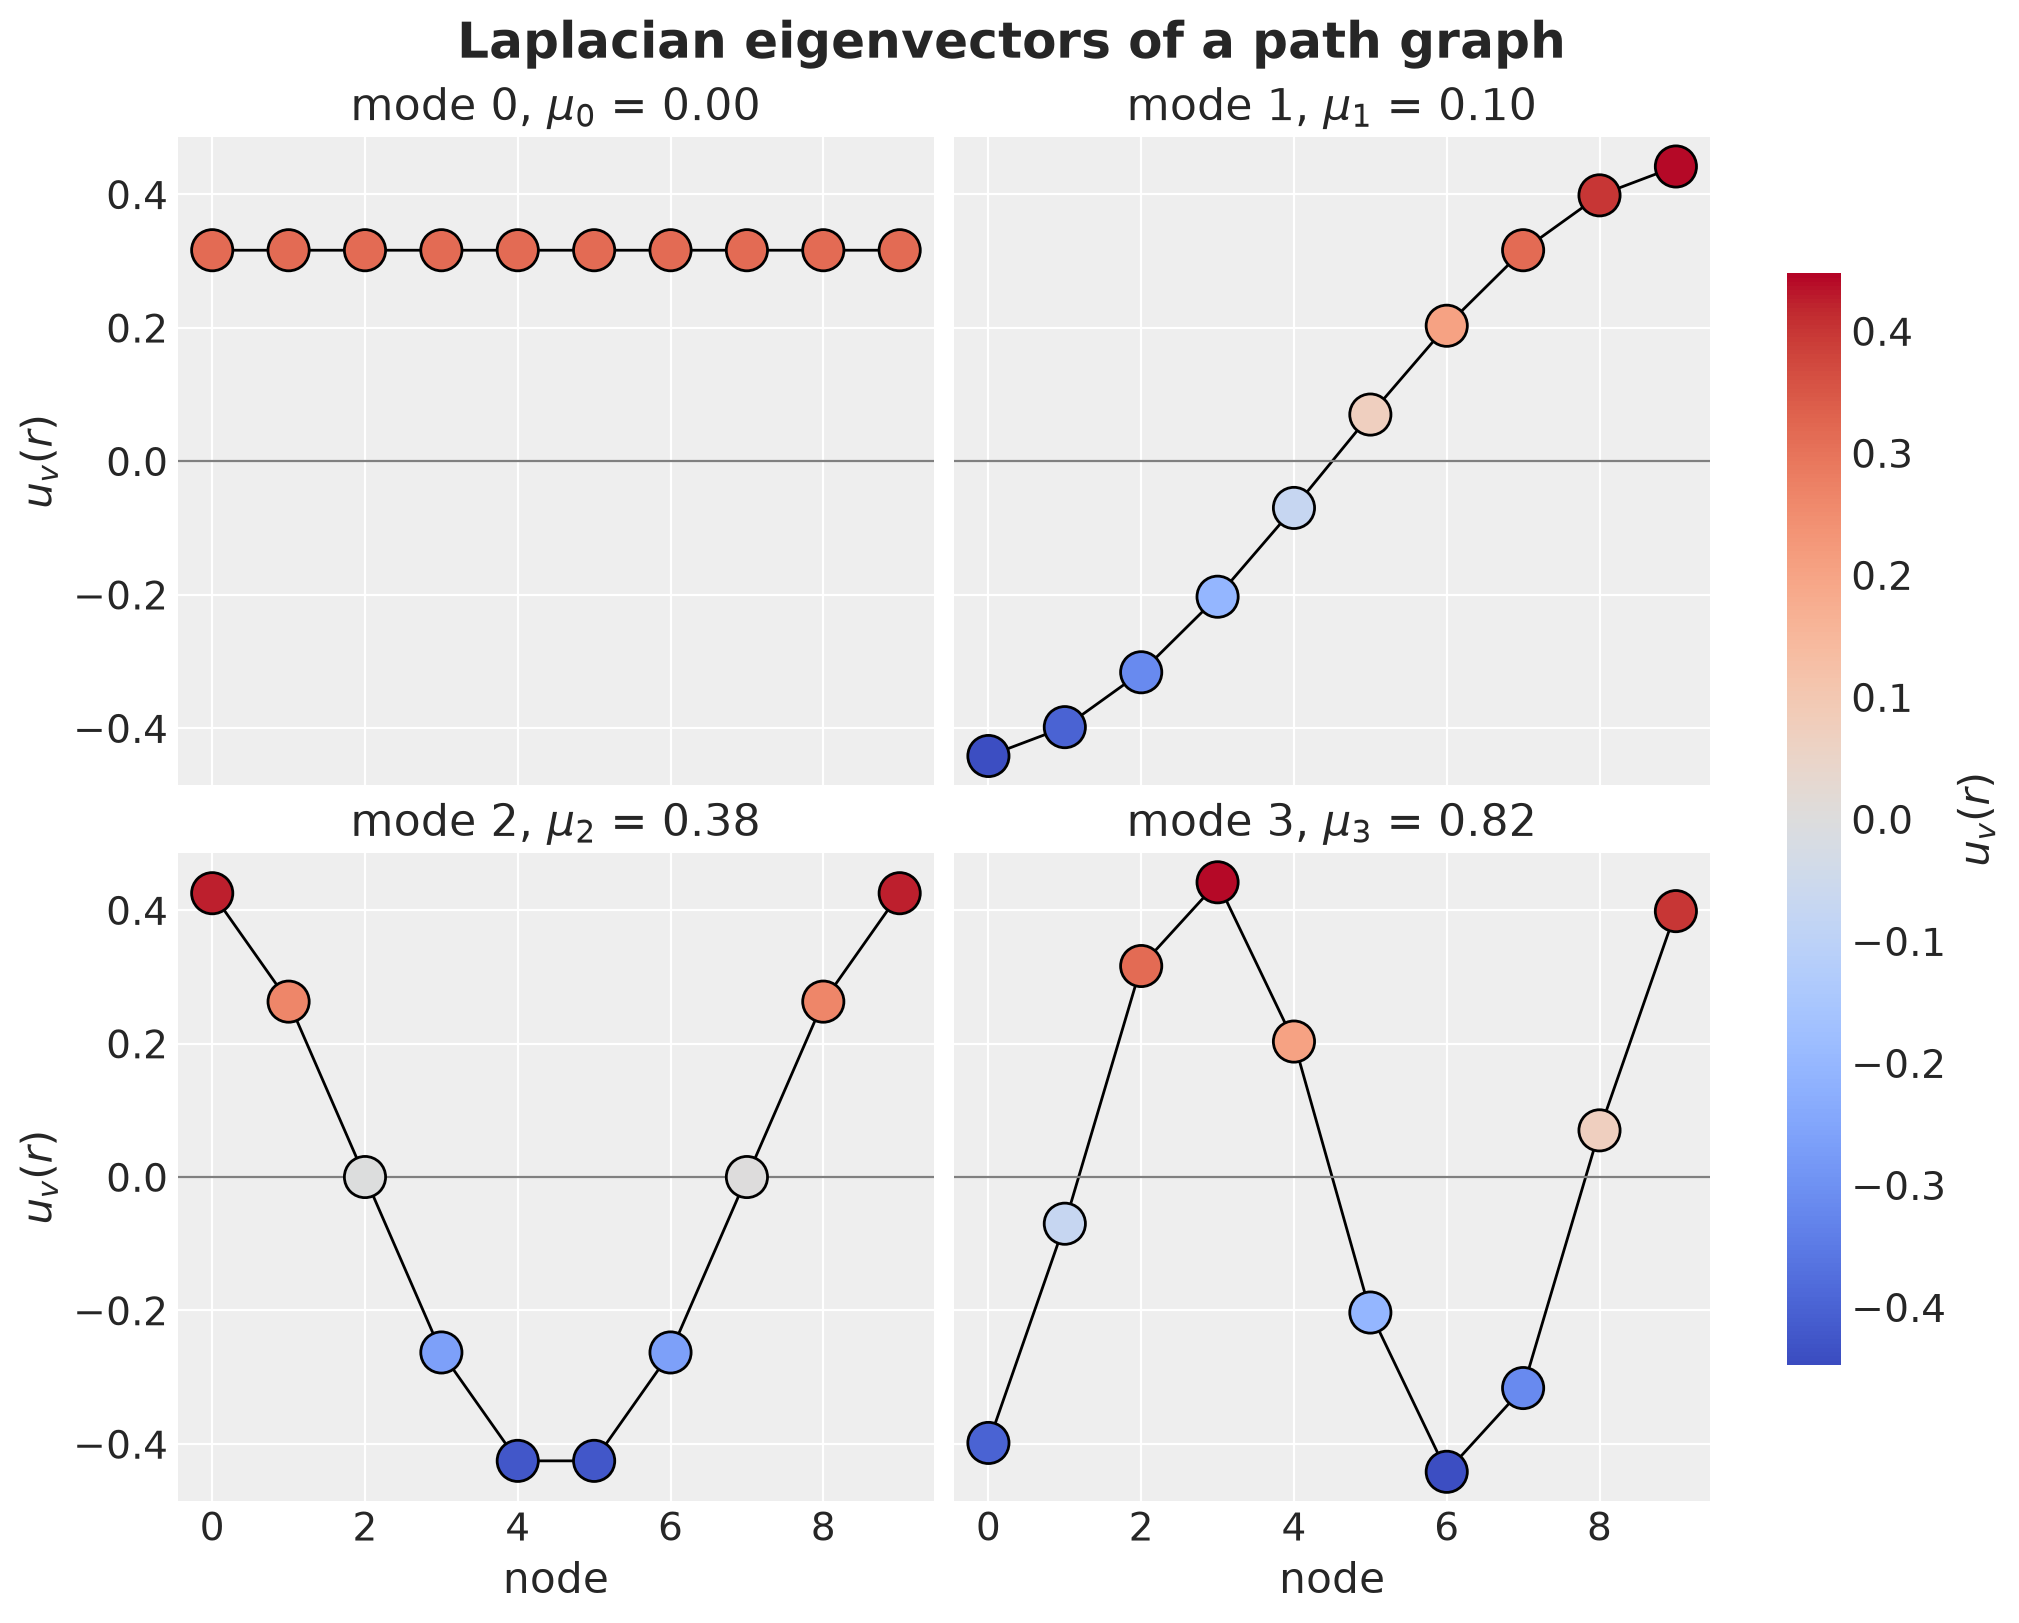

In [20]:
def path_laplacian(n: int) -> Float[Array, "n n"]:
    "Laplacian of a path with n nodes (the discrete second derivative)."
    adjacency = jnp.diag(jnp.ones(n - 1), k=1) + jnp.diag(jnp.ones(n - 1), k=-1)
    return jnp.diag(adjacency.sum(axis=1)) - adjacency


n_pts = 10
mu_path, u_path = jnp.linalg.eigh(path_laplacian(n_pts))
mu_path = jnp.clip(mu_path, 0.0, None).at[0].set(0.0)
node_index = np.arange(n_pts)
vmax_path = float(jnp.abs(u_path).max())

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(10, 8),
    sharex=True,
    sharey=True,
    layout="constrained",
)

axes = axes.flatten()

for v, ax in enumerate(axes):
    values = np.asarray(u_path[:, v])
    ax.axhline(y=0.0, color="gray", linewidth=0.8)
    ax.plot(node_index, values, color="black", linewidth=1, zorder=1)
    scatter = ax.scatter(
        node_index,
        values,
        c=values,
        cmap="coolwarm",
        vmin=-vmax_path,
        vmax=vmax_path,
        s=220,
        zorder=2,
        edgecolor="black",
    )
    ax.set(title=f"mode {v}, $\\mu_{{{v}}}$ = {mu_path[v]:.2f}")

axes[0].set(ylabel="$u_v(r)$")
axes[2].set(xlabel="node", ylabel="$u_v(r)$")
axes[3].set(xlabel="node")
fig.colorbar(scatter, ax=axes, label="$u_v(r)$", shrink=0.8)
fig.suptitle("Laplacian eigenvectors of a path graph", fontsize=18, fontweight="bold");

Mode $0$ is constant, which is the average over the nodes. Mode $1$ splits the path into a positive half and a negative half. Higher modes change sign more often, and $\mu_v$ grows with the number of sign changes. This is the sense in which a graph mode with a large $\mu_v$ oscillates fast.

**Remark.** Each eigenvector is defined only up to a sign, and up to a rotation inside a group of repeated eigenvalues. In the plot above the blue and the red halves of a mode could be swapped without changing the kernel, so the sign of a mode carries no meaning by itself.

**Remark.** The quantity $\mu_0 = 0$ will represent the *national average* mode in the example below. This reading of $\mu_0$ requires a *connected* graph. On a disconnected one the eigenvalue zero is repeated once per component and there is no single average mode. We check connectivity below.

We now have two Laplacians: the Dirichlet Laplacian on the time box and the graph Laplacian. Each one has an eigenbasis, and on each one the same recipe, evaluate the spectral density at the eigenvalues, defines a kernel.

On the graph that recipe gives the Matérn Gaussian process of [Borovitskiy et al. (2021)](https://proceedings.mlr.press/v130/borovitskiy21a.html), $K_G = \sum_v S(\sqrt{\mu_v})\, u_v u_v^\top$. What is left is to combine the two into a single kernel on the product space, and that is the subject of the next two sections.

### The Kronecker Product

Let's come back to the setting we care about. Our index has two parts, a week and a region, so we need a basis on the product space *interval times graph*, whose functions take a time and a region. We already have the two ingredients, $(\lambda_j, \phi_j)$ on the interval and $(\mu_v, u_v)$ on the graph. There are two ways to combine two operators, the Kronecker product and the Kronecker sum. They share their eigenvectors and differ in their eigenvalues, and that difference is the whole story of this notebook. We start with the product.

The Kronecker product of a matrix $P$ (size $m \times m$, acting on time) and a matrix $Q$ (size $R \times R$, acting on the graph) is a matrix $P \otimes Q$ of size $mR \times mR$, built out of $m \times m$ blocks of size $R \times R$. It acts on functions of the form $\phi \otimes u$, that is $(\phi \otimes u)(t, r) = \phi(t)\, u(r)$, one factor at a time. If $P \phi_j = \lambda_j \phi_j$ and $Q u_v = \mu_v u_v$, then

$$
(P \otimes Q)\, (\phi_j \otimes u_v) = (P \phi_j) \otimes (Q u_v) = \lambda_j \mu_v\, (\phi_j \otimes u_v) ,
$$

so the product functions $\phi_j(t) u_v(r)$ are eigenvectors and the eigenvalues *multiply*.

*Why do we call it a product?* To see this, let's look into the covariance of a separable kernel, i.e. a kernel that factorizes into a product of a time kernel and a graph kernel. If $k((t, r), (t', r')) = k_t(t, t')\, k_G(r, r')$, then the covariance matrix on the grid is $K = K_t \otimes K_G$. With $K_t \approx \sum_j S_t(\sqrt{\lambda_j})\, \phi_j \phi_j^\top$ and $K_G = \sum_v S_G(\sqrt{\mu_v})\, u_v u_v^\top$, the eigenvalues of $K$ are the *products of the two spectra*, $S_t(\sqrt{\lambda_j})\, S_G(\sqrt{\mu_v})$, with eigenvectors $\phi_j \otimes u_v$. This is the structure that the PyMC [HSGP Kronecker example](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/HSGP-Advanced.html#example-2-an-hsgp-that-exploits-kronecker-structure) exploits, and it is the `separable` kernel below.

Let's check the eigenvalue rules on a simple example: the Laplacian of a path with three time points and the Laplacian of a path graph with three nodes. We build the Kronecker product with `jnp.kron`, and we compare their eigenvalues with the products and the sums of the factor eigenvalues.

In [29]:
n_pts = 3

P = path_laplacian(n_pts)  # time
Q = path_laplacian(n_pts)  # graph
lam_p, phi_p = jnp.linalg.eigh(P)
mu_q, u_q = jnp.linalg.eigh(Q)

kron_product = jnp.kron(P, Q)

eig_product = jnp.linalg.eigvalsh(kron_product)

assert jnp.allclose(eig_product, jnp.sort(jnp.outer(lam_p, mu_q).ravel()), atol=1e-5)

j, v = 1, 2
vector = jnp.kron(phi_p[:, j], u_q[:, v])  # the product function phi_j (x) u_v
assert jnp.allclose(kron_product @ vector, lam_p[j] * mu_q[v] * vector, atol=1e-5)

The results agree as expected.

### The Kronecker Sum

The Kronecker sum of the two operators is $P \oplus Q = P \otimes I + I \otimes Q$: apply $P$ along time and $Q$ along the graph, and add. The product functions are again eigenvectors, and now the eigenvalues *add*:

$$
(P \oplus Q)\, (\phi_j \otimes u_v) = (P \phi_j) \otimes u_v + \phi_j \otimes (Q u_v) = (\lambda_j + \mu_v)\, (\phi_j \otimes u_v) .
$$



Observe that the Kronecker sum is also a matrix of size $mR \times mR$. 

Let's verify the analogous rules on the same example.

In [31]:
kron_sum = jnp.kron(P, jnp.eye(3)) + jnp.kron(jnp.eye(3), Q)

eig_sum = jnp.linalg.eigvalsh(kron_sum)


assert jnp.allclose(
    eig_sum, jnp.sort((lam_p[:, None] + mu_q[None, :]).ravel()), atol=1e-5
)

assert jnp.allclose(kron_sum @ vector, (lam_p[j] + mu_q[v]) * vector, atol=1e-5)

Now, let's compare the set of eigenvalues: the same nine pairs $(j, v)$, once multiplied and once added.

In [40]:
pairs = [(j, v) for j in range(n_pts) for v in range(n_pts)]

pl.DataFrame(
    {
        "j": [j for j, _ in pairs],
        "v": [v for _, v in pairs],
        "lambda_j": [round(lam_p[j], 3) for j, _ in pairs],
        "mu_v": [round(mu_q[v], 3) for _, v in pairs],
        "product": [round(lam_p[j] * mu_q[v], 3) for j, v in pairs],
        "sum": [round(lam_p[j] + mu_q[v], 3) for j, v in pairs],
    }
)

j,v,lambda_j,mu_v,product,sum
i64,i64,f64,f64,f64,f64
0,0,-0.0,-0.0,0.0,-0.0
0,1,-0.0,1.0,-0.0,1.0
0,2,-0.0,3.0,-0.0,3.0
1,0,1.0,-0.0,-0.0,1.0
1,1,1.0,1.0,1.0,2.0
1,2,1.0,3.0,3.0,4.0
2,0,3.0,-0.0,-0.0,3.0
2,1,3.0,1.0,3.0,4.0
2,2,3.0,3.0,9.0,6.0


Observe that the product has a zero eigenvalue whenever $\lambda_j = 0$ *or* $\mu_v = 0$, while the sum is zero only when both are. This matters for us: the constant graph mode has $\mu_0 = 0$, so a Kronecker *product* of Laplacians assigns eigenvalue zero to every function of the form $\phi_j(t) u_0(r)$ and cannot tell a slow national trend from a fast one.

Next we move from the $3 \times 3$ toy example to the sizes of our own problem, so that the plots in the rest of this section show realistic magnitudes. We fix the values used for the illustrations ($\ell = 20$ weeks, $\rho = 2$, $\nu = 3/2$), we take the $48$ time eigenvalues $\lambda_j$ of the box, and we use a grid of graph eigenvalues $\mu \in [0, 10]$ that covers the range of the German graph we build below.

In [41]:
LENGTH_0 = 20.0
RHO_0 = 2.0
SIGMA_F_0 = 1.0
KAPPA2_0 = 2.0 * NU / LENGTH_0**2

lam = sqrt_eigenvalues(ell_box, M_BASIS, dim=1)[0] ** 2  # (m,) time eigenvalues
mu_grid = jnp.linspace(0.0, 10.0, 101)  # stand-in for the graph eigenvalues
mu_show = jnp.array([0.0, 1.0, 5.0, 10.0])
mu_coarse = jnp.linspace(0.0, 10.0, 16)  # 16 graph modes, like the real graph
j_grid = np.arange(1, M_BASIS + 1)

We plot the two eigenvalue surfaces over the $(j, v)$ grid, the product $\lambda_j \mu_v$ and the raw sum $\lambda_j + \mu_v$, on a logarithmic color scale.

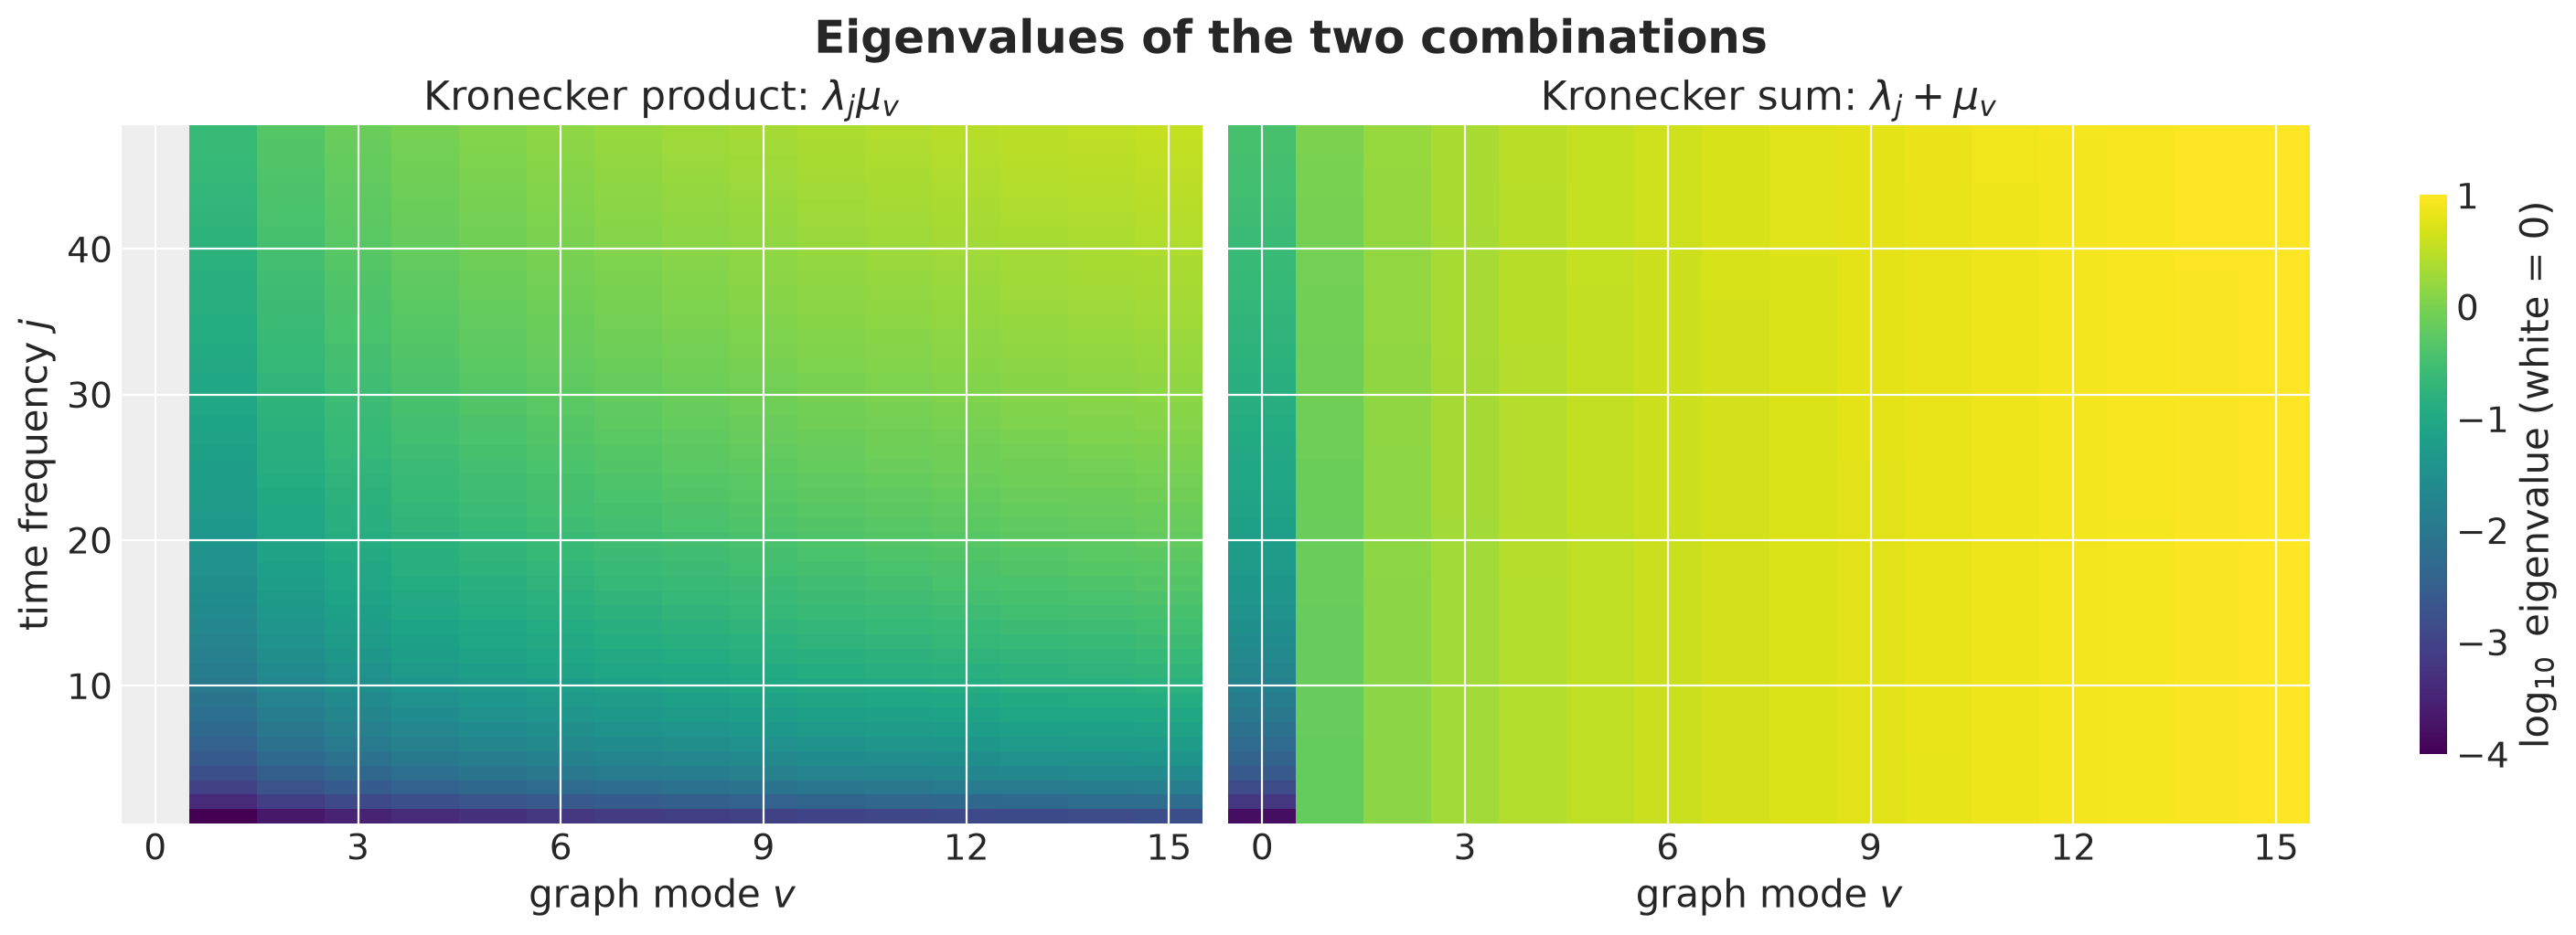

In [42]:
eig_product_grid = lam[:, None] * mu_coarse[None, :]
eig_sum_grid = lam[:, None] + mu_coarse[None, :]

fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(14, 5), sharey=True, layout="constrained"
)
for ax, surface, title in zip(
    axes,
    [eig_product_grid, eig_sum_grid],
    ["Kronecker product: $\\lambda_j \\mu_v$", "Kronecker sum: $\\lambda_j + \\mu_v$"],
    strict=True,
):
    values = np.asarray(surface)
    im = ax.imshow(
        np.log10(np.where(values > 0, values, np.nan)),
        aspect="auto",
        origin="lower",
        cmap="viridis",
        vmin=-4,
        vmax=1,
        extent=(-0.5, mu_coarse.shape[0] - 0.5, 0.5, M_BASIS + 0.5),
    )
    ax.set(title=title, xlabel="graph mode $v$", xticks=np.arange(0, 16, 3))
axes[0].set(ylabel="time frequency $j$")
fig.colorbar(im, ax=axes, label="$\\log_{10}$ eigenvalue (white = 0)", shrink=0.8)
fig.suptitle("Eigenvalues of the two combinations", fontsize=18, fontweight="bold");

The product surface has a white column at $v = 0$ (eigenvalue zero for every $j$) and otherwise varies in both directions. The raw sum is almost constant along $j$ for every $v > 0$: it is dominated by $\mu_v$, because $\lambda_j$ is at most $0.36$ while $\mu_v$ goes up to $10$. This is not a property of the graph, it is an artifact of adding quantities with different units, and it is the problem we fix next.

**Remark.** On the product space *interval times graph* the natural Laplacian is the Kronecker sum $-\Delta_t \oplus L_G$, because the Laplacian of a product space is the sum of the Laplacians of the factors (as $\partial_x^2 + \partial_y^2$ on the plane). Its eigenpairs are

$$
\left(\lambda_j + \mu_v,\; \phi_j(t)\, u_v(r)\right), \qquad j = 1, \ldots, m, \quad v = 0, \ldots, R - 1 .
$$

Recall that on the interval the kernel is the spectral density evaluated at the Laplacian eigenvalues, $S(\sqrt{\lambda_j})$. The same recipe on the product space evaluates $S$ at $\sqrt{\lambda_j + \mu_v}$. Before we can do that we have to fix the units problem we just saw.

#### Making the Scales Comparable in the Kronecker Sum

Here we present a critical point of the Kronecker sum of the two Laplacians. We look closer into the sum $\lambda_j + \mu_v$.

- **Units.** $\lambda_j = \omega_j^2$ is a squared frequency, with units of one over squared weeks. $\mu_v$ is a pure number: the graph has no length unit. Adding them is meaningless, and the result would change if we measured time in days instead of weeks. We need a squared rate in front of $\mu_v$ to make the two terms comparable.

- **Which rate.** The temporal Matérn kernel has exactly one squared rate, $\kappa^2 = 2\nu / \ell^2$, the frequency where its spectral density bends from flat to decaying. Using $\kappa^2$ as the conversion makes the construction scale-free: with $\omega^2 = \lambda_j + \kappa^2 \rho\, \mu_v$ (we will explain the $\rho$ in a moment) the argument of the density becomes $\omega^2 / \kappa^2 = \lambda_j / \kappa^2 + \rho\, \mu_v$, and $\lambda_j / \kappa^2 = \ell^2 \lambda_j / (2\nu)$ does not change if we change the time unit and $\ell$ together.

- **What is left.** After the conversion one dimensionless number remains, $\rho \ge 0$. It sets how much a unit of graph roughness $\mu_v$ costs in the units of the temporal spectrum. The term $\rho \mu_v$ is what the graph adds to the argument of the density, and it is added next to the $1$ that the temporal corner frequency contributes. A mode with $\rho \mu_v \ll 1$ is therefore treated almost like the constant mode, because the graph barely moves its weights, while a mode with $\rho \mu_v \gg 1$ is pushed far into the decaying tail. The crossover sits at $\mu_v = 1 / \rho$, so $1 / \rho$ is the level of graph roughness above which the graph starts to shorten a mode's memory and shrink its amplitude. Read the other way around, $\rho = \ell_G^2 / (2\nu)$ is a squared spatial lengthscale on the graph.

The graph eigenvalues are converted into the units of the time eigenvalues and added, and $\rho$ decides how strongly the graph penalizes rough spatial patterns. With $\rho = 0$ the graph drops out and the regions are independent. As $\rho$ grows, every mode except the constant one is pushed further into the tail of the density, so the regions are pulled toward the national average. Below we see this mode by mode. The next plot shows the converted eigenvalue surface $\lambda_j / \kappa^2 + \rho\, \mu_v$ for three pooling strengths. A small $\rho$ makes the surface vary mostly along $j$ (time dominates), a large $\rho$ mostly along $v$ (the graph dominates). We can visualize it in the following comparison plot:

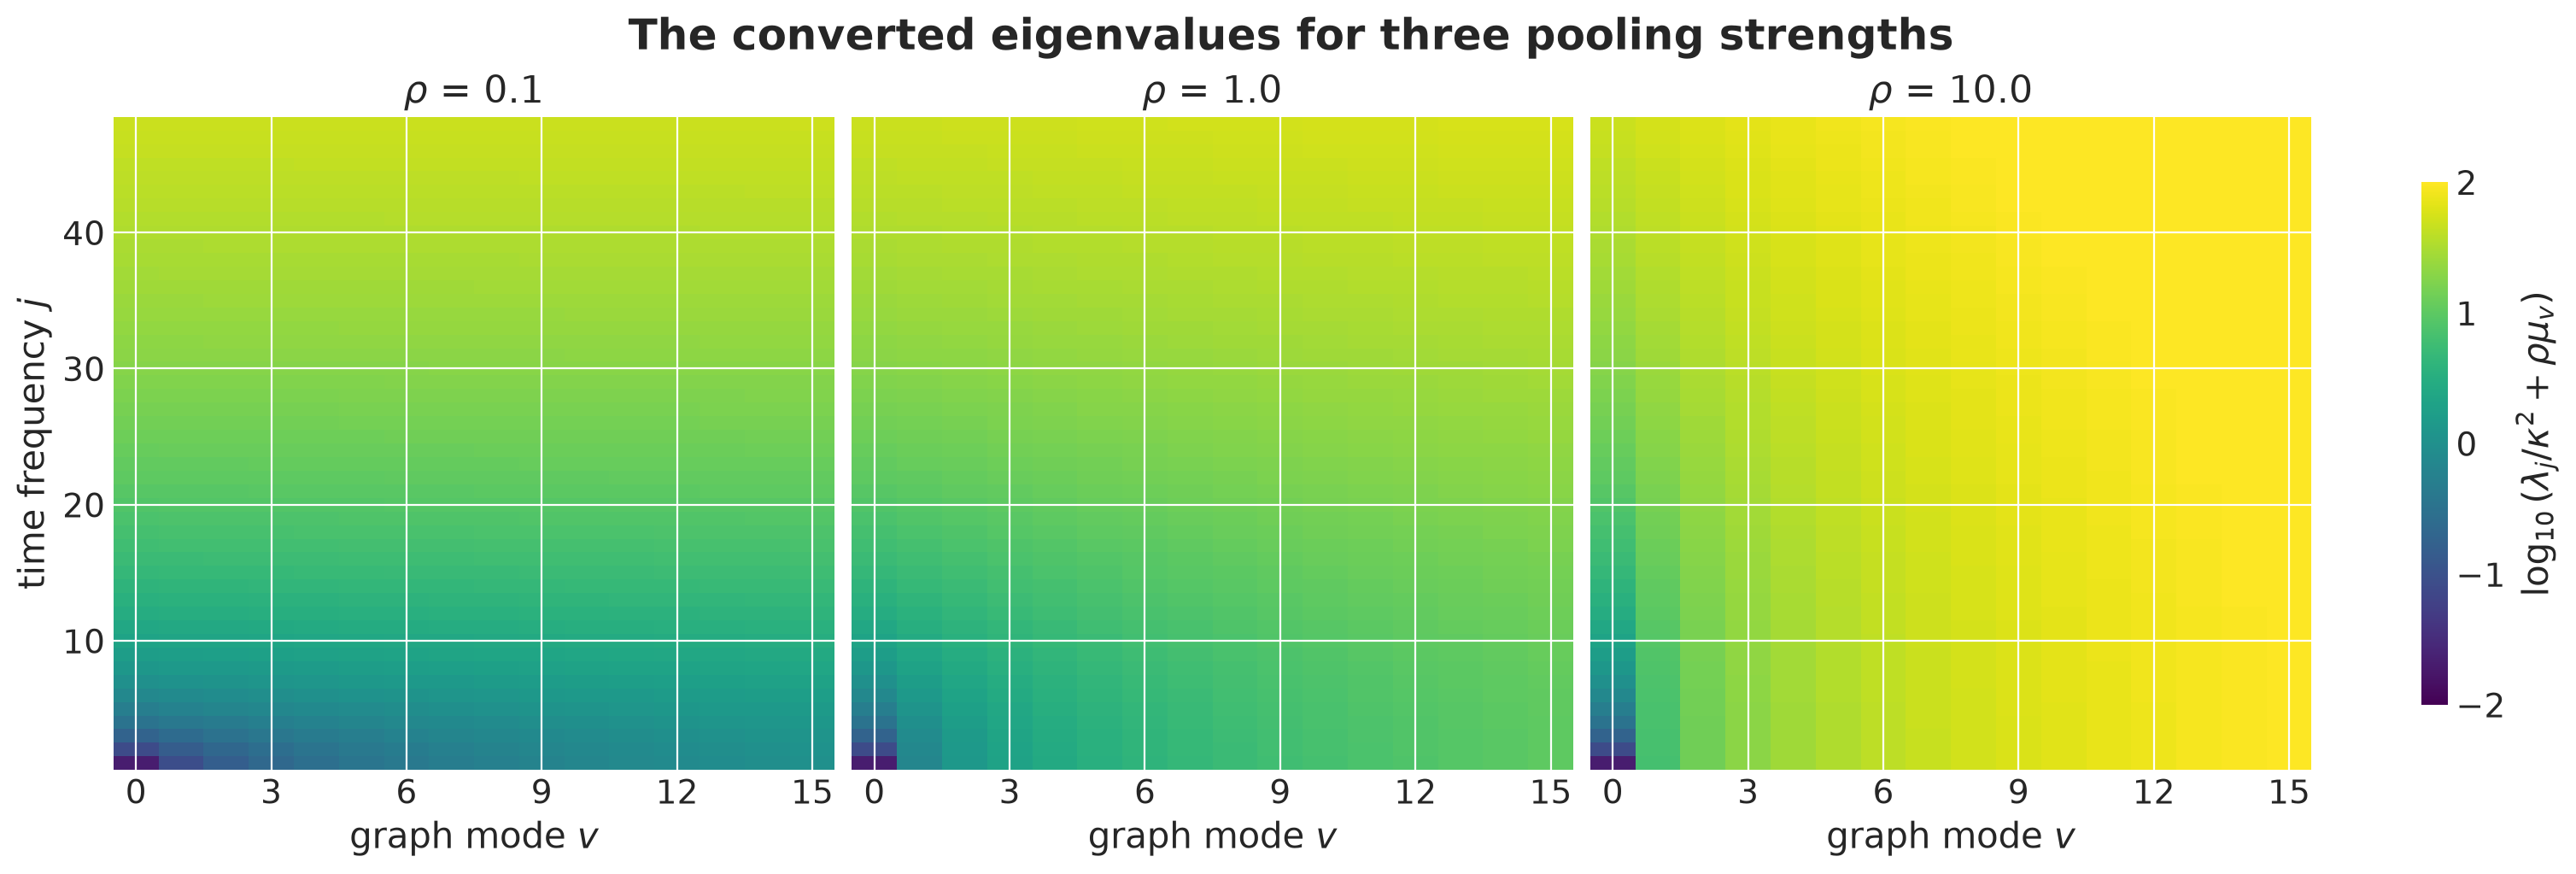

In [45]:
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(15, 5), sharey=True, layout="constrained"
)

for ax, rho in zip(axes, [0.1, 1.0, 10.0], strict=True):
    surface = np.asarray(lam[:, None] / KAPPA2_0 + rho * mu_coarse[None, :])
    im = ax.imshow(
        np.log10(surface),
        aspect="auto",
        origin="lower",
        cmap="viridis",
        vmin=-2,
        vmax=2,
        extent=(-0.5, mu_coarse.shape[0] - 0.5, 0.5, M_BASIS + 0.5),
    )
    ax.set(
        title=f"$\\rho$ = {rho}", xlabel="graph mode $v$", xticks=np.arange(0, 16, 3)
    )

axes[0].set(ylabel="time frequency $j$")
fig.colorbar(
    im, ax=axes, label="$\\log_{10}(\\lambda_j / \\kappa^2 + \\rho \\mu_v)$", shrink=0.8
)
fig.suptitle(
    "The converted eigenvalues for three pooling strengths",
    fontsize=18,
    fontweight="bold",
);

We want to understand the structural difference between the Kronecker product and the Kronecker sum by looking at the weights and the frequencies of the two HSGP approximations. Concretely, we evaluate the Matérn spectral density at the converted sum, $\omega^2 = \lambda_j + \kappa^2 \rho\, \mu_v$, with $\rho = 2$. Let's read the result off a picture first, and write it as a formula right after.

The next plot shows the Matérn density $S$ as a function of $\omega^2 / \kappa^2$, and on top of it the points where the sum evaluates it for three graph modes. For the constant mode ($\mu_v = 0$) the points are the usual HSGP weights $S(\sqrt{\lambda_j})$. For a rougher graph mode the same $m$ frequencies are shifted to the right by $\rho \mu_v$: they start further down the decaying part of the density, where the density is lower *and* flatter.

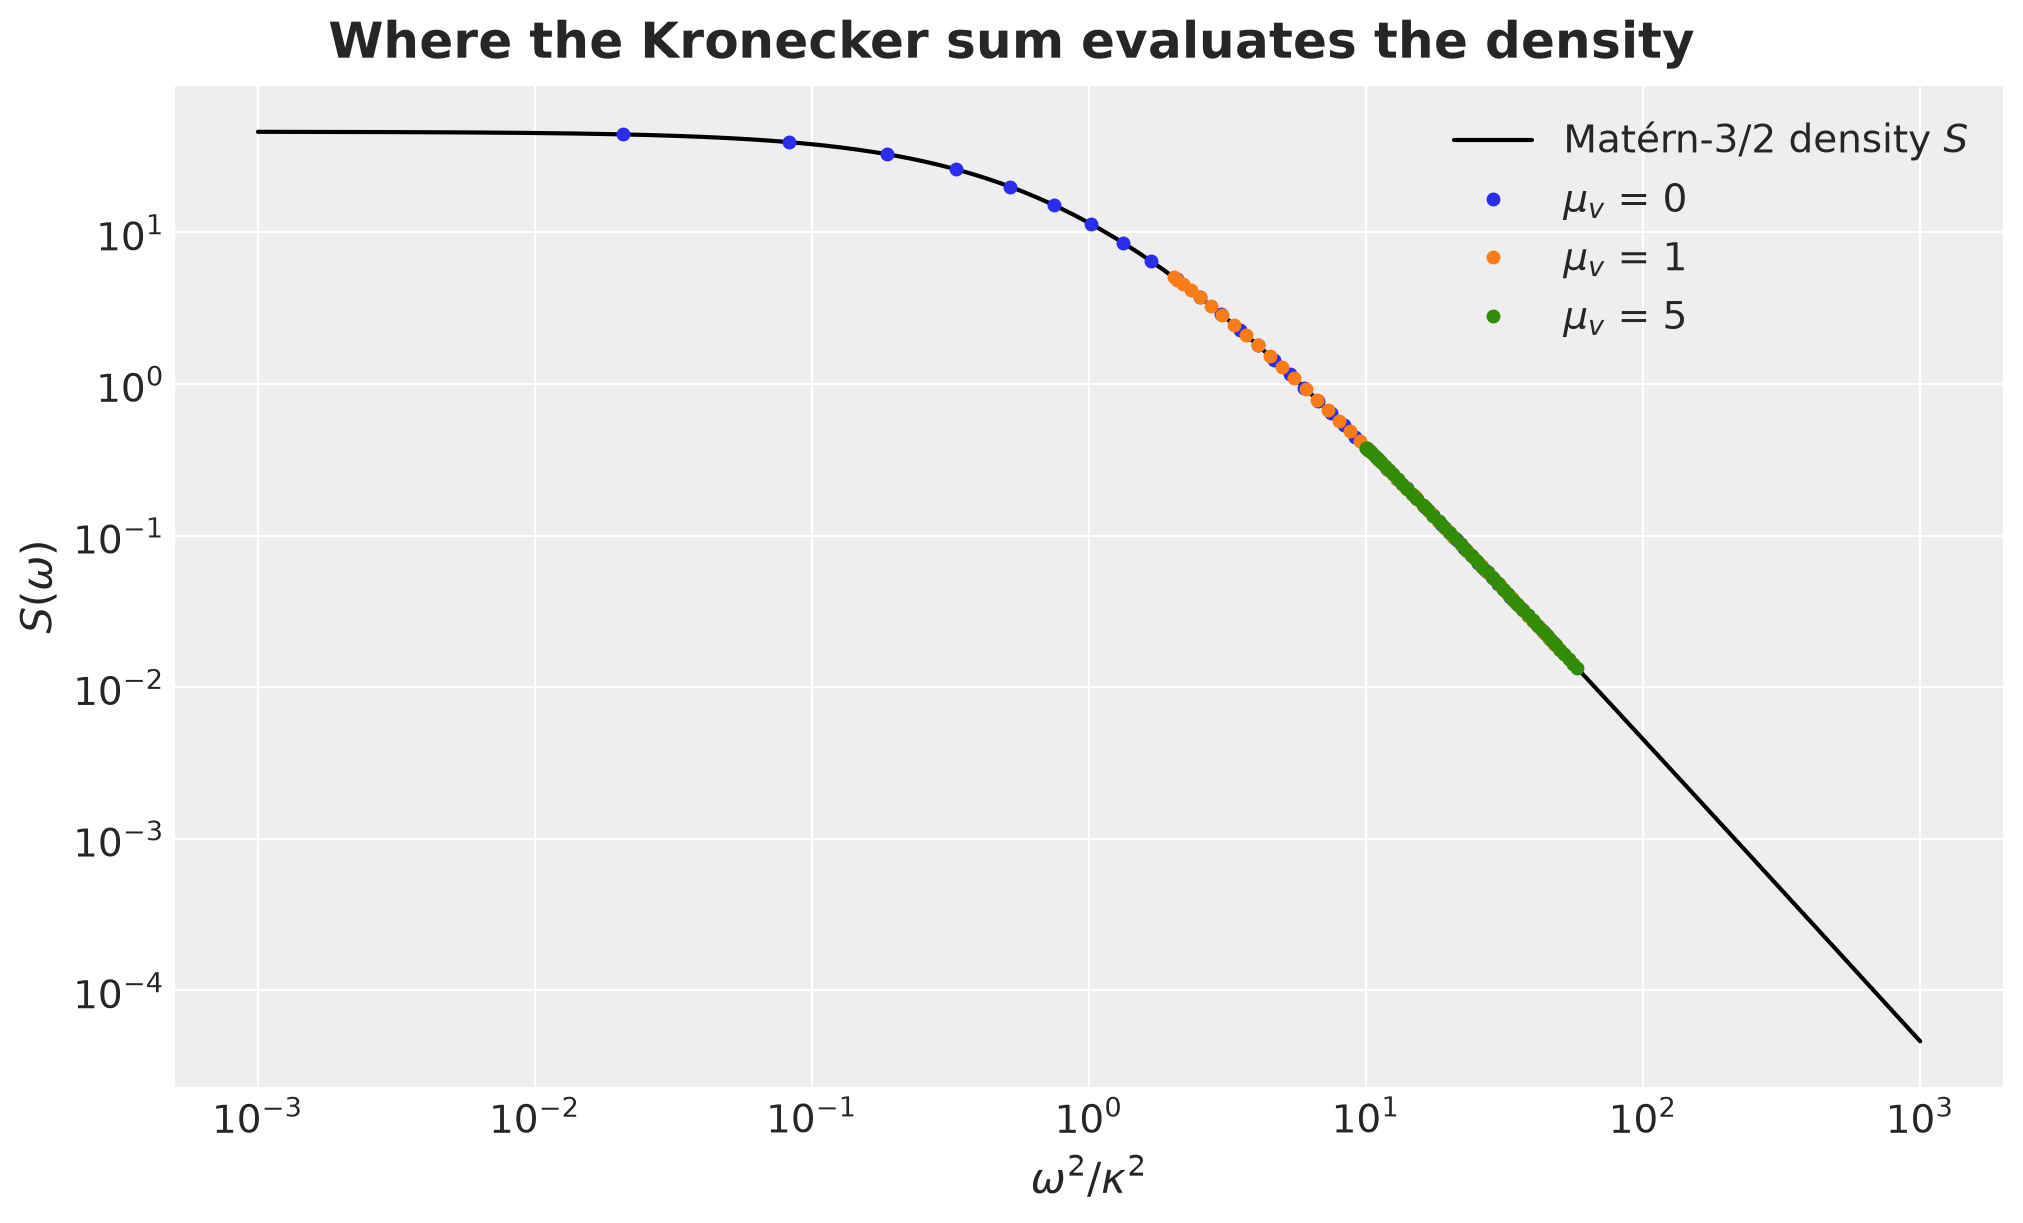

In [46]:
x_grid = jnp.logspace(-3, 3, 400)  # omega^2 / kappa^2
s_curve = spectral_density_matern(
    dim=1, nu=NU, w=jnp.sqrt(x_grid * KAPPA2_0)[:, None], alpha=1.0, length=LENGTH_0
)

fig, ax = plt.subplots()
ax.plot(
    np.asarray(x_grid),
    np.asarray(s_curve),
    color="black",
    label="Matérn-3/2 density $S$",
)
for i, mu_v in enumerate(mu_show[:3]):
    omega2 = lam + KAPPA2_0 * RHO_0 * mu_v
    s_jv = spectral_density_matern(
        dim=1, nu=NU, w=jnp.sqrt(omega2)[:, None], alpha=1.0, length=LENGTH_0
    )
    ax.plot(
        np.asarray(omega2 / KAPPA2_0),
        np.asarray(s_jv),
        "o",
        color=f"C{i}",
        markersize=4,
        label=f"$\\mu_v$ = {mu_v:.0f}",
    )
ax.set(
    xscale="log", yscale="log", xlabel="$\\omega^2 / \\kappa^2$", ylabel="$S(\\omega)$"
)
ax.legend()
fig.suptitle(
    "Where the Kronecker sum evaluates the density", fontsize=18, fontweight="bold"
);

Here is the takeaway. There is a single Matérn density, and every graph mode reads its weights off the same curve. What changes from mode to mode is only the starting point: the constant mode starts at the flat part of the curve, and a rougher mode starts $\rho \mu_v$ further to the right, on the decaying part. Two things follow.

- **Less variance.** The rougher the mode, the smaller *all* of its weights, so the mode carries less variance.
- **Shorter memory.** The rougher the mode, the smaller the contrast between its low and its high frequencies, because the curve is flatter there on the log scale. Relatively more of the mode's variance then sits at high frequencies, which is a shorter memory.
 The Kronecker sum does not add a spatial kernel to a temporal one. It changes where each graph mode sits on one temporal spectrum, and $\rho$ sets the step size.

In formulas, plugging $\omega^2 = \lambda_j + \kappa^2 \rho\, \mu_v$ into $(\kappa^2 + \omega^2)^{-(\nu + 1/2)}$ and pulling out $\kappa^2$ gives the spectral weights

$$
W_{j v} = C' \left(1 + \frac{\lambda_j}{\kappa^2} + \rho\, \mu_v\right)^{-(\nu + 1/2)} ,
$$

where the constant $C'$ is fixed by the normalization below.

#### Interpretation

Fix a graph mode $v$ and look at the weights as a function of $j$ only. Since $\lambda_j / \kappa^2 + (1 + \rho \mu_v) = (1 + \rho \mu_v) \left(1 + \lambda_j / (\kappa^2 (1 + \rho \mu_v))\right)$, they are the weights of a one-dimensional Matérn-$\nu$ process in time with inverse squared lengthscale $\kappa^2 (1 + \rho \mu_v)$, times a mode-specific constant. In other words, graph mode $v$ is a temporal Matérn-$\nu$ HSGP with its own lengthscale and amplitude,

$$
\ell_v = \frac{\ell}{\sqrt{1 + \rho\, \mu_v}}, \qquad \alpha_v = (1 + \rho\, \mu_v)^{-\nu} ,
$$

so that $W_{jv} \propto S(\sqrt{\lambda_j};\, \alpha_v, \ell_v)$ with $S$ the one-dimensional Matérn density. We check this numerically. The weights from the sum formula and the weights of a Matérn density with parameters $(\alpha_v, \ell_v)$ coincide. This is also how we compute the weights in code below: we reuse the Matérn spectral density of `numpyro.contrib.hsgp` and only supply the pair $(\alpha_v, \ell_v)$ for every graph mode.

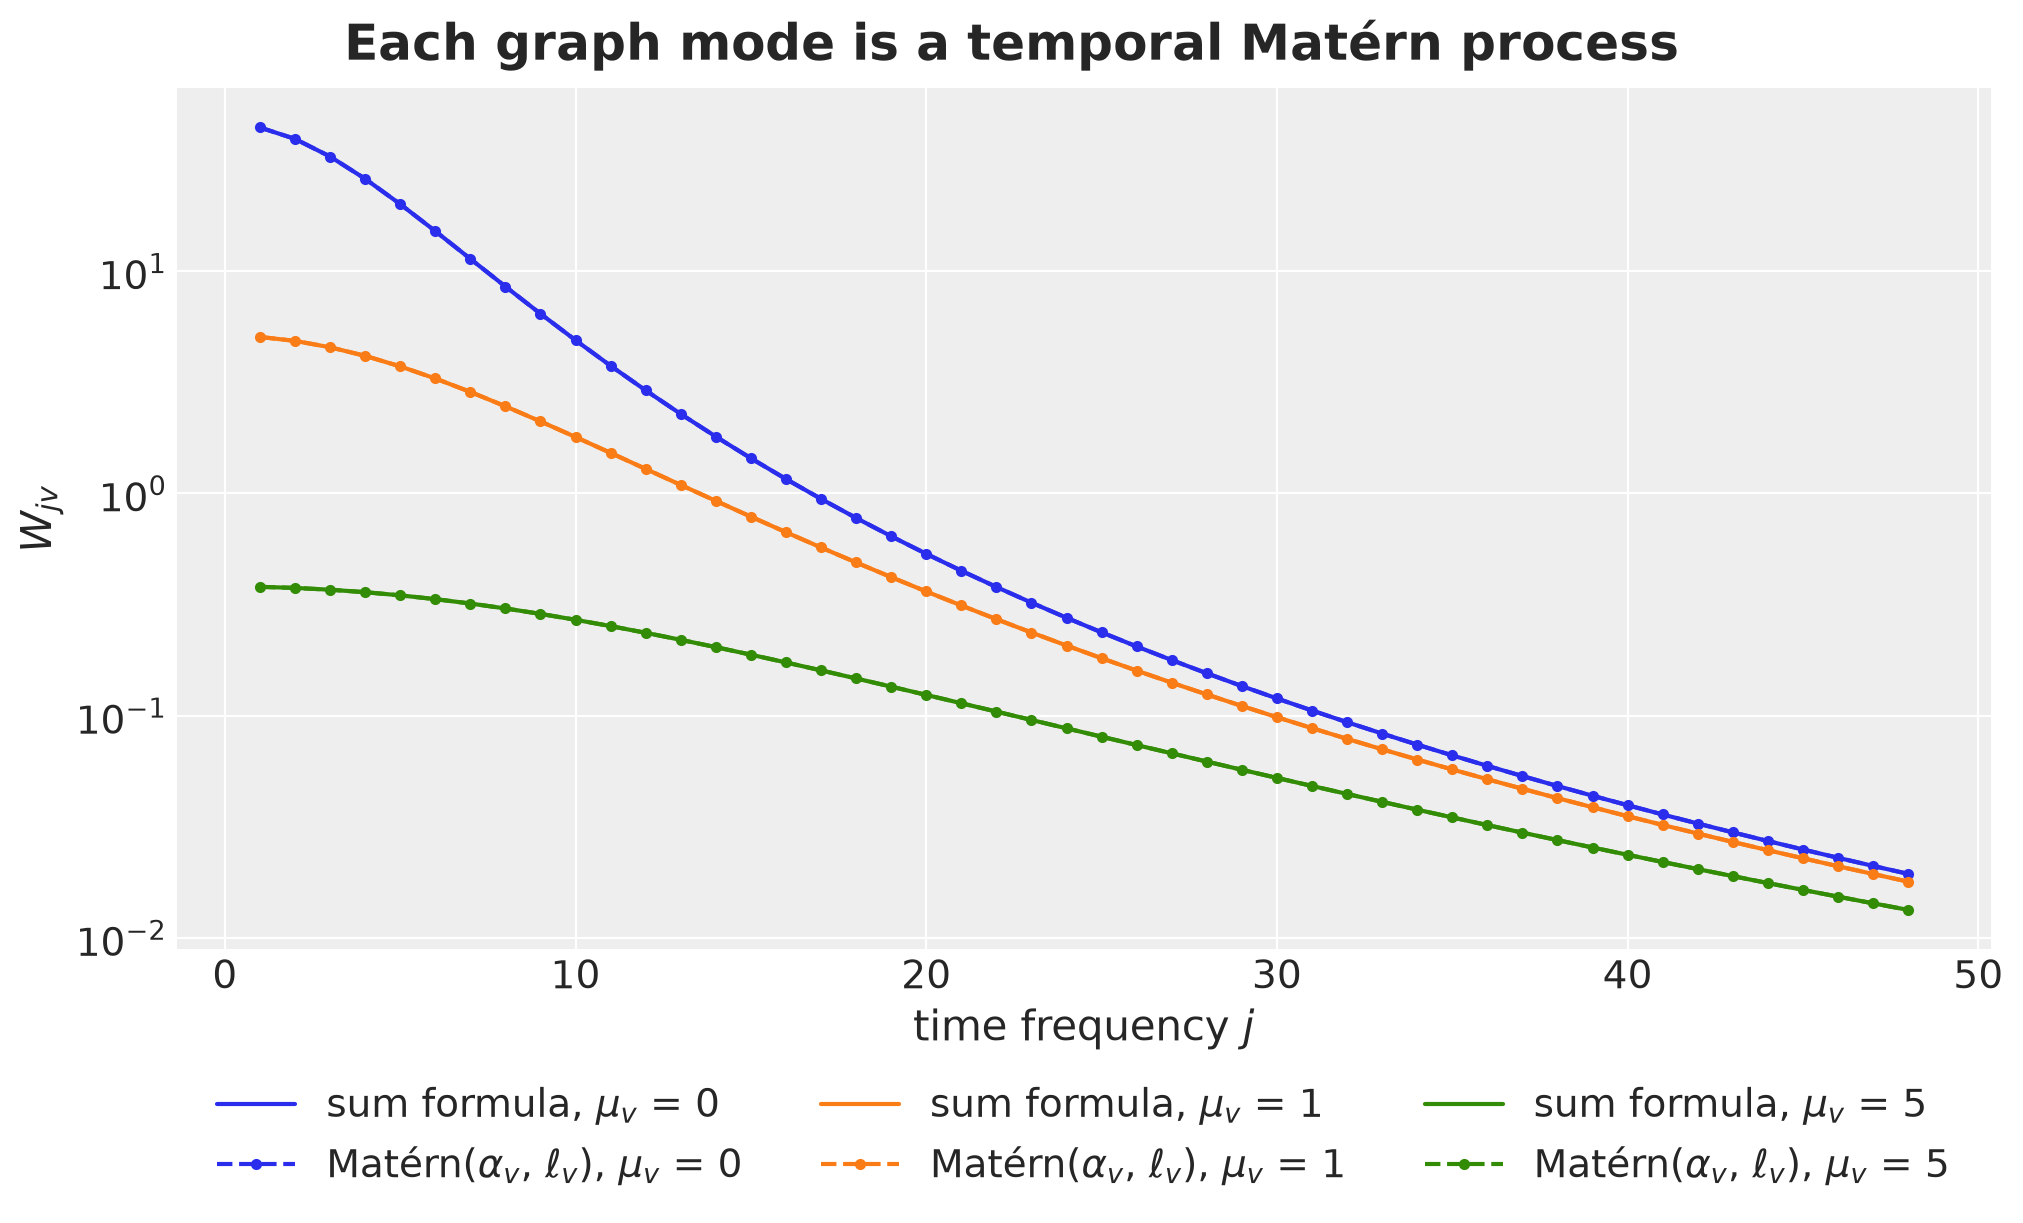

In [47]:
fig, ax = plt.subplots()
for i, mu_v in enumerate(mu_show[:3]):
    omega2 = lam + KAPPA2_0 * RHO_0 * mu_v
    w_sum = spectral_density_matern(
        dim=1, nu=NU, w=jnp.sqrt(omega2)[:, None], alpha=1.0, length=LENGTH_0
    )
    g = 1.0 + RHO_0 * mu_v
    w_mode = diag_spectral_density_matern(
        nu=NU,
        alpha=g ** (-NU),
        length=LENGTH_0 / jnp.sqrt(g),
        ell=ell_box,
        m=M_BASIS,
        dim=1,
    )
    ax.plot(
        j_grid,
        np.asarray(w_sum),
        color=f"C{i}",
        label=f"sum formula, $\\mu_v$ = {mu_v:.0f}",
    )
    ax.plot(
        j_grid,
        np.asarray(w_mode),
        color=f"C{i}",
        linestyle="--",
        marker="o",
        markersize=3,
        label=f"Matérn($\\alpha_v$, $\\ell_v$), $\\mu_v$ = {mu_v:.0f}",
    )
ax.set(yscale="log", xlabel="time frequency $j$", ylabel="$W_{jv}$")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
fig.suptitle(
    "Each graph mode is a temporal Matérn process", fontsize=18, fontweight="bold"
);

The two computations agree, which is good! Three consequences follow from the formulas for $\ell_v$ and $\alpha_v$, and we will see all three in a plot below:

- $v = 0$ is the shared national trend, with the longest lengthscale $\ell$ and the largest amplitude.
- Rough spatial patterns (large $\mu_v$) have shorter memory and smaller amplitude.
- $\rho$ controls how fast both decay with $\mu_v$.

The next plot shows the two curves against $\mu_v$ for three values of $\rho$. For small $\rho$ the curves are flat: all modes have the same lengthscale and amplitude, which is the same as independent regions with shared hyperparameters. For large $\rho$ every mode except $\mu_v = 0$ collapses: only the national mode survives, which is complete pooling.

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), layout="constrained")
for i, rho in enumerate([0.1, 1.0, 10.0]):
    g = 1.0 + rho * mu_grid
    axes[0].plot(
        np.asarray(mu_grid),
        np.asarray(g ** (-0.5)),
        color=f"C{i}",
        label=f"$\\rho$ = {rho}",
    )
    axes[1].plot(
        np.asarray(mu_grid),
        np.asarray(g ** (-NU)),
        color=f"C{i}",
        label=f"$\\rho$ = {rho}",
    )
axes[0].set(
    xlabel="graph eigenvalue $\\mu_v$",
    ylabel="$\\ell_v / \\ell$",
    title="Effective lengthscale",
)
axes[1].set(xlabel="graph eigenvalue $\\mu_v$", ylabel="$\\alpha_v$", title="Amplitude")
axes[0].legend()
fig.suptitle("What the pooling strength $\\rho$ does", fontsize=18, fontweight="bold");

So $\rho$ is a single *spatial pooling strength*, and the graph decides which deviations are suppressed first.

What does this mean for a forecast? A forecast extrapolates the fitted modes, and a mode with lengthscale $\ell_v$ carries information for roughly $\ell_v$ weeks past the last observation.

Rough modes have the shortest $\ell_v$, so they are the first to decay toward their prior mean of zero. After a few weeks only the smooth modes are left, and after a few months only the national mode.

The visible effect is that a state's forecast starts near its own recent level and then moves toward the national forecast as the horizon grows, with the ragged part of its deviation disappearing first. We measure this directly in the section on the spatial structure of the forecasts.

### Three Kernels with the Same Hyperparameters

Why three kernels? Suppose the Kronecker-sum model forecasts better than a model with one independent HSGP per region. Two different things could explain the gain: that the regions share information at all, or that they share it in the non-separable way the sum prescribes. To tell these apart we need a ladder of three kernels, each adding one ingredient:

1. **Independent.** One temporal HSGP per region, no graph. This is the null: whatever it achieves comes from the time dimension alone.
2. **Separable.** The product of a temporal Matérn kernel and a graph Matérn kernel. This is the standard way to combine a time kernel with a space kernel (an intrinsic coregionalization model with a fixed coregionalization matrix), and it is the Kronecker *product* of the previous section, the structure of the PyMC [HSGP Kronecker example](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/HSGP-Advanced.html#example-2-an-hsgp-that-exploits-kronecker-structure). It shares information across regions, but every graph mode has the *same* temporal lengthscale.
3. **Kronecker sum.** The construction above. It shares information *and* gives rough spatial patterns a shorter memory.

All three use the same hyperparameters $(\sigma_f, \ell, \rho)$ and the same basis, and differ only in how the two spectra are combined. So a difference between $2$ and $3$ is attributable to non-separability alone, and a difference between $1$ and $2$ to spatial sharing alone. In the language of the interpretation above, every kernel is a collection of $R$ temporal Matérn HSGPs, one per graph mode, and the graph eigenvalue $\mu_v$ sets the amplitude and (for the Kronecker sum only) the lengthscale of mode $v$:

| mode | $W_{jv}$ | $\ell_v$ | $\alpha_v$ | kernel |
|---|---|---|---|---|
| `kron_sum` | $(1 + \lambda_j / \kappa^2 + \rho \mu_v)^{-(\nu + 1/2)}$ | $\ell / \sqrt{1 + \rho \mu_v}$ | $(1 + \rho \mu_v)^{-\nu}$ | non-separable |
| `separable` | $(1 + \lambda_j / \kappa^2)^{-(\nu + 1/2)}\, (1 + \rho \mu_v)^{-(\nu + 1/2)}$ | $\ell$ | $(1 + \rho \mu_v)^{-(\nu + 1/2)}$ | Matérn(time) $\otimes$ graph-Matérn |
| `independent` | $(1 + \lambda_j / \kappa^2)^{-(\nu + 1/2)}$ with $U = I$ | $\ell$ | $1$ | one HSGP per region |

The last two columns are the table in code. `mode_hyperparameters` is the only place where the three kernels differ, and `unnormalized_weights` feeds its output to the Matérn density of `numpyro.contrib.hsgp`, one graph mode at a time.

In [ ]:
Mode = Literal["kron_sum", "separable", "independent"]


def mode_hyperparameters(
    mu: Float[Array, " R"],
    *,
    mode: Mode,
    nu: float,
    length: Float[Array, ""],
    rho: Float[Array, ""],
) -> tuple[Float[Array, " R"], Float[Array, " R"]]:
    "Amplitude alpha_v and temporal lengthscale ell_v of every graph mode."
    g = 1.0 + rho * mu
    if mode == "kron_sum":
        return g ** (-nu), length / jnp.sqrt(g)
    if mode == "separable":
        return g ** (-(nu + 0.5)), jnp.full_like(mu, length)
    if mode == "independent":
        return jnp.ones_like(mu), jnp.full_like(mu, length)
    raise ValueError(f"unknown mode {mode!r}")


def unnormalized_weights(
    mu: Float[Array, " R"],
    *,
    mode: Mode,
    nu: float,
    length: Float[Array, ""],
    rho: Float[Array, ""],
    ell_box: float,
    m: int,
) -> Float[Array, "m R"]:
    "Matérn spectral weights W[j, v] of one of the three kernels, up to a constant."
    alpha_v, length_v = mode_hyperparameters(
        mu, mode=mode, nu=nu, length=length, rho=rho
    )

    def density(alpha, length):
        return diag_spectral_density_matern(
            nu=nu, alpha=alpha, length=length, ell=ell_box, m=m, dim=1
        )

    return jax.vmap(density)(alpha_v, length_v).T  # (m, R)

We plot the weights of the three kernels as curves, one per graph mode. One caveat on the second index: for the independent kernel there is no rotation ($U = I$), so the columns of $W$ are the regions themselves, not graph modes. For the other two kernels they are graph modes. In the independent kernel all curves coincide. In the separable kernel all curves have the same shape and only their level changes. In the Kronecker sum the curves of rough modes are lower *and* flatter, which is a shorter lengthscale.

In [ ]:
MODES: list[Mode] = ["independent", "separable", "kron_sum"]

fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(16, 5), sharey=True, layout="constrained"
)
for ax, mode in zip(axes, MODES, strict=True):
    w_show = unnormalized_weights(
        mu_show,
        mode=mode,
        nu=NU,
        length=LENGTH_0,
        rho=RHO_0,
        ell_box=ell_box,
        m=M_BASIS,
    )
    for i, mu_v in enumerate(mu_show):
        ax.plot(
            j_grid,
            np.asarray(w_show[:, i]),
            color=f"C{i}",
            label=f"$\\mu_v$ = {mu_v:.0f}",
        )
    ax.set(title=mode, xlabel="time frequency $j$", yscale="log")
axes[0].set(ylabel="$W_{jv}$")
axes[2].legend(loc="lower left")
fig.suptitle("The three kernels as weight curves", fontsize=18, fontweight="bold");

The same contrast as a function of the graph eigenvalue: the amplitude $\alpha_v$ decays with $\mu_v$ for both pooled kernels (slightly faster for the separable one), but only the Kronecker sum shortens the lengthscale.

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), layout="constrained")
for i, mode in enumerate(MODES):
    alpha_v, length_v = mode_hyperparameters(
        mu_grid, mode=mode, nu=NU, length=LENGTH_0, rho=RHO_0
    )
    axes[0].plot(np.asarray(mu_grid), np.asarray(alpha_v), color=f"C{i}", label=mode)
    axes[1].plot(
        np.asarray(mu_grid), np.asarray(length_v / LENGTH_0), color=f"C{i}", label=mode
    )
axes[0].set(
    xlabel="graph eigenvalue $\\mu_v$",
    ylabel="$\\alpha_v$",
    title="Amplitude per graph mode",
)
axes[1].set(
    xlabel="graph eigenvalue $\\mu_v$",
    ylabel="$\\ell_v / \\ell$",
    title="Lengthscale per graph mode",
)
axes[0].legend()
fig.suptitle(
    "Amplitude and lengthscale of the three kernels", fontsize=18, fontweight="bold"
);

Note that a product of kernels has a Kronecker *product* covariance, and its spectrum is the product of the two spectra. In the Kronecker sum the spectra are combined *inside* the density. This is the whole difference between the separable kernel and the sum.

One honest remark about the exponent of the separable graph factor. We use $-(\nu + 1/2)$ for it, the same exponent as the time factor, so that both factors agree at $\mu_v = 0$ and the only difference between the three kernels is the combination rule. The canonical graph Matérn of [Borovitskiy et al. (2021)](https://proceedings.mlr.press/v130/borovitskiy21a.html) uses $(2\nu_G / \kappa_G^2 + \mu_v)^{-\nu_G}$ instead, with no $+1/2$, because that term comes from the dimension of the input space and a graph has none. Our choice is a modeling convenience for the comparison, not the canonical graph kernel.

### Normalization

We fix the overall scale by trace normalization. The prior variance of $f$ at $(t, r)$ is $\sum_{jv} W_{jv}\, \phi_j(t)^2\, u_v(r)^2$. Averaging over the regions uses $\sum_r u_v(r)^2 = 1$, and averaging over the box uses

$$
\frac{1}{2L} \int_{-L}^{L} \phi_j(t)^2\, dt = \frac{1}{2L} \int_{-L}^{L} \frac{1}{L} \sin^2\!\left(\omega_j (t + L)\right) dt = \frac{1}{2L} ,
$$

because a squared sine averages to one half over whole periods. So the average prior variance over time and regions is $\sum_{j v} W_{j v} / (2 L R)$, and we choose $C'$ so that this average equals $\sigma_f^2$.

Note that $C'$ depends on $\rho$, $\ell$, $\nu$, $m$ and the graph. One consequence is worth keeping in mind. The limit $\rho \to \infty$ does not shrink the process to zero, it *redistributes* the variance. Whatever the rough modes lose, the national mode gains, so the limit is complete pooling at the full variance $\sigma_f^2$.

A second consequence is that $\sigma_f$ and $\rho$ are only weakly separable in the posterior, since both act on the overall scale. Let's look at both statements on the German graph, with the share of the total variance that each mode carries on the left and the average variance on the right.

In [ ]:
def average_variance(w: Float[Array, "m R"], ell_box: float) -> float:
    "Average prior variance over the box and the graph modes, sum(W) / (2 L R)."
    return float(w.sum() / (2.0 * ell_box * w.shape[1]))


def kron_sum_weights(rho: float) -> Float[Array, "m R"]:
    "Unnormalized kron_sum weights on the stand-in grid of graph eigenvalues."
    return unnormalized_weights(
        mu_coarse,
        mode="kron_sum",
        nu=NU,
        length=LENGTH_0,
        rho=rho,
        ell_box=ell_box,
        m=M_BASIS,
    )


rho_curve = np.logspace(-2, 2, 60)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), layout="constrained")
for i, rho in enumerate([0.1, 1.0, 2.0, 10.0]):
    w_rho = kron_sum_weights(rho)
    axes[0].plot(
        np.arange(mu_coarse.shape[0]),
        np.asarray(w_rho.sum(axis=0) / w_rho.sum()),
        color=f"C{i}",
        marker="o",
        markersize=4,
        label=f"$\\rho$ = {rho}",
    )
raw = np.array([average_variance(kron_sum_weights(rho), ell_box) for rho in rho_curve])
axes[1].plot(rho_curve, raw / raw[0], color="C0", label="before normalization")
axes[1].plot(
    rho_curve, np.ones_like(rho_curve), color="C1", label="after normalization"
)
axes[0].set(
    xlabel="graph mode $v$",
    ylabel="share of the total variance",
    yscale="log",
    xticks=np.arange(0, 16, 3),
    title="Where the variance goes",
)
axes[0].legend()
axes[1].set(
    xlabel="pooling strength $\\rho$",
    ylabel="average variance (relative)",
    xscale="log",
    title="What the normalization fixes",
)
axes[1].legend()
fig.suptitle(
    "Trace normalization redistributes the variance", fontsize=18, fontweight="bold"
);

On the left, as $\rho$ grows the rough modes lose their share of the variance and the constant mode absorbs it, until at $\rho = 10$ the constant mode carries about $90\%$ of it. That is complete pooling.

On the right we see why the normalization is needed. Without it the average variance would fall by a factor of about $15$ over this range of $\rho$, so $\rho$ would silently act as a shrinkage parameter. After the normalization the average variance is held at $\sigma_f^2$, and $\rho$ only decides how the variance is split between the modes.

### Node Standardization

Graph Matérn kernels have a marginal variance that depends on the node. On the German adjacency graph the prior variance at Bremen (degree $1$) is about three times the one at Lower Saxony (degree $9$), and the largest and smallest prior variances of the whole panel (Saarland and Lower Saxony) differ by a factor of about four, so the widest and the narrowest band differ by a factor of about two.

This is an accident of the adjacency, not a modeling statement. Let $v_r = \sum_{j v} W_{j v}\, u_v(r)^2 / (2L)$ be the prior variance at region $r$. We rescale $f(\cdot, r)$ by $s_r = \sigma_f / \sqrt{v_r}$.

With $D = \operatorname{diag}(s)$ the kernel becomes $D K D$, which is still positive semidefinite and still two matrix multiplications, because we simply replace $U$ by $D U$. Every region then has prior variance $\sigma_f^2$ and the graph only shapes the *correlations*.

That last claim is an identity rather than a hope. For any positive diagonal $D$ we have $\text{corr}(D K D) = \text{corr}(K)$, because the factors $d_r$ cancel between the covariance and the two standard deviations. The standardization changes every variance and no correlation. We come back to it with the real graph in the section on building blocks.

### Basis Size

The number of time basis functions $m$ must resolve the *shortest* effective lengthscale, $\ell_{\min} = \ell / \sqrt{1 + \rho\, \mu_{\max}}$, not $\ell$. The rule of thumb of [Riutort-Mayol et al. (2023)](https://link.springer.com/article/10.1007/s11222-022-10167-2), equation 20, for a Matérn-$3/2$ kernel is $m \ge 3.42\, c\, S / \ell$ with $S = D / 2$ the half-range of the data, and it must be applied with $\ell_{\min}$: $m \gtrsim 3.42\, c\, (D / 2) / \ell_{\min}$. The same paper asks for $c \ge 4.1\, \ell / S$, which $c = 1.5$ satisfies for every lengthscale in this notebook. If $m$ is too small the truncation silently over-smooths the rough spatial modes, which acts like a larger $\rho$. The next plot shows both faces of the problem. On the left we repeat the kernel comparison of the interval section for three effective lengthscales at $m = 48$: at $\ell_v = 4$ weeks the approximation misses the peak. On the right we plot the variance the basis can represent, $\sum_j S(\sqrt{\lambda_j}) / (2L)$, as a function of the effective lengthscale and for three basis sizes. We divide it by the same quantity at $m = 1000$, so that the curves isolate the *truncation*: a long lengthscale also loses variance because the box is short relative to $\ell$ (about $9\%$ at $\ell = 20$), but that boundary effect is controlled by $c$, not by $m$, and dividing it out keeps the two effects apart. With $\ell = 20$ and $\rho = 2$ the roughest mode of a graph with $\mu_{\max} = 10$ has $\ell_{\min} \approx 4.4$ weeks, the rule asks for about $100$ basis functions, and $m = 48$ captures about $92\%$ of the variance of that mode. The rule is strict (it targets a $1\%$ error on the whole kernel), and this ratio is the pragmatic check we use. We check the rule against the posterior later in the notebook.

In [ ]:
ell_v_grid = np.linspace(2.0, 40.0, 100)
ell_min_0 = LENGTH_0 / np.sqrt(1.0 + RHO_0 * float(mu_grid.max()))

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), layout="constrained")
for i, length_v in enumerate([20.0, 8.0, 4.0]):
    s_j = diag_spectral_density_matern(
        nu=NU, alpha=1.0, length=length_v, ell=ell_box, m=M_BASIS, dim=1
    )
    k_hsgp = (phi_full * s_j) @ phi_full[t_ref]
    k_exact = matern32_kernel(t_grid - t_grid[t_ref], length_v)
    axes[0].plot(
        np.asarray(t_grid),
        np.asarray(k_exact),
        color=f"C{i}",
        label=f"exact, $\\ell_v$ = {length_v:.0f}",
    )
    axes[0].plot(
        np.asarray(t_grid),
        np.asarray(k_hsgp),
        color=f"C{i}",
        linestyle="--",
        label=f"HSGP, $\\ell_v$ = {length_v:.0f}",
    )
axes[0].set(
    xlabel="week $t$",
    ylabel="$k(t, t')$",
    xlim=(t_ref - 30, t_ref + 30),
    title=f"Kernel approximation at m = {M_BASIS}",
)
axes[0].legend(fontsize=9)


def represented_variance(length_v: float, m: int) -> float:
    "Prior variance the basis can represent, sum_j S(sqrt(lambda_j)) / (2 L)."
    s_j = diag_spectral_density_matern(
        nu=NU, alpha=1.0, length=length_v, ell=ell_box, m=m, dim=1
    )
    return float(s_j.sum() / (2.0 * ell_box))


reference = np.array([represented_variance(lv, 1_000) for lv in ell_v_grid])
for i, m in enumerate([24, 48, 96]):
    captured = np.array([represented_variance(lv, m) for lv in ell_v_grid])
    axes[1].plot(ell_v_grid, captured / reference, color=f"C{i}", label=f"m = {m}")
axes[1].axvline(
    x=LENGTH_0, color="black", linestyle="--", label="$\\ell$ (national mode)"
)
axes[1].axvline(
    x=ell_min_0, color="black", linestyle=":", label="$\\ell_{\\min}$ (roughest mode)"
)
axes[1].set(
    xlabel="effective lengthscale $\\ell_v$ (weeks)",
    ylabel="captured / untruncated variance",
    title="Variance captured by the basis",
)
axes[1].legend()
fig.suptitle("Truncation hits the rough modes first", fontsize=18, fontweight="bold");

Both panels point the same way. At $\ell_v = 4$ weeks the approximation at $m = 48$ misses the peak of the kernel, and the right panel puts a number on it: the basis captures about $92\%$ of the variance of that mode, against essentially all of it for the national mode.

## The Graph

We use the adjacency graph of the $16$ German states (Bundesländer). Two states are adjacent if their polygons share a border. We read the state polygons from a GeoJSON file ([isellsoap/deutschlandGeoJSON](https://github.com/isellsoap/deutschlandGeoJSON), low-resolution version, derived from data of the Federal Agency for Cartography and Geodesy under the [dl-de/by-2-0](https://www.govdata.de/dl-de/by-2-0) license) and derive the adjacency from the geometry, so nothing is typed by hand. Two polygons are adjacent if they intersect, which for a clean set of state polygons means that they share a border segment. Three small functions do the work: `load_states` reads the file, `adjacency_from_geometries` builds the matrix $A$, and `edges_from_adjacency` turns it into the edge list for the plots. The polygons come back from `geopandas` as numpy, and we move to JAX right after the intersection test, so that everything downstream of the file is JAX-native.

In [ ]:
def load_states(path: str) -> gpd.GeoDataFrame:
    "State polygons indexed by the two-letter state code."
    gdf = gpd.read_file(path)
    gdf["code"] = gdf["id"].str.replace("DE-", "")
    return gdf.set_index("code")


def adjacency_from_geometries(geometries: gpd.GeoSeries) -> Float[Array, "R R"]:
    "Symmetric 0/1 adjacency matrix: two polygons are adjacent if they intersect."
    touches = jnp.asarray(
        np.stack([geometries.intersects(g).to_numpy() for g in geometries]),
        dtype=jnp.float32,
    )
    return touches * (1.0 - jnp.eye(touches.shape[0]))


def edges_from_adjacency(
    adjacency: Float[Array, "R R"], labels: list[str]
) -> list[tuple[str, str]]:
    "Edge list (i < j) of a symmetric adjacency matrix."
    rows, cols = jnp.nonzero(jnp.triu(adjacency))
    return [(labels[int(i)], labels[int(j)]) for i, j in zip(rows, cols, strict=True)]


states_gdf = load_states("../data/germany_states.geojson")
STATES = list(states_gdf.index)
R = len(STATES)
state_index = {s: i for i, s in enumerate(STATES)}

adjacency = adjacency_from_geometries(states_gdf.geometry)
EDGES = edges_from_adjacency(adjacency, STATES)
positions = {
    s: (p.x, p.y) for s, p in states_gdf.geometry.representative_point().items()
}
degree = adjacency.sum(axis=1)

print(f"{R} states, {len(EDGES)} borders")

pl.DataFrame(
    {
        "state": STATES,
        "name": states_gdf["name"].to_list(),
        "degree": np.asarray(degree),
    }
)

The degrees are very uneven. Lower Saxony (`NI`) touches nine other states, while Berlin (`BE`), Bremen (`HB`) and Saarland (`SL`) touch only one. Let's draw the network on the map, with the node color showing the degree.

In [ ]:
graph = nx.Graph(EDGES)

fig, ax = plt.subplots(figsize=(9, 10))
states_gdf.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=1)
nodes = nx.draw_networkx_nodes(
    graph,
    pos=positions,
    nodelist=STATES,
    node_color=np.asarray(degree),
    cmap="viridis",
    node_size=700,
    ax=ax,
)
nx.draw_networkx_edges(graph, pos=positions, edge_color="C1", width=1.5, ax=ax)
nx.draw_networkx_labels(
    graph, pos=positions, font_color="white", font_weight="bold", ax=ax
)
fig.colorbar(nodes, ax=ax, label="degree", shrink=0.6)
ax.set(xlabel="longitude", ylabel="latitude")
fig.suptitle("Adjacency graph of the German states", fontsize=18, fontweight="bold");

We compute the Laplacian and its eigendecomposition once, outside any model, in JAX. We clip tiny negative eigenvalues coming from round-off and set $\mu_0 = 0$ exactly.

In [ ]:
def graph_laplacian(adjacency: Float[Array, "R R"]) -> Float[Array, "R R"]:
    "Combinatorial graph Laplacian L = D - A of a symmetric adjacency matrix."
    if not jnp.allclose(adjacency, adjacency.T):
        raise ValueError("adjacency must be symmetric")
    return jnp.diag(adjacency.sum(axis=1)) - adjacency


def laplacian_eigenpairs(
    adjacency: Float[Array, "R R"],
) -> tuple[Float[Array, " R"], Float[Array, "R R"]]:
    "Ascending eigenvalues mu (mu[0] = 0) and eigenvectors U (columns)."
    mu, U = jnp.linalg.eigh(graph_laplacian(adjacency))
    mu = jnp.clip(mu, 0.0, None).at[0].set(0.0)
    return mu, U


mu, U = laplacian_eigenpairs(adjacency)

n_zero = int((mu < 1e-8).sum())
print(f"zero eigenvalues: {n_zero} (1 means the graph is connected)")
print(f"largest eigenvalue: {float(mu[-1]):.2f}")
print(f"largest degree + 1: {float(degree.max()) + 1:.0f}")

fig, ax = plt.subplots()
ax.stem(np.arange(R), np.asarray(mu), basefmt=" ")
ax.set(xlabel="graph mode $v$", ylabel="$\\mu_v$", xticks=np.arange(R))
fig.suptitle("Eigenvalues of the graph Laplacian", fontsize=18, fontweight="bold");

The graph is connected, so the eigenvalue zero appears once and mode $0$ is the national average mode.

**Remark.** The largest eigenvalue is close to $d_{\max} + 1$, with $d_{\max}$ the largest degree. The roughest mode is therefore the *local* pattern around the hub, which is why the hub degree, and not the size of the graph, decides how rough this graph can get.

Let's check the roughness reading of the eigenvalues. We evaluate the quadratic form $x^\top L_G x$ for the second eigenvector (the Fiedler vector), for the roughest eigenvector, and for a random $\pm 1$ pattern scaled to unit length.

In [ ]:
def roughness(x: Float[Array, " R"]) -> float:
    "Quadratic form x^T L_G x: the sum of squared differences across the edges."
    return float(x @ graph_laplacian(adjacency) @ x)


checkerboard = random.choice(random.PRNGKey(1), jnp.array([-1.0, 1.0]), shape=(R,))
checkerboard = checkerboard / jnp.linalg.norm(checkerboard)

pl.DataFrame(
    {
        "pattern": [
            "u_1 (Fiedler vector)",
            "u_15 (roughest eigenvector)",
            "random +/-1 pattern",
        ],
        "roughness x^T L x": [
            roughness(U[:, 1]),
            roughness(U[:, 15]),
            roughness(checkerboard),
        ],
        "eigenvalue mu_v": [float(mu[1]), float(mu[15]), None],
    }
)

The roughness of an eigenvector is its eigenvalue, as it should be. The roughest mode is not a global checkerboard. As the eigenvector maps below show, it is a *local* pattern concentrated on the hub and its neighbors, which is the roughest thing this graph can express. A random sign pattern spread over all the states has intermediate roughness.

The maps below are the German version of the path-graph modes we plotted in the theory section. The first eigenvector is constant. The second one (the Fiedler vector) splits the graph into two smooth halves, south-west against north-east. Higher modes oscillate faster over the graph.

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(16, 9), layout="constrained")
vmax = float(jnp.abs(U).max())
for v, ax in enumerate(axes.flat):
    states_gdf.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)
    nodes = nx.draw_networkx_nodes(
        graph,
        pos=positions,
        nodelist=STATES,
        node_color=np.asarray(U[:, v]),
        cmap="coolwarm",
        vmin=-vmax,
        vmax=vmax,
        node_size=250,
        ax=ax,
    )
    nx.draw_networkx_edges(graph, pos=positions, edge_color="gray", ax=ax)
    ax.set(title=f"mode {v}, $\\mu_{{{v}}}$ = {mu[v]:.2f}", xticks=[], yticks=[])
fig.colorbar(nodes, ax=axes, label="$u_v(r)$", shrink=0.6)
fig.suptitle("Graph Laplacian eigenvectors", fontsize=18, fontweight="bold");

## Building Blocks

We now write the construction as small functions. `numpyro.contrib.hsgp` already provides the sine basis and its eigenvalues (`eigenfunctions`, `sqrt_eigenvalues`), the Matérn spectral density evaluated at the eigenvalues (`diag_spectral_density_matern`), and the linear model $\Phi (\sqrt{W} \circ B)$ with its coefficients (`linear_approximation`). We reuse all of them. What we add is the graph side: the map from $\mu_v$ to $(\alpha_v, \ell_v)$ (`mode_hyperparameters` and `unnormalized_weights`, defined in the theory section above), the trace normalization, the node standardization, and the rotation back to the regions.

### Time Side

`time_box` builds the centered grid and the half-width $L = c\,(D - 1) / 2$. `time_basis` returns the sine basis $\Phi$ and the eigenvalues $\lambda_j$ from `numpyro.contrib.hsgp`. Both depend only on the duration and on $m$, not on any hyperparameter.

In [ ]:
def time_box(
    duration: int, c: float = C_BOX
) -> tuple[Float[Array, " duration"], float]:
    "Centered time grid and the box half-width c * (duration - 1) / 2."
    t = jnp.arange(duration, dtype=jnp.float32)
    half = (duration - 1) / 2.0
    return t - half, float(c * half)


def time_basis(
    t_c: Float[Array, " duration"], ell_box: float, m: int
) -> tuple[Float[Array, "duration m"], Float[Array, " m"]]:
    "HSGP sine basis Phi (duration, m) and eigenvalues lambda (m,) on the box."
    phi = eigenfunctions(t_c, ell=ell_box, m=m)
    lam = sqrt_eigenvalues(ell_box, m, dim=1)[0] ** 2
    return phi, lam

### Spectral Weights

`spectral_weights` composes `unnormalized_weights` from the theory section with the trace normalization: `trace_normalize` scales the weights so that the average prior variance over the box and the regions is $\sigma_f^2$.

In [ ]:
def trace_normalize(
    w: Float[Array, "m R"], sigma_f: Float[Array, ""], ell_box: float
) -> Float[Array, "m R"]:
    "Scale w so that mean_{t, r} Var f(t, r) = sum w / (2 ell_box R) equals sigma_f**2."
    n_regions = w.shape[1]
    return w * (sigma_f**2 * 2.0 * ell_box * n_regions / jnp.sum(w))


def spectral_weights(
    mu: Float[Array, " R"],
    *,
    mode: Mode,
    nu: float,
    length: Float[Array, ""],
    rho: Float[Array, ""],
    sigma_f: Float[Array, ""],
    ell_box: float,
    m: int,
) -> Float[Array, "m R"]:
    "Trace-normalized spectral weights W[j, v] for one of the three kernels."
    w = unnormalized_weights(
        mu, mode=mode, nu=nu, length=length, rho=rho, ell_box=ell_box, m=m
    )
    return trace_normalize(w, sigma_f, ell_box)

### Effective Lengthscales

The model has one lengthscale hyperparameter $\ell$, but the Kronecker sum turns it into $R$ different ones, $\ell_v = \ell / \sqrt{1 + \rho \mu_v}$, and only the national mode has memory $\ell$. Think of $\ell$ as the memory of the country and of $\ell_{\min} = \ell / \sqrt{1 + \rho \mu_{\max}}$ as the memory of the most local pattern the graph can express. Two things depend on the shortest lengthscale, not on $\ell$:

- **The basis size.** A sine basis with $m$ terms cannot represent wiggles faster than $\omega_m$. If $\ell_{\min}$ is shorter than what the basis resolves, the rough modes are silently smoothed. Smoothing the rough modes is what a larger $\rho$ does, so the posterior of $\rho$ gets biased upward without any warning.
- **How to read the posterior.** A posterior median of $\ell = 20$ weeks with $\rho = 2$ does not mean that regional deviations persist for $20$ weeks. It means that the national trend does. The roughest regional pattern forgets in about four weeks.

`effective_lengthscales` computes $\ell_v$ from the posterior draws. To see what it means, we draw the time series of four graph modes, $z_v(t) = \sum_j \sqrt{W_{jv}}\, \beta_j\, \phi_j(t)$, from the Kronecker-sum kernel with the *same* coefficients $\beta_j$ for every mode. The same noise, filtered with a shorter memory, gives a faster and smaller series. Each panel has its own vertical scale so that the shape is visible, and the standard deviation in the title shows the amplitude.

In [ ]:
def effective_lengthscales(
    mu: Float[Array, " R"], length: Float[Array, ""], rho: Float[Array, ""]
) -> Float[Array, " R"]:
    "Temporal lengthscale of each graph mode: ell / sqrt(1 + rho mu_v)."
    return length / jnp.sqrt(1.0 + rho * mu)


w_example = spectral_weights(
    mu,
    mode="kron_sum",
    nu=NU,
    length=LENGTH_0,
    rho=RHO_0,
    sigma_f=SIGMA_F_0,
    ell_box=ell_box,
    m=M_BASIS,
)
ell_v_example = effective_lengthscales(mu, LENGTH_0, RHO_0)

rng_key, rng_subkey = random.split(rng_key)
beta_shared = random.normal(rng_subkey, (M_BASIS,))
z_modes = phi_full @ (jnp.sqrt(w_example) * beta_shared[:, None])  # (DURATION, R)

fig, axes = plt.subplots(
    nrows=4, ncols=1, figsize=(12, 12), sharex=True, layout="constrained"
)
for ax, v in zip(axes, [0, 1, 5, 15], strict=True):
    ax.plot(np.asarray(t_grid), np.asarray(z_modes[:, v]), color="C0")
    ax.axhline(y=0.0, color="gray", linewidth=0.8)
    ell_txt = f"$\\ell_v$ = {ell_v_example[v]:.1f} weeks"
    sd_txt = f"sd = {float(z_modes[:, v].std()):.2f}"
    title = f"graph mode {v}: $\\mu_v$ = {mu[v]:.2f}, {ell_txt}, {sd_txt}"
    ax.set(title=title, ylabel="$z_v(t)$")
axes[-1].set(xlabel="week")
fig.suptitle(
    "One prior draw of four graph modes, same coefficients",
    fontsize=18,
    fontweight="bold",
);

### Node Variances

Every eigenvector is normalized over the graph, $\sum_r u_v(r)^2 = 1$, but a *single* node's share $u_v(r)^2$ differs from node to node. A hub like Lower Saxony (`NI`, degree $9$) has a mode of its own: the roughest eigenvector, with $\mu_{15} \approx 10$, is concentrated on the hub and its neighbors with alternating signs, and almost all of Lower Saxony's weight sits there. A leaf like Bremen (`HB`) barely appears in the rough modes and loads on the smooth modes instead. After weighting by $W_{jv}$, which favors the smooth modes, the total prior variance at node $r$,

$$
v_r = \frac{1}{2L} \sum_{j, v} W_{jv}\, u_v(r)^2 ,
$$

is not constant: the hub gets the smallest prior variance and the leaves get the largest. On this graph the largest and the smallest prior variance differ by a factor of about four, purely from the adjacency, so the widest and the narrowest band differ by a factor of about two. That would make the model expect Bremen to be much more volatile than Lower Saxony before seeing any data, which is not a statement we want the prior to make. The [BYM example](https://www.pymc.io/projects/examples/en/latest/spatial/nyc_bym.html) faces the same problem with the ICAR prior and handles it with a scaling factor computed from the adjacency matrix. Here the fix is the same idea. `node_variances` computes $v_r$ from the weights, and we divide it out with $s_r = \sigma_f / \sqrt{v_r}$, which gives the $D K D$ kernel of the theory section. Every region then has variance $\sigma_f^2$ and the graph is left to shape only how the regions *co-move*.

We first look at the loadings $u_v(r)^2$ and then at $v_r$ before and after the standardization.

In [ ]:
def node_variances(
    weights: Float[Array, "m R"], U: Float[Array, "R R"], ell_box: float
) -> Float[Array, " R"]:
    "Prior variance v_r = sum_{j, v} W[j, v] U[r, v]**2 / (2 ell_box) at each region."
    return jnp.einsum("jv,rv->r", weights, U**2) / (2.0 * ell_box)


fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(np.asarray(U**2), cmap="viridis", aspect="auto")
ax.set(
    xlabel="graph mode $v$",
    ylabel="region",
    xticks=np.arange(R),
    yticks=np.arange(R),
    yticklabels=STATES,
)
ax.grid(visible=False)
for label in ax.get_yticklabels():
    if label.get_text() in ["HB", "NI"]:
        label.set_fontweight("bold")
        label.set_color("C1")
fig.colorbar(im, ax=ax, label="$u_v(r)^2$")
fig.suptitle(
    "How much of each graph mode lives on each region", fontsize=18, fontweight="bold"
);

Lower Saxony (`NI`) loads almost entirely on the roughest mode $15$, which carries the smallest weights. Bremen (`HB`) loads on the smooth modes $2$ to $4$, which carry the largest weights. That is why the hub gets the smallest prior variance and the leaves get the largest.

In [ ]:
v_raw = node_variances(w_example, U, ell_box)
scale_example = SIGMA_F_0 / jnp.sqrt(v_raw)
v_std = node_variances(w_example, U * scale_example[:, None], ell_box)

fig, ax = plt.subplots()
x = np.arange(R)
ax.bar(x - 0.2, np.asarray(v_raw), width=0.4, color="C0", label="raw")
ax.bar(x + 0.2, np.asarray(v_std), width=0.4, color="C1", label="standardized")
ax.axhline(y=SIGMA_F_0**2, color="black", linestyle="--", label="$\\sigma_f^2$")
ax.set(xticks=x, xticklabels=STATES, ylabel="prior variance $v_r$", xlabel="region")
ax.legend()
fig.suptitle("Prior variance per region (kron_sum)", fontsize=18, fontweight="bold");

The exact ranges:

In [ ]:
v_min, v_max = float(v_raw.min()), float(v_raw.max())
print(f"raw variance range: [{v_min:.2f}, {v_max:.2f}] (ratio {v_max / v_min:.1f})")
print(f"standardized range: [{float(v_std.min()):.2f}, {float(v_std.max()):.2f}]")

The raw prior gives the low-degree states (Bremen, Saarland, Berlin) a much wider prior band than the hubs. After the standardization every region has variance $\sigma_f^2$ and the graph only shapes the correlations.

### The GP Block

The latent panel is the process

$$
f(t, r) = \sum_{j, v} \sqrt{W_{j v}}\, \beta_{j v}\, \phi_j(t)\, u_v(r), \qquad \beta_{j v} \sim \text{Normal}(0, 1),
$$

or, with $\Phi$ the $T \times m$ matrix of time basis functions and $B$ the $m \times R$ matrix of coefficients, $F = \Phi\, (\sqrt{W} \circ B)\, U^\top$: two matrix multiplications. `kron_hsgp` is this panel. The first matrix multiplication, $\Phi (\sqrt{W} \circ B)$ with $B \sim \text{Normal}(0, 1)$, is `linear_approximation` from `numpyro.contrib.hsgp`, and we call it inside a `graph_mode` plate so that the coefficients get the shape $(m, R)$ (one temporal HSGP per graph mode, site `beta`). The second multiplication rotates back to the regions with the scaled eigenvector matrix $D U$, so the node standardization costs nothing extra. For the independent kernel the rotation is skipped ($U = I$), and the plate then runs over the regions rather than over graph modes.

In [ ]:
def kron_hsgp(
    name: str,
    phi: Float[Array, "T m"],
    U: Float[Array, "R R"],
    weights: Float[Array, "m R"],
    *,
    mode: Mode,
    scale: Float[Array, " R"] | None = None,
) -> Float[Array, "T R"]:
    "Latent panel f = Phi (sqrt(W) * B) (D U)^T, B ~ Normal(0, 1), D = diag(scale)."
    m, R = weights.shape
    with numpyro.plate("graph_mode", R, dim=-1):
        f = linear_approximation(phi, jnp.sqrt(weights), m)  # (T, R), "beta" is (m, R)
    # the inner "basis" plate of linear_approximation lands at dim -2 because the
    # graph_mode plate holds -1; guard the contract in case that ever changes
    if f.shape[-2:] != (phi.shape[0], R):
        raise ValueError(
            f"unexpected latent shape {f.shape}, expected (..., {phi.shape[0]}, {R})"
        )
    if mode != "independent":
        U_scaled = U if scale is None else U * scale[:, None]  # node standardization
        f = f @ U_scaled.T  # back to regions
    return numpyro.deterministic(f"{name}_f", f)

What do the basis functions $\phi_j(t) u_v(r)$ of the product space look like? We draw four of them as images over weeks and regions, with the regions ordered from north to south so that the spatial pattern is visible.

In [ ]:
north_to_south = np.argsort(-np.array([positions[s][1] for s in STATES]))
pairs_to_show = [(1, 0), (1, 1), (3, 1), (3, 15)]

fig, axes = plt.subplots(
    nrows=2, ncols=2, figsize=(14, 9), sharex=True, layout="constrained"
)
for ax, (j, v) in zip(axes.flat, pairs_to_show, strict=True):
    basis_image = np.outer(
        np.asarray(phi_full[:, j - 1]), np.asarray(U[:, v])
    )  # (T, R)
    basis_image = (
        basis_image / np.abs(basis_image).max()
    )  # normalized, the pattern is the point
    im = ax.imshow(
        basis_image[:, north_to_south].T,
        aspect="auto",
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
    )
    ax.set(
        title=f"$\\phi_{{{j}}}(t)\\, u_{{{v}}}(r)$: $\\mu_{{{v}}}$ = {mu[v]:.2f}",
        yticks=np.arange(R),
        yticklabels=[STATES[i] for i in north_to_south],
    )
    ax.grid(visible=False)
for ax in axes[-1]:
    ax.set(xlabel="week")
fig.colorbar(im, ax=axes, shrink=0.6, label="normalized value")
fig.suptitle(
    "Four basis functions of the product space", fontsize=18, fontweight="bold"
);

The pair $(1, 0)$ is a slow national wave: every region moves together. The pair $(1, 1)$ is the same slow wave with a north-south sign flip. The pair $(3, 1)$ is a faster wave with the same spatial split, and $(3, 15)$ is a fast checkerboard concentrated on Lower Saxony and its neighbors. The Kronecker sum gives the largest weight to the first image and the smallest to the last one.

### The Approximate Kernel

The `approximate_kernel` materializes the full covariance

$$k((t, r), (t', r')) = \sum_{j, v} W_{jv}\, \phi_j(t) \phi_j(t')\, u_v(r) u_v(r')$$

as a $(T, R, T, R)$ array. We never need it for inference. We use it below to look at the prior correlations.

In [ ]:
def approximate_kernel(
    phi: Float[Array, "T m"], U: Float[Array, "R R"], weights: Float[Array, "m R"]
) -> Float[Array, "T R T R"]:
    "Covariance sum_{j, v} W[j, v] phi_j(t) phi_j(t') U[r, v] U[r', v] as (T, R, T, R)."
    return jnp.einsum("tj,sj,rv,qv,jv->trsq", phi, phi, U, U, weights)

## What the Prior Says

Before we look at any data we fix the hyperparameters and inspect the three kernels. The forecasting models below use the priors 

\begin{align*}
\sigma_f & \sim \text{HalfNormal}(1), \\
\ell & \sim \text{LogNormal}(\log 20, 0.7), \\
\rho &\sim \text{LogNormal}(0, 1.5).
\end{align*}

We plot them with [PreliZ](https://preliz.readthedocs.io/).

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(16, 5), layout="constrained")
pz.HalfNormal(sigma=1.0).plot_pdf(ax=axes[0], legend=None)
pz.LogNormal(mu=np.log(20.0), sigma=0.7).plot_pdf(ax=axes[1], legend=None)
pz.LogNormal(mu=0.0, sigma=1.5).plot_pdf(ax=axes[2], legend=None)
axes[0].set(title="$\\sigma_f \\sim$ HalfNormal(1)")
axes[1].set(title="$\\ell \\sim$ LogNormal(log 20, 0.7)", xlim=(0, 120))
axes[2].set(title="$\\rho \\sim$ LogNormal(0, 1.5)", xlim=(0, 30))
fig.suptitle("Priors on the GP hyperparameters", fontsize=18, fontweight="bold");

For the prior checks we fix the hyperparameters at the values of the theory section, which sit inside the bulk of these priors: $\sigma_f = 1$, $\ell = 20$ weeks, $\rho = 2$. We use the full duration $D = T + H$ with $T = 156$ weeks of history and a horizon of $H = 13$ weeks, a Matérn-$3/2$ kernel ($\nu = 3/2$), and $m = 48$ basis functions.

In [ ]:
prior_hyper = {
    "sigma_f": jnp.asarray(SIGMA_F_0),
    "length": jnp.asarray(LENGTH_0),
    "rho": jnp.asarray(RHO_0),
}

weights_fixed = {
    mode: spectral_weights(
        mu, mode=mode, nu=NU, ell_box=ell_box, m=M_BASIS, **prior_hyper
    )
    for mode in MODES
}

### Weights at the Fixed Hyperparameters

The weights $W_{jv}$ are the only thing that changes between the three models. We first look at them as heatmaps over $(j, v)$. For the independent model they do not depend on the graph mode. For the separable model the graph enters as a per-mode amplitude that is the same for every temporal frequency $j$. For the Kronecker sum, rough graph modes lose their high temporal frequencies first: the columns get narrower as $\mu_v$ grows.

In [ ]:
fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(16, 5), sharey=True, layout="constrained"
)
log_w = {mode: np.log10(np.asarray(w)) for mode, w in weights_fixed.items()}
vmin = min(w.min() for w in log_w.values())
vmax = max(w.max() for w in log_w.values())
for ax, mode in zip(axes, MODES, strict=True):
    im = ax.imshow(
        log_w[mode], aspect="auto", origin="lower", cmap="viridis", vmin=vmin, vmax=vmax
    )
    ax.set(title=mode, xlabel="graph mode $v$", ylabel="time frequency $j$")
fig.colorbar(im, ax=axes, label="$\\log_{10} W_{jv}$", shrink=0.8)
fig.suptitle("Spectral weights of the three kernels", fontsize=18, fontweight="bold");

### Memory of Each Mode

Under the Kronecker sum each graph mode is a temporal Matérn process with its own lengthscale $\ell_v = \ell / \sqrt{1 + \rho \mu_v}$. With $\ell = 20$ and $\rho = 2$ the roughest mode on this graph has a lengthscale of about four weeks. The basis size rule must use this value.

In [ ]:
ell_modes = effective_lengthscales(mu, prior_hyper["length"], prior_hyper["rho"])
M_RULE_MATERN32 = 3.42  # Riutort-Mayol et al. (2023), eq. 20
m_rule = M_RULE_MATERN32 * C_BOX * (DURATION / 2) / float(ell_modes.min())

fig, ax = plt.subplots()
ax.bar(np.arange(R), np.asarray(ell_modes), color="C0")
ax.axhline(
    y=float(prior_hyper["length"]),
    color="C1",
    linestyle="--",
    label="$\\ell$ (national mode)",
)
ax.set(xlabel="graph mode $v$", ylabel="$\\ell_v$ (weeks)", xticks=np.arange(R))
ax.legend()
fig.suptitle(
    "Effective temporal lengthscale per graph mode", fontsize=18, fontweight="bold"
);

The two numbers that matter:

In [ ]:
print(f"shortest effective lengthscale: {float(ell_modes.min()):.1f} weeks")
print(f"basis size rule: m >= {m_rule:.0f} (we use m = {M_BASIS})")

The rule asks for about twice the basis functions we use. We keep $m = 48$ for speed, since the plot above shows that it captures about $92\%$ of the variance of the roughest mode, and we come back to this point after the fit, where we check the rule against the posterior and refit with a larger $m$.

### Non-Separability

What does non-separable mean in practice? For a separable kernel $k((t, r), (t', r')) = k_t(t - t')\, k_G(r, r')$, the correlation between two regions at time lag $k$ factorizes,

$$
\text{Corr}\big(f(t, r), f(t + k, r')\big) = \frac{k_t(k)}{k_t(0)} \cdot \frac{k_G(r, r')}{\sqrt{k_G(r, r)\, k_G(r', r')}},
$$

so the *ratio* of the correlation between adjacent regions to the correlation between non-adjacent regions does not depend on the lag. For the Kronecker sum, rough spatial modes decay faster in time, so at long lags only the smooth national mode survives and all regions become equally correlated: the ratio moves toward one. We check this directly on the approximate kernel. We standardize the nodes first so that all regions have the same variance, and we define the two sets of region pairs.

In [ ]:
def standardized_U(
    weights: Float[Array, "m R"],
    U: Float[Array, "R R"],
    ell_box: float,
    sigma_f: Float[Array, ""],
) -> Float[Array, "R R"]:
    "Eigenvector matrix D U with the node standardization folded in."
    scale = sigma_f / jnp.sqrt(node_variances(weights, U, ell_box))
    return U * scale[:, None]


adjacent = np.asarray(adjacency, dtype=bool)
non_adjacent = ~adjacent & ~np.eye(R, dtype=bool)

Next we compute the full kernel, turn it into a correlation, and average the correlation at lag $k$ over adjacent and over non-adjacent pairs, with the reference time $t$ in the middle of the box.

In [ ]:
def correlation_by_lag(mode: Mode, lags: np.ndarray, t0: int) -> dict[str, np.ndarray]:
    "Mean prior correlation between regions at each lag, by adjacency."
    U_mode = standardized_U(weights_fixed[mode], U, ell_box, prior_hyper["sigma_f"])
    kernel = np.asarray(approximate_kernel(phi_full, U_mode, weights_fixed[mode]))
    sd = np.sqrt(np.einsum("trtr->tr", kernel))
    corr = kernel / (sd[:, :, None, None] * sd[None, None, :, :])
    return {
        "adjacent": np.array([corr[t0, :, t0 + k, :][adjacent].mean() for k in lags]),
        "non-adjacent": np.array(
            [corr[t0, :, t0 + k, :][non_adjacent].mean() for k in lags]
        ),
    }


lags = np.arange(0, 27)
corr_by_lag = {
    mode: correlation_by_lag(mode, lags, t0=DURATION // 2)
    for mode in ["separable", "kron_sum"]
}

The two mean correlations and their ratio, as a function of the lag:

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), layout="constrained")
for i, mode in enumerate(["separable", "kron_sum"]):
    for j, pair in enumerate(["adjacent", "non-adjacent"]):
        axes[0].plot(
            lags,
            corr_by_lag[mode][pair],
            color=f"C{i}",
            linestyle=["-", "--"][j],
            label=f"{mode}, {pair}",
        )
    ratio = corr_by_lag[mode]["non-adjacent"] / corr_by_lag[mode]["adjacent"]
    axes[1].plot(lags, ratio, color=f"C{i}", label=mode)
axes[0].set(
    xlabel="time lag (weeks)",
    ylabel="prior correlation",
    title="Cross-region correlation by lag",
)
axes[0].legend()
axes[1].set(
    xlabel="time lag (weeks)",
    ylabel="non-adjacent / adjacent",
    title="Ratio non-adjacent to adjacent",
)
axes[1].legend()
fig.suptitle("Separable versus Kronecker-sum kernel", fontsize=18, fontweight="bold");

For the separable kernel the ratio is flat to four digits, $0.628$ at every lag: the spatial pattern of the correlations does not depend on the time lag. For the Kronecker sum it rises from $0.52$ at lag zero to $0.68$ at lag $26$. It tends to one in the limit, where only the national mode is left and all regions are equally correlated, but over a horizon of a few months it only moves part of the way. This is the behavior we want for a forecast: as the horizon grows, the regional forecasts revert toward the national one.

### Prior Draws

Finally we draw one latent panel from each kernel. `latent_prior` is a small NumPyro model with the three hyperparameters as sample sites and the GP block from above. We fix the hyperparameters with the `substitute` handler, which replaces the value of a sample site without changing the random stream. Because the three models draw the coefficients $\beta_{jv}$ from the same site with the same key, the three panels use the *same* coefficients and differ only in the weights, so they are directly comparable.

In [ ]:
def latent_prior(mode: Mode, m: int = M_BASIS, nu: float = NU):
    "Prior on the latent panel f with the three hyperparameters as sample sites."
    phi_m, _ = time_basis(t_centered, ell_box, m)

    def model():
        sigma_f = numpyro.sample("sigma_f", dist.HalfNormal(1.0))
        length = numpyro.sample("length", dist.LogNormal(jnp.log(20.0), 0.7))
        rho = numpyro.sample("rho", dist.LogNormal(0.0, 1.5))
        w = spectral_weights(
            mu,
            mode=mode,
            nu=nu,
            length=length,
            rho=rho,
            sigma_f=sigma_f,
            ell_box=ell_box,
            m=m,
        )
        scale = (
            None
            if mode == "independent"
            else sigma_f / jnp.sqrt(node_variances(w, U, ell_box))
        )
        kron_hsgp("gp", phi_m, U, w, mode=mode, scale=scale)

    return model

We draw one latent panel from each of the three kernels.

In [ ]:
rng_key, rng_subkey = random.split(rng_key)
prior_draws = {
    mode: Predictive(substitute(latent_prior(mode), data=prior_hyper), num_samples=1)(
        rng_subkey
    )["gp_f"][0]
    for mode in MODES
}

Let's plot the three draws on a common scale.

In [ ]:
fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(12, 12), sharex=True, sharey=True, layout="constrained"
)
for ax, mode in zip(axes, MODES, strict=True):
    f_draw = np.asarray(prior_draws[mode])
    for r in range(R):
        ax.plot(f_draw[:, r], color="C0", alpha=0.4)
    ax.plot(f_draw.mean(axis=1), color="C1", linewidth=3, label="regional mean")
    ax.axvline(x=T_OBS, color="black", linestyle="--")
    ax.set(title=mode, ylabel="$f(t, r)$")
axes[0].legend(loc="upper left")
axes[-1].set(xlabel="week")
fig.suptitle(
    "One prior draw per model (same coefficients)", fontsize=18, fontweight="bold"
);

The independent draw has no common structure across regions, and the regional mean is damped. The separable draw pools the regions, and every regional deviation is as smooth as the trend, because all graph modes share the lengthscale $\ell$. In the Kronecker-sum draw the regions share the same trend, but the deviations have a shorter memory: they move faster and keep reverting to the common shape. This is what a diffusion on the network looks like.

## Data Generating Process

We now simulate the panel we are going to forecast. The forecasting models assume a Matérn-$3/2$ Kronecker-sum kernel. If we simulated from that kernel, the comparison below would only test whether NUTS recovers the parameters, which is not the question. We want data with the same qualitative structure (a shared trend, spatially smooth regional deviations that mean-revert, rough patterns that die faster than smooth ones) but a *different functional form*, so that the comparison tests the modeling assumption and not the fit.

The world we simulate has a national trend that is a smooth Gaussian process, regional deviations that are a *diffusion on the network* driven by noise, a yearly seasonality, and heavy-tailed observation noise. The diffusion is the physical process the Kronecker sum is the spectral version of, and it is the part that needs an explanation. We fix the true parameters first, because the illustrations below use them.

In [ ]:
true_values = {
    "trend_length": 40.0,
    "trend_scale": 1.0,
    "theta": 0.08,
    "diffusion": 0.05,
    "dev_noise": 0.35,
    "w_seas": jnp.array([0.6, 0.0, 0.0, 0.25]),
    "obs_scale": 0.25,
    "obs_df": 6.0,
}

pl.DataFrame(
    {
        "parameter": list(true_values),
        "value": [str(np.asarray(v)) for v in true_values.values()],
    }
)

### The Graph Ornstein-Uhlenbeck Process

We build the process in three steps: one node without a graph, the graph coupling, and the change of coordinates that makes it tractable.

#### One Node

The Ornstein-Uhlenbeck (OU) process in discrete time is

$$
x_{t + 1} = e^{-\theta}\, x_t + \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, s^2).
$$

It is a particle on a spring with noise: every week it is pulled back toward zero by the factor $e^{-\theta}$ and kicked by a random amount. A deviation has no reason to persist except inertia, and $1 / \theta$ is its memory in weeks. Its stationary distribution is Gaussian with an exponential (Matérn-$1/2$) covariance in time. We draw three paths with the same kicks and different $\theta$.

In [ ]:
def ou_path(
    theta: float, noise: float, key: Array, duration: int
) -> Float[Array, " duration"]:
    "OU path x_{t+1} = exp(-theta) x_t + noise * N(0, 1), started at zero."
    kicks = noise * random.normal(key, (duration,))

    def step(x, kick):
        x_new = jnp.exp(-theta) * x + kick
        return x_new, x_new

    _, path = jax.lax.scan(step, 0.0, kicks)
    return path


rng_key, rng_subkey = random.split(rng_key)
fig, ax = plt.subplots()
for i, theta in enumerate([0.05, 0.2, 0.8]):
    ax.plot(
        np.asarray(t_grid),
        np.asarray(ou_path(theta, true_values["dev_noise"], rng_subkey, DURATION)),
        color=f"C{i}",
        label=f"$\\theta$ = {theta} (memory {1 / theta:.0f} weeks)",
    )
ax.axhline(y=0.0, color="gray", linewidth=0.8)
ax.set(xlabel="week", ylabel="$x_t$")
ax.legend()
fig.suptitle(
    "Ornstein-Uhlenbeck paths with the same noise", fontsize=18, fontweight="bold"
);

#### Adding the Graph

On a network the natural coupling between nodes is *diffusion*: each node moves toward the average of its neighbors. In matrix form the change per week is $-a L_G x_t$, because the graph Laplacian is the discrete second derivative on the graph, so $\dot{x} = -a L_G x$ is the heat equation on the graph. Adding the diffusion to the spring gives the graph OU process

$$
x_{t + 1} = e^{-(\theta I + a L_G)}\, x_t + \varepsilon_t, \qquad \varepsilon_t \sim \text{Normal}(0, s^2 I).
$$

Every week a regional deviation fades by $e^{-\theta}$ *and* leaks into the neighboring regions at rate $a$. To see the leak, we start with a unit shock in Bavaria (BY), switch off the noise, and follow the state over ten weeks.

In [ ]:
def propagate_shock(
    x0: Float[Array, " R"], t: float, theta: float, diffusion: float
) -> Float[Array, " R"]:
    "State after t weeks of noise-free graph OU dynamics, in spectral form."
    decay = jnp.exp(-t * (theta + diffusion * mu))
    return U @ (decay * (U.T @ x0))


shock = jnp.zeros(R).at[state_index["BY"]].set(1.0)
weeks_to_show = [0, 2, 5, 10]

fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(18, 5.5), layout="constrained")
for ax, week in zip(axes, weeks_to_show, strict=True):
    x_t = propagate_shock(shock, week, true_values["theta"], true_values["diffusion"])
    states_gdf.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.5)
    nodes = nx.draw_networkx_nodes(
        graph,
        pos=positions,
        nodelist=STATES,
        node_color=np.asarray(x_t),
        cmap="Reds",
        vmin=0.0,
        vmax=0.5,
        node_size=250,
        ax=ax,
    )
    nx.draw_networkx_edges(graph, pos=positions, edge_color="gray", ax=ax)
    ax.set_title(f"week {week}, total mass {float(x_t.sum()):.2f}")
    ax.set_axis_off()
fig.colorbar(nodes, ax=axes, label="$x_t(r)$ (color saturates at 0.5)", shrink=0.7)
fig.suptitle(
    "A shock in Bavaria fades and leaks into its neighbors",
    fontsize=18,
    fontweight="bold",
);

The same propagation as time series for Bavaria, its four neighbors, and a distant state:

In [ ]:
weeks = np.arange(0, 31)
paths = {
    region: np.array(
        [
            float(
                propagate_shock(
                    shock, w, true_values["theta"], true_values["diffusion"]
                )[state_index[region]]
            )
            for w in weeks
        ]
    )
    for region in ["BY", "BW", "HE", "TH", "SN", "SH"]
}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), layout="constrained")
axes[0].plot(weeks, paths["BY"], color="C0", marker="o", markersize=3)
axes[0].set(
    xlabel="weeks after the shock",
    ylabel="$x_t(r)$",
    title="Bavaria (the shocked region)",
)
for i, region in enumerate(["BW", "HE", "TH", "SN", "SH"]):
    axes[1].plot(
        weeks,
        paths[region],
        color=f"C{i + 1}",
        marker="o",
        markersize=3,
        linestyle=["-", "--", "-.", ":", "-"][i],
        label=region,
    )
axes[1].set(
    xlabel="weeks after the shock",
    ylabel="$x_t(r)$",
    title="Neighbors of Bavaria and a distant state (SH)",
)
axes[1].legend()
fig.suptitle("Shock propagation by region", fontsize=18, fontweight="bold");

Bavaria's deviation decays, its neighbors first rise as the shock leaks in and then decay with it, and Schleswig-Holstein, four edges away, only sees a small and late echo. Note the scale of the right panel: the neighbors never get more than about a tenth of the original shock.

#### Why It Decouples

Since $L_G = U \operatorname{diag}(\mu) U^\top$ and $\theta I$ commutes with everything, rotating to the graph-spectral coordinates $z_t = U^\top x_t$ turns the coupled system into $R$ *independent* AR(1) processes, one per graph mode, with coefficient

$$
\alpha_v = e^{-(\theta + a \mu_v)} .
$$

Smooth modes (small $\mu_v$) decay at rate $\theta$. Rough modes (large $\mu_v$) decay at the faster rate $\theta + a \mu_v$, and they have a smaller stationary variance $s^2 / (1 - \alpha_v^2)$. This is the same structure the Kronecker sum encodes, the graph shortens the memory of rough patterns, but with an exponential kernel ($\nu = 1/2$ instead of $3/2$) and a different decay law ($e^{-a\mu_v}$ instead of $(1 + \rho \mu_v)^{-1/2}$). That is exactly the mismatch we want between the simulation and the model. The stationary law of mode $v$ is Gaussian with the exponential covariance

$$
\text{Cov}(z_{t, v}, z_{t', v}) = \frac{s^2}{1 - \alpha_v^2}\, \alpha_v^{|t - t'|}, \qquad x_t = U z_t ,
$$

which is what we sample from (one multivariate normal per mode, then rotate back). We set the constant mode to zero because the national trend already covers it. Here are $\alpha_v$ and the stationary standard deviation per mode for the true parameters and the real graph.

In [ ]:
alpha_modes = np.exp(
    -(true_values["theta"] + true_values["diffusion"] * np.asarray(mu[1:]))
)
sd_modes = true_values["dev_noise"] / np.sqrt(1 - alpha_modes**2)

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5), layout="constrained")
axes[0].bar(np.arange(1, R), alpha_modes, color="C0")
axes[0].set(
    xlabel="graph mode $v$",
    ylabel="$\\alpha_v$",
    title="AR(1) coefficient per mode",
    ylim=(0, 1),
    xticks=np.arange(1, R),
)
axes[1].bar(np.arange(1, R), sd_modes, color="C1")
axes[1].set(
    xlabel="graph mode $v$",
    ylabel="stationary sd",
    title="Stationary standard deviation per mode",
    ylim=(0, 1),
    xticks=np.arange(1, R),
)
fig.suptitle(
    "Graph OU process in spectral coordinates", fontsize=18, fontweight="bold"
);

### The Four Components

The panel is the sum of four components.

#### National Trend

One draw of a Matérn-$5/2$ Gaussian process in time with lengthscale $\ell_g$ and scale $\sigma_g$ (we sample it as an HSGP with a large basis):

$$
g \sim \text{GP}\big(0, k_{5/2}\big), \qquad k_{5/2}(\tau) = \sigma_g^2 \left(1 + \frac{\sqrt{5} |\tau|}{\ell_g} + \frac{5 \tau^2}{3 \ell_g^2}\right) \exp\left(-\frac{\sqrt{5} |\tau|}{\ell_g}\right).
$$

#### Regional Deviations

The stationary graph OU process of the previous subsection, $x_t = U z_t$ with independent exponential-covariance modes $z_{\cdot, v}$.

#### Seasonality

A yearly Fourier pair with fixed weights, $s(t) = w^\top \text{fourier}(t)$, with the same features as the model. The weights give $0.6 \sin(2 \pi t / 52) + 0.25 \cos(4 \pi t / 52)$.

#### Observations

Regional intercepts $a_r \sim \text{Normal}(0, 0.5)$ and Student-t noise:

$$
y_{t, r} \sim \text{StudentT}\big(\nu_y,\; a_r + g_t + s(t) + x_{t, r},\; \sigma_y\big).
$$

We write the simulation as a NumPyro model with the hyperparameters as sample sites, fix them with the `do` handler, and take one draw. As in the [NumPyro HSGP example](https://num.pyro.ai/en/stable/examples/hsgp.html), each component is its own function with its own sample sites, and the model only composes them.

The national trend is a Matérn-$5/2$ HSGP with a large basis, sampled with `hsgp_matern` from `numpyro.contrib.hsgp` (its coefficient site is called `beta`). The amplitude argument of `hsgp_matern` is the variance $\sigma_g^2$. Being an HSGP, the simulated trend is not exactly a stationary Matérn-$5/2$ draw: with $m = 100$ the truncation is negligible, but the box pulls the variance down to about $0.88$ at the two ends of the panel against $1.0$ in the middle. The correlations are accurate to three digits, so the shape of the trend is right, and we mention it because the forecast comparison below turns on what the trend does near the split.

In [ ]:
M_TREND = 100


def national_trend(t_c: Float[Array, " T"], ell_box: float) -> Float[Array, " T"]:
    "One Matérn-5/2 HSGP draw shared by all regions."
    trend_length = numpyro.sample("trend_length", dist.LogNormal(jnp.log(40.0), 0.5))
    trend_scale = numpyro.sample("trend_scale", dist.HalfNormal(1.0))
    trend = hsgp_matern(
        x=t_c, nu=2.5, alpha=trend_scale**2, length=trend_length, ell=ell_box, m=M_TREND
    )
    return numpyro.deterministic("trend", trend)

The regional deviations follow the stationary law of the graph OU process: `graph_ou_covariance` builds the exponential covariance of every non-constant graph mode from $\alpha_v$, and `regional_deviations` samples one multivariate normal per mode and rotates back to the regions with $U$.

In [ ]:
def graph_ou_covariance(
    dt: Float[Array, "T T"],
    mu: Float[Array, " V"],
    theta: Array,
    diffusion: Array,
    noise: Array,
) -> Float[Array, "V T T"]:
    "Stationary covariance of the graph OU process, one (T, T) matrix per graph mode."
    alpha = jnp.exp(-(theta + diffusion * mu))  # AR(1) coefficient per mode
    variance = noise**2 / (1 - alpha**2)
    return variance[:, None, None] * alpha[:, None, None] ** dt[None]


def regional_deviations(
    t: Float[Array, " T"], mu: Float[Array, " R"], U: Float[Array, "R R"]
) -> Float[Array, "T R"]:
    "Graph OU deviations: independent AR(1) per graph mode, rotated to the regions."
    theta = numpyro.sample("theta", dist.LogNormal(jnp.log(0.1), 0.5))
    diffusion = numpyro.sample("diffusion", dist.LogNormal(jnp.log(0.05), 0.5))
    dev_noise = numpyro.sample("dev_noise", dist.HalfNormal(0.5))
    dt = jnp.abs(t[:, None] - t[None, :])
    k_dev = graph_ou_covariance(dt, mu[1:], theta, diffusion, dev_noise)
    jitter = 1e-4 * jnp.eye(t.shape[0])
    z = numpyro.sample(
        "z", dist.MultivariateNormal(jnp.zeros(t.shape[0]), k_dev + jitter)
    )
    return numpyro.deterministic("dev", z.T @ U[:, 1:].T)  # (T, R)

Seasonality is a yearly Fourier pair, and the observations are Student-t around the latent panel.

In [ ]:
def seasonality(duration: int, period: float) -> Float[Array, " T"]:
    "Yearly seasonality from two Fourier terms with sampled weights."
    w_seas = numpyro.sample("w_seas", dist.Normal(0.0, 0.5).expand([4]).to_event(1))
    return fourier_features(duration, period=period, num_terms=2) @ w_seas


def observe(latent: Float[Array, "T R"]) -> None:
    "Student-t observations around the latent panel."
    obs_scale = numpyro.sample("obs_scale", dist.HalfNormal(0.5))
    obs_df = numpyro.sample("obs_df", dist.Gamma(4.0, 0.5))
    numpyro.sample("y", dist.StudentT(obs_df, latent, obs_scale).to_event(2))

The panel model composes the four components. Everything before the draw is a single function call per component.

In [ ]:
def panel_dgp(
    mu: Float[Array, " R"],
    U: Float[Array, "R R"],
    duration: int,
    period: float = PERIOD,
) -> None:
    "Weekly panel: trend + graph OU deviations + seasonality + Student-t noise."
    t_c, ell_box = time_box(duration)
    trend = national_trend(t_c, ell_box)
    dev = regional_deviations(t_c, mu, U)
    seasonal = seasonality(duration, period)
    intercept = numpyro.sample(
        "intercept", dist.Normal(0.0, 0.5).expand([mu.shape[0]]).to_event(1)
    )
    latent = numpyro.deterministic(
        "latent", intercept + trend[:, None] + seasonal[:, None] + dev
    )
    observe(latent)

We take one draw of the whole generative model with the true values fixed.

In [ ]:
rng_key, rng_subkey = random.split(rng_key)
simulation = Predictive(do(panel_dgp, data=true_values), num_samples=1)(
    rng_subkey, mu, U, DURATION
)

y = simulation["y"][0]  # (DURATION, R)
latent_true = simulation["latent"][0]
trend_true = simulation["trend"][0]
dev_true = simulation["dev"][0]

print(f"panel shape (weeks, regions) = {y.shape}")

We look at the components of the simulation.

In [ ]:
fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(12, 12), sharex=True, layout="constrained"
)
axes[0].plot(np.asarray(trend_true), color="C0")
axes[0].set(title="National trend (Matérn-5/2 draw)", ylabel="trend")
for r in range(R):
    axes[1].plot(np.asarray(dev_true[:, r]), color="C0", alpha=0.4)
axes[1].set(
    title="Regional deviations (graph OU), one line per region", ylabel="deviation"
)
for r in range(R):
    axes[2].plot(np.asarray(y[:, r]), color="C0", alpha=0.4)
axes[2].axvline(x=T_OBS, color="black", linestyle="--", label="train-test split")
axes[2].set(title="Observed panel, one line per region", ylabel="y", xlabel="week")
axes[2].legend(loc="upper left")
fig.suptitle("Simulated panel", fontsize=18, fontweight="bold");

## Train-Test Split

We keep the first $T = 156$ weeks for training and the last $H = 13$ weeks as the test set. The covariates are the Fourier features of the yearly seasonality over the full duration. Following the `numpyro-forecast` convention, time is at axis $-2$ and the regions at axis $-1$.

In [ ]:
covariates = fourier_features(DURATION, period=PERIOD, num_terms=2)  # (DURATION, 4)
covariates_train = covariates[:T_OBS]

y_train = y[:T_OBS]
y_test = y[T_OBS:]

print(f"train {y_train.shape}, test {y_test.shape}, covariates {covariates.shape}")

## The Forecasting Models

One model factory produces the three models. The model follows the `numpyro-forecast` convention: it takes `(covariates, data)`, derives the train and forecast split with `Horizon.from_data`, builds the prediction over the full covariate duration, and hands it to `predict`, which observes the in-sample prefix and samples the forecast suffix.

Two details matter.

- **The time box is fixed once.** The basis must be the same at training time and at forecast time. If we built the box from the length of the current call, the training call ($156$ weeks) and the forecast call ($169$ weeks) would use different boxes, and the posterior coefficients would be read against the wrong basis. So the factory takes the full `duration`, builds the basis $\Phi$ of shape $(169, 48)$ once, and each call slices the prefix it needs: training uses the first $156$ rows, forecasting uses all $169$ rows with the *same* coefficients. Forecasting is then nothing more than evaluating the fitted linear model on the rows the likelihood never saw.
- **The node standardization is folded into $U$.** We multiply the rows of $U$ by the scales $s_r$ before the second matrix multiplication (this is the $D U$ of the $D K D$ kernel), so the GP block stays two matrix multiplications.

The priors are the ones plotted above for $(\sigma_f, \ell, \rho)$ ($\rho$ is absent in the independent model), plus regional intercepts $a_r \sim \text{Normal}(0, 1)$, seasonal weights $\text{Normal}(0, 0.5)$, $\sigma \sim \text{HalfNormal}(0.5)$, and $\nu_{\varepsilon} \sim \text{Gamma}(4, 0.5)$.

In [ ]:
def make_model(
    mu: Float[Array, " R"],
    U: Float[Array, "R R"],
    *,
    mode: Mode,
    duration: int,
    m: int = M_BASIS,
    c: float = C_BOX,
    nu: float = NU,
):
    "Forecasting model factory. The time box covers `duration` steps and is fixed."
    R = mu.shape[0]
    t_c, ell_box = time_box(duration, c=c)
    phi_full, _ = time_basis(t_c, ell_box, m)

    def model(
        covariates: Float[Array, "duration K"], data: Float[Array, "T R"] | None = None
    ) -> None:
        h = Horizon.from_data(covariates, data)
        phi = phi_full[: h.duration]  # prefix of the fixed basis
        # gp hyperparameters
        sigma_f = numpyro.sample("sigma_f", dist.HalfNormal(1.0))
        length = numpyro.sample("length", dist.LogNormal(jnp.log(20.0), 0.7))
        rho = (
            numpyro.sample("rho", dist.LogNormal(0.0, 1.5))
            if mode != "independent"
            else jnp.zeros(())
        )
        # latent panel
        w = spectral_weights(
            mu,
            mode=mode,
            nu=nu,
            length=length,
            rho=rho,
            sigma_f=sigma_f,
            ell_box=ell_box,
            m=m,
        )
        scale = (
            None
            if mode == "independent"
            else sigma_f / jnp.sqrt(node_variances(w, U, ell_box))
        )
        f = kron_hsgp("gp", phi, U, w, mode=mode, scale=scale)  # (duration, R)
        # intercepts and seasonality
        intercept = numpyro.sample(
            "intercept", dist.Normal(0.0, 1.0).expand([R]).to_event(1)
        )
        w_seas = numpyro.sample(
            "w_seas", dist.Normal(0.0, 0.5).expand([covariates.shape[-1]]).to_event(1)
        )
        prediction = intercept + f + (covariates @ w_seas)[:, None]
        # likelihood
        sigma = numpyro.sample("sigma", dist.HalfNormal(0.5))
        df = numpyro.sample("df", dist.Gamma(4.0, 0.5))
        predict(h, dist.StudentT(df, 0.0, sigma), prediction)

    return model


models = {mode: make_model(mu, U, mode=mode, duration=DURATION) for mode in MODES}

# the training basis is the prefix of the full basis, row by row
phi_train, _ = time_basis(*time_box(DURATION), M_BASIS)
assert jnp.allclose(phi_train[:T_OBS], phi_full[:T_OBS])

### Prior Predictive Check

We draw from the prior predictive of the Kronecker-sum model over the training window to check that the implied scale of the observations is reasonable.

In [ ]:
rng_key, rng_subkey = random.split(rng_key)
prior_predictive = Predictive(models["kron_sum"], num_samples=500)(
    rng_subkey, covariates_train
)

prior_obs = np.asarray(prior_predictive["obs"])  # (draws, T_OBS, R)

fig, ax = plt.subplots()
for i in range(20):
    ax.plot(prior_obs[i, :, state_index["BY"]], color="C0", alpha=0.3)
ax.plot(np.asarray(y_train[:, state_index["BY"]]), color="black", label="observed (BY)")
ax.legend(loc="upper left")
ax.set(xlabel="week", ylabel="y")
fig.suptitle("Prior predictive draws for Bavaria", fontsize=18, fontweight="bold");

## Model Fit and Diagnostics

We fit the three models with NUTS, using $4$ chains with $1000$ warmup and $1000$ posterior draws each. Everything in the model is Gaussian conditional on a handful of hyperparameters, so the posterior is well behaved.

In [ ]:
%%time


def fit_nuts(
    rng_key,
    model,
    covariates,
    data,
    *,
    num_warmup: int = 1_000,
    num_samples: int = 1_000,
    num_chains: int = 4,
) -> MCMC:
    mcmc = MCMC(
        NUTS(model, init_strategy=init_to_median, target_accept_prob=0.9),
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        progress_bar=False,
    )
    mcmc.run(rng_key, covariates, data)
    return mcmc


def to_idata(mcmc: MCMC) -> az.InferenceData:
    "Convert the MCMC run to arviz, with numpy-backed arrays."
    return az.from_numpyro(mcmc).map_over_datasets(lambda ds: ds.as_numpy())


mcmcs: dict[str, MCMC] = {}
idatas: dict[str, az.InferenceData] = {}
for mode in MODES:
    rng_key, rng_subkey = random.split(rng_key)
    t_start = time.time()
    mcmcs[mode] = fit_nuts(rng_subkey, models[mode], covariates_train, y_train)
    idatas[mode] = to_idata(mcmcs[mode])
    print(f"{mode:12s} fitted in {time.time() - t_start:.0f} s")

We check the diagnostics of the three runs.

In [ ]:
for mode in MODES:
    print(f"--- {mode}")
    az.diagnose(idatas[mode])

The independent and separable models are clean. The Kronecker-sum model reports one divergent transition out of $4000$, which is not a concern, and an $\hat{R}$ above $1.01$ for `beta`, `gp_f` and `intercept`. Those are the high-frequency coefficients and the intercepts: the coefficients of the rough modes carry almost no weight, and the intercept trades off against the level of the GP, so both are weakly identified while the hyperparameters and the predictions are not. The effective sample sizes are satisfactory everywhere. We compare the posteriors of the hyperparameters across the three models with a forest plot. The parameters live on very different scales, from $\sigma \approx 0.4$ to $\ell \approx 20$ weeks, so we put the axis on a logarithmic scale. The pooling strength $\rho$ only exists in the two models that use the graph.

In [ ]:
hyper_names = ["sigma_f", "length", "rho", "sigma", "df"]

pc = az.plot_forest(
    idatas, var_names=hyper_names, combined=True, figure_kwargs={"figsize": (10, 7)}
)
pc.add_legend("model")
pc.viz["plot"].sel(column="forest").item().set_xscale("log")
pc.viz["figure"].item().suptitle(
    "Posterior of the hyperparameters", fontsize=18, fontweight="bold", y=1.03
);

Note how the three models disagree on the temporal lengthscale: the independent and separable models must use a single $\ell$ for everything, and they choose a short one because the regional deviations are rough. The Kronecker-sum model assigns the short memory to the rough spatial modes through $\rho$ and keeps a longer $\ell$ for the national trend. The summary of the Kronecker-sum model gives the numbers.

In [ ]:
az.summary(idatas["kron_sum"], var_names=hyper_names, ci_prob=HDI_PROB, ci_kind="hdi")

The trace plots confirm that the chains for these five parameters mix well.

In [ ]:
pc = az.plot_trace_dist(
    idatas["kron_sum"], var_names=hyper_names, figure_kwargs={"figsize": (12, 10)}
)
pc.viz["figure"].item().suptitle(
    "Trace (kron_sum)", fontsize=18, fontweight="bold", y=1.03
);

### Basis Size Check

We now check the basis size rule against the posterior of the Kronecker-sum model. We compute the effective lengthscale of each graph mode at the posterior median.

In [ ]:
posterior_kron = mcmcs["kron_sum"].get_samples()
length_hat = float(jnp.median(posterior_kron["length"]))
rho_hat = float(jnp.median(posterior_kron["rho"]))
ell_post = np.asarray(effective_lengthscales(mu, length_hat, rho_hat))
m_rule_post = M_RULE_MATERN32 * C_BOX * (DURATION / 2) / ell_post.min()

print(f"posterior median: length = {length_hat:.1f} weeks, rho = {rho_hat:.2f}")
print(
    f"effective lengthscales: {ell_post[0]:.1f} (national) to {ell_post[-1]:.1f} weeks"
)
print(f"basis size rule: m >= {m_rule_post:.0f} (we used m = {M_BASIS})")

The rule asks for far more basis functions than we used, so the roughest modes are under-resolved. We refit the Kronecker-sum model with $m = 96$, which still falls short of the rule but captures most of the variance of the roughest mode, and compare the hyperparameters and the forecast scores below. If the posterior of $\rho$ moves down with the larger basis, the truncation was acting as extra pooling.

In [ ]:
M_LARGE = 96
models["kron_sum_m96"] = make_model(
    mu, U, mode="kron_sum", duration=DURATION, m=M_LARGE
)

rng_key, rng_subkey = random.split(rng_key)
t_start = time.time()
mcmcs["kron_sum_m96"] = fit_nuts(
    rng_subkey, models["kron_sum_m96"], covariates_train, y_train
)
idatas["kron_sum_m96"] = to_idata(mcmcs["kron_sum_m96"])
print(f"kron_sum with m = {M_LARGE} fitted in {time.time() - t_start:.0f} s")

pc = az.plot_forest(
    {"m = 48": idatas["kron_sum"], "m = 96": idatas["kron_sum_m96"]},
    var_names=["length", "rho"],
    combined=True,
    figure_kwargs={"figsize": (10, 4)},
)
pc.add_legend("model", title="basis size")
pc.viz["figure"].item().suptitle(
    "Kronecker-sum posterior for two basis sizes",
    fontsize=18,
    fontweight="bold",
    y=1.05,
);

With the larger basis the posterior of $\rho$ moves down and $\ell$ gets shorter: part of the pooling in the $m = 48$ fit came from the truncation, which could not represent the fastest regional deviations and pushed them into the shared trend and into the noise. The two posteriors still overlap. We keep both fits and score them below.

## Forecasts

The `forecast` function of `numpyro-forecast` runs the model with the full covariates and the training data: the in-sample sites come from the posterior and the forecast suffix is sampled at `obs_future`. We pass only the latent sites of the posterior (not the deterministic `gp_f`, whose in-sample shape would not match the full horizon).

In [ ]:
LATENT_SITES = [
    "sigma_f",
    "length",
    "rho",
    "beta",
    "intercept",
    "w_seas",
    "sigma",
    "df",
]

forecasts: dict[str, Array] = {}
for name, mcmc in mcmcs.items():
    posterior = {k: v for k, v in mcmc.get_samples().items() if k in LATENT_SITES}
    rng_key, rng_subkey = random.split(rng_key)
    forecasts[name] = forecast(
        rng_subkey, models[name], posterior, y_train, covariates
    )  # (draws, H, R)

Each entry of `forecasts` has shape (draws, $13$ weeks, $16$ regions).

The forecast uncertainty has three sources: the posterior of the coefficients $\beta$ (which grows with the horizon as the basis functions leave the data), the posterior of the hyperparameters, and the observation noise $\text{StudentT}(\nu_{\varepsilon}, 0, \sigma)$, whose heavy tail widens the intervals at every horizon step equally. The coverage numbers below are of the *observations*, so they include all three.

We plot the forecasts for four regions: a hub (`NI`), a leaf (`HB`), and two states in the east and the south (`SN`, `BY`). The bands are the central $94\%$ intervals of the forecast draws.

In [ ]:
def plot_forecast_panel(
    forecasts: dict[str, Array], names: list[str], regions: list[str], history: int = 52
) -> None:
    fig, axes = plt.subplots(
        nrows=len(regions),
        ncols=len(names),
        figsize=(16, 3.5 * len(regions)),
        sharex=True,
        sharey="row",
        layout="constrained",
    )
    t_hist = np.arange(T_OBS - history, T_OBS)
    t_fut = np.arange(T_OBS, DURATION)
    for row, region in enumerate(regions):
        r = state_index[region]
        for col, name in enumerate(names):
            ax = axes[row, col]
            ax.plot(
                t_hist, np.asarray(y_train[-history:, r]), color="black", label="train"
            )
            ax.plot(
                t_fut,
                np.asarray(y_test[:, r]),
                color="black",
                linestyle="--",
                marker="o",
                markersize=3,
                label="test",
            )
            draws = np.asarray(forecasts[name][:, :, r])
            lower, upper = np.quantile(
                draws, [(1 - HDI_PROB) / 2, 1 - (1 - HDI_PROB) / 2], axis=0
            )
            ax.fill_between(
                t_fut,
                lower,
                upper,
                color=f"C{col}",
                alpha=0.3,
                label=f"{HDI_PROB:.0%} interval",
            )
            ax.plot(
                t_fut,
                np.median(draws, axis=0),
                color=f"C{col}",
                label="median forecast",
            )
            ax.axvline(x=T_OBS, color="gray", linestyle=":")
            ax.set(title=f"{region}: {name}")
        axes[row, 0].set(ylabel="y")
    axes[0, 0].legend(loc="lower left", fontsize=9)
    for ax in axes[-1]:
        ax.set(xlabel="week")
    fig.suptitle("13-week forecasts", fontsize=18, fontweight="bold")


plot_forecast_panel(forecasts, names=MODES, regions=["NI", "HB", "SN", "BY"]);

The three columns tell the story of this notebook. The independent and separable forecasts flatten out within a few weeks and drift up, away from the test data, while the Kronecker-sum forecast carries the level of the trend across the split.

## Forecast Evaluation

We score the forecast panel with the CRPS (lower is better), the RMSE of the mean forecast, and the empirical coverage of the central $90\%$ interval. We also report the CRPS on the last four weeks of the horizon, where spatial pooling should matter most.

In [ ]:
def score(samples: Array, truth: Array) -> dict[str, float]:
    return {
        "crps": float(eval_crps(samples, truth)),
        "crps_h10_13": float(eval_crps(samples[:, -4:], truth[-4:])),
        "rmse": float(eval_rmse(samples, truth)),
        "coverage_90": float(eval_coverage(samples, truth, alpha=0.9)),
    }


scores = pl.DataFrame(
    [
        {
            "model": name,
            **score(samples, y_test),
            "length": float(jnp.median(mcmcs[name].get_samples()["length"])),
            "rho": float(jnp.median(mcmcs[name].get_samples()["rho"]))
            if "rho" in mcmcs[name].get_samples()
            else None,
        }
        for name, samples in forecasts.items()
    ]
)
scores

The same scores as a plot, with the overall CRPS on the left and the CRPS of the last four weeks of the horizon on the right:

In [ ]:
fig, axes = plt.subplots(
    nrows=1, ncols=2, figsize=(14, 5), sharey=True, layout="constrained"
)
model_names = scores["model"].to_list()
x_models = np.arange(len(model_names))
for ax, column, title in zip(
    axes,
    ["crps", "crps_h10_13"],
    ["CRPS, full horizon", "CRPS, weeks 10 to 13"],
    strict=True,
):
    values = np.asarray(scores[column].to_list())
    bars = ax.bar(x_models, values, color=[f"C{i}" for i in range(len(model_names))])
    ax.bar_label(bars, fmt="%.3f", padding=2)
    ax.set(
        xticks=x_models,
        xticklabels=model_names,
        title=title,
        ylim=(0, 1.15 * values.max()),
    )
    ax.tick_params(axis="x", labelrotation=15)
axes[0].set(ylabel="CRPS (lower is better)")
fig.suptitle("Forecast CRPS by model", fontsize=18, fontweight="bold");

The same comparison broken down by horizon step:

In [ ]:
crps_by_h = {
    name: np.array([float(eval_crps(samples[:, h], y_test[h])) for h in range(H)])
    for name, samples in forecasts.items()
}

fig, ax = plt.subplots()
for i, name in enumerate(forecasts):
    ax.plot(np.arange(1, H + 1), crps_by_h[name], marker="o", color=f"C{i}", label=name)
ax.set(xlabel="horizon (weeks ahead)", ylabel="CRPS", xticks=np.arange(1, H + 1))
ax.legend()
fig.suptitle("CRPS by horizon step", fontsize=18, fontweight="bold");

On this split the Kronecker-sum model is clearly better at every horizon, and the gap grows with the horizon. The forecast panels show why. The national trend turns down in the last year of the training data and stays low over the test period. The independent and separable models use one short lengthscale for everything (about $7$ to $10$ weeks), so their forecasts revert toward the regional intercepts within a few weeks, up and away from the data. The Kronecker-sum model keeps a long lengthscale for the national mode (about $23$ weeks) and extrapolates the level of the trend, while the short memory goes to the rough spatial modes. The larger basis does not change this picture. A single split is one draw of a noisy statistic, and how much the ranking depends on the trend at the split is exactly what a backtest tells us. Before that we look at the spatial structure of the forecasts, which is where the three priors differ by construction.

### Spatial Structure of the Forecasts

The three kernels differ in how the forecast of one region is tied to the forecast of its neighbors. We compute, at every horizon step, the correlation across forecast draws between pairs of regions, and we average it over adjacent and over non-adjacent pairs. Two things make the correlations start near zero at the first horizon step. The latent process is still pinned down by the last observations, and the forecast draws include the observation noise, which is independent across regions and has $\sigma \approx 0.38$, larger than the latent uncertainty one week ahead. As the horizon grows, the latent uncertainty takes over, and the shape of that growth is the signature of each kernel.

In [ ]:
def spatial_correlation(samples: Array) -> dict[str, np.ndarray]:
    "Mean correlation across draws for adjacent and non-adjacent regions, per horizon."
    out = {"adjacent": [], "non-adjacent": []}
    for h in range(samples.shape[1]):
        corr = np.corrcoef(np.asarray(samples[:, h, :]).T)
        out["adjacent"].append(corr[adjacent].mean())
        out["non-adjacent"].append(corr[non_adjacent].mean())
    return {k: np.array(v) for k, v in out.items()}


spatial_corr = {name: spatial_correlation(forecasts[name]) for name in MODES}

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), layout="constrained")
for i, name in enumerate(MODES):
    axes[0].plot(
        np.arange(1, H + 1),
        spatial_corr[name]["adjacent"],
        color=f"C{i}",
        marker="o",
        label=f"{name}, adjacent",
    )
    axes[0].plot(
        np.arange(1, H + 1),
        spatial_corr[name]["non-adjacent"],
        color=f"C{i}",
        marker="o",
        linestyle="--",
        label=f"{name}, non-adjacent",
    )
    axes[1].plot(
        np.arange(1, H + 1),
        spatial_corr[name]["adjacent"] - spatial_corr[name]["non-adjacent"],
        color=f"C{i}",
        marker="o",
        label=name,
    )
axes[0].set(
    xlabel="horizon (weeks ahead)",
    ylabel="correlation of forecast draws",
    title="Adjacent and non-adjacent pairs",
    xticks=np.arange(1, H + 1),
)
axes[1].set(
    xlabel="horizon (weeks ahead)",
    ylabel="adjacent minus non-adjacent",
    title="Gap between the two",
    xticks=np.arange(1, H + 1),
)
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=3)
fig.suptitle("Spatial correlation of the forecasts", fontsize=18, fontweight="bold");

For the independent model the only shared components are the seasonal weights, so both curves stay near zero. For the separable model the correlations saturate after about eight weeks, with adjacent pairs at about $0.4$ and non-adjacent pairs at about $0.1$: the spatial pattern of the forecast uncertainty is fixed. For the Kronecker sum the correlations keep growing over the whole horizon, for adjacent *and* for non-adjacent pairs. The smooth spatial modes and the national mode have the longest memory, so the further we forecast, the more the regional forecasts move as one block around the national forecast.

## Rolling-Origin Backtest

We use `backtest` from `numpyro-forecast` with six expanding windows, a $13$-week test window, and a stride of four weeks. The `forecast_fn` closure fits the model with NUTS on the training window and forecasts the test window. Since the box of every model covers the full duration, the same factory serves every window: each call only sees a shorter prefix of the basis.

One caveat about comparing windows with each other. The box is fixed in absolute terms, so an early window, which ends before the last week of the panel, carries more padding beyond its own forecast horizon than the last one. The basis does not depend on data, so this is not leakage, but the prior is not literally identical across windows. Comparisons *between kernels within a window* are exact, and those are the ones we report.

In [ ]:
def forecast_fn(
    rng_key,
    model,
    train_data,
    train_covariates,
    full_covariates,
    num_samples,
    *,
    batch_size=None,
):
    k_fit, k_fc = random.split(rng_key)
    mcmc = fit_nuts(
        k_fit,
        model,
        train_covariates,
        train_data,
        num_warmup=500,
        num_samples=num_samples // 4,
    )  # 4 chains
    posterior = {k: v for k, v in mcmc.get_samples().items() if k in LATENT_SITES}
    return forecast(
        k_fc, model, posterior, train_data, full_covariates, batch_size=batch_size
    )


backtest_results = {}
for mode in MODES:
    rng_key, rng_subkey = random.split(rng_key)
    t_start = time.time()
    backtest_results[mode] = backtest(
        rng_subkey,
        y,
        covariates,
        lambda mode=mode: make_model(mu, U, mode=mode, duration=DURATION),
        forecast_fn=forecast_fn,
        metrics={"crps": eval_crps, "rmse": eval_rmse, "coverage_90": eval_coverage},
        min_train_window=DURATION - H - 5 * 4,
        test_window=H,
        stride=4,
        num_samples=1_000,
    )
    n_windows = len(backtest_results[mode])
    print(f"{mode:12s} backtest ({n_windows} windows) in {time.time() - t_start:.0f} s")

Before we look at the scores, here are the six windows. Each bar is one window: the training weeks in blue and the $13$ test weeks in orange, with the forecast origin moving forward by four weeks at a time.

In [ ]:
fig, ax = plt.subplots(figsize=(12, 4))
for i, res in enumerate(backtest_results["kron_sum"]):
    ax.barh(
        i,
        res.t1 - res.t0,
        left=res.t0,
        color="C0",
        label="training" if i == 0 else None,
    )
    ax.barh(
        i, res.t2 - res.t1, left=res.t1, color="C1", label="test" if i == 0 else None
    )
ax.set(
    xlabel="week", ylabel="window", yticks=np.arange(len(backtest_results["kron_sum"]))
)
ax.invert_yaxis()
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=2)
fig.suptitle("Expanding backtest windows", fontsize=18, fontweight="bold");

The last window is the split we used above. The earlier windows forecast from origins inside the downturn of the national trend, where the three kernels disagree the most.

In [ ]:
backtest_df = pl.DataFrame(
    [
        {"model": mode, "window": i, "t1": res.t1, **res.metrics}
        for mode, results in backtest_results.items()
        for i, res in enumerate(results)
    ]
)

backtest_summary = backtest_df.group_by("model", maintain_order=True).agg(
    pl.col("crps").mean().alias("crps_mean"),
    pl.col("rmse").mean().alias("rmse_mean"),
    pl.col("coverage_90").mean().alias("coverage_90_mean"),
)
backtest_summary

The Kronecker sum has the lowest mean CRPS and the mean coverage closest to the nominal $0.9$.

The same numbers as a plot, one line per kernel:

In [ ]:
fig, ax = plt.subplots()
for i, mode in enumerate(MODES):
    sel = backtest_df.filter(pl.col("model") == mode)
    ax.plot(sel["t1"], sel["crps"], marker="o", color=f"C{i}", label=mode)
ax.set(xlabel="forecast origin (week)", ylabel="CRPS")
ax.legend()
fig.suptitle("Backtest CRPS per window", fontsize=18, fontweight="bold");

The paired differences per window are the honest summary. Within a window the data are the same and only the kernel changes, so the difference isolates the kernel.

In [ ]:
paired = (
    backtest_df.pivot(on="model", index="window", values="crps")
    .with_columns(
        (pl.col("kron_sum") - pl.col("separable")).alias("kron_sum - separable"),
        (pl.col("kron_sum") - pl.col("independent")).alias("kron_sum - independent"),
        (pl.col("separable") - pl.col("independent")).alias("separable - independent"),
    )
    .select("kron_sum - separable", "kron_sum - independent", "separable - independent")
)

paired.describe().filter(pl.col("statistic").is_in(["mean", "std", "min", "max"]))

The same differences per window, with the mean of each contrast as a dashed line. A point below zero means the first model of the pair wins that window.

In [ ]:
contrasts = [
    "kron_sum - separable",
    "kron_sum - independent",
    "separable - independent",
]
origins = backtest_df.filter(pl.col("model") == "kron_sum")["t1"].to_list()

fig, ax = plt.subplots()
for i, contrast in enumerate(contrasts):
    values = np.asarray(paired[contrast].to_list())
    ax.plot(origins, values, color=f"C{i}", marker="o", label=contrast)
    ax.axhline(y=values.mean(), color=f"C{i}", linestyle="--", linewidth=1, alpha=0.7)
ax.axhline(y=0.0, color="black", linewidth=1)
ax.set(
    xlabel="forecast origin (week)",
    ylabel="CRPS difference",
    xticks=origins,
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
fig.suptitle(
    "Paired CRPS differences per window (dashed: mean)", fontsize=18, fontweight="bold"
);

Two things stand out, and the second one is the interesting one.

First, the Kronecker sum wins in every window against both alternatives. The maximum of each of the first two columns is negative, so there is no window where a competitor is better.

Second, the ladder does not climb monotonically. The separable kernel is *worse* than the independent one on average (`separable - independent` has a positive mean and a positive maximum), and it was also worse on the single split above. Pooling by itself does not help here, which is worth understanding. The separable kernel has one lengthscale for everything, and pooling forces it to fit both the slow national trend and the fast regional deviations with that single number. It settles on about $7$ weeks, too short to extrapolate the trend, and the sharing then propagates that bad trend forecast to every region. The Kronecker sum buys the same pooling without paying that price, because it gives the national mode its own long lengthscale. So on this panel the whole gain is attributable to non-separability, not to spatial sharing.

## Conclusion

We built a non-separable Gaussian process on the product space *interval times graph* from the eigenpairs of a Kronecker-sum Laplacian. The construction keeps everything that makes the HSGP approximation practical: the basis is fixed and hyperparameter-free, the weights are diagonal, and the latent panel is two matrix multiplications.

### Key Findings

- **One scalar carries the modeling content.** The pooling strength $\rho$ gives rough spatial patterns a shorter temporal memory and a smaller amplitude than the national trend, and the graph decides which patterns are suppressed first.
- **Non-separability is where the gain comes from.** The Kronecker sum has the lowest CRPS in every backtest window, and the mechanism is visible in the posterior. It keeps a long lengthscale for the national mode and hands the short memory to the rough spatial modes, so the trend is extrapolated instead of being pulled back to the regional intercepts.
- **The ladder does not climb monotonically.** The separable kernel is *worse* than the independent one on this panel. Pooling with a single lengthscale costs more than it buys, because that one number has to describe both the slow trend and the fast regional deviations.
- **The prior behaves as advertised.** The correlation between two regions changes with the time lag under the Kronecker sum and not under the separable kernel, and the same signature shows up in the forecast draws as the horizon grows.

### Model Limitations

- The gain over the separable kernel is modest and depends on the data. It grows with how much the trend moves near the forecast origin.
- The data generating process is a diffusion on the same graph, so the graph is known to be the right one. On real data it is a modeling choice.
- The parameters $\sigma_f$ and $\rho$ are only weakly separable in the posterior, because both act on the overall scale.
- The basis we use is smaller than the rule of thumb asks for. The $m = 96$ refit shows the direction of the bias, and it does not change the ranking.
- The graph is fixed. Learning the edge weights would put the eigendecomposition inside the model and break the whole computational argument.

### Recommendations

1. **Normalize the trace and standardize the nodes.** The first fixes the overall scale. The second removes the variance heterogeneity that an irregular graph induces, which otherwise gives low-degree regions much wider prior bands for no modeling reason.
2. **Size the basis with the shortest effective lengthscale.** Use $\ell / \sqrt{1 + \rho\, \mu_{\max}}$, not $\ell$, and print it from the posterior. A basis that is too small acts as extra pooling and biases $\rho$ upward without any warning.
3. **Fix the time box from the full duration.** Build it from the training window plus the horizon, not from the length of the current call, so that training and forecasting share the same basis.
4. **Compare against the separable and the independent kernels.** Use the same hyperparameters for all three, and do it on a backtest rather than on a single split. If the gain does not show on real data, the honest conclusion is that the separable kernel is enough.

## Next Steps

1. **A periodic time Laplacian.** This gives a seasonality that is shared nationally but blurred regionally.
2. **Three factors.** The same construction extends to *interval times region graph times product graph*.
3. **A fractional graph exponent.** Raising $\mu_v$ to a power decouples the spatial from the temporal smoothness, and gives the graph its own smoothness parameter.
4. **Real data.** The synthetic panel is favorable by construction. The next test is a panel where the graph is a modeling choice rather than a known truth.

## References

- Riutort-Mayol, G., Bürkner, P.-C., Andersen, M. R., Solin, A., and Vehtari, A. (2023). [Practical Hilbert space approximate Bayesian Gaussian processes for probabilistic programming](https://link.springer.com/article/10.1007/s11222-022-10167-2). *Statistics and Computing*, 33, 17.
- Solin, A. and Särkkä, S. (2020). [Hilbert space methods for reduced-rank Gaussian process regression](https://link.springer.com/article/10.1007/s11222-019-09886-w). *Statistics and Computing*, 30, 419-446.
- Rasmussen, C. E. and Williams, C. K. I. (2006). [Gaussian Processes for Machine Learning, chapter 4: Covariance Functions](https://gaussianprocess.org/gpml/chapters/RW4.pdf). MIT Press.
- Borovitskiy, V., Azangulov, I., Terenin, A., Mostowsky, P., Deisenroth, M. P., and Durrande, N. (2021). [Matérn Gaussian Processes on Graphs](https://proceedings.mlr.press/v130/borovitskiy21a.html). *AISTATS 2021*.
- Engels, B., Andorra, A., and Kochurov, M. (2024). [Gaussian Processes: HSGP Advanced Usage](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/HSGP-Advanced.html). PyMC examples.
- Saunders, D. (2023). [The Besag-York-Mollie Model for Spatial Data](https://www.pymc.io/projects/examples/en/latest/spatial/nyc_bym.html). PyMC examples.
- Wiecki, T. (2022). [Gaussian Process Geospatial Modeling in PyMC: Beyond Hierarchical Models](https://www.pymc-labs.com/blog-posts/spatial-gaussian-process-01). PyMC Labs.
- Orduz, J. (2024). [A Conceptual and Practical Introduction to Hilbert Space GPs Approximation Methods](https://juanitorduz.github.io/hsgp_intro/).
- Orduz, J. (2026). [CRPS](https://juanitorduz.github.io/crps/).
- Orduz, J. (2018). [Laplacian Eigenmaps for Dimensionality Reduction](https://juanitorduz.github.io/laplacian_eigenmaps_dim_red/) and the [PyData Berlin 2018 slides](https://juanitorduz.github.io/documents/orduz_pydata2018.pdf).
- [isellsoap/deutschlandGeoJSON](https://github.com/isellsoap/deutschlandGeoJSON): state polygons of Germany, derived from data of the Federal Agency for Cartography and Geodesy ([dl-de/by-2-0](https://www.govdata.de/dl-de/by-2-0)).
- [numpyro-forecast](https://github.com/juanitorduz/numpyro_forecast): forecasting building blocks, predictive helpers, and backtesting for NumPyro.
- [NumPyro HSGP module](https://num.pyro.ai/en/stable/contrib.html#hilbert-space-gaussian-processes-approximation): `numpyro.contrib.hsgp`.